<span style="color:steelblue; text-align: left">

# Segmentação de Clientes e Next Best Action
</span>

**Cientista de Dados**: Enio Rubens

Projeto de portfólio em português usando o dataset **Online Retail II** [Chen, 2012]. A análise transforma dados transacionais em segmentos de clientes com RFM e K-Means, práticas recorrentes em mineração de dados aplicada a varejo e CRM [Chen, Sain e Guo, 2012; Jain, 2010], e adiciona uma camada preditiva e prescritiva de **Next Best Action** orientada por probabilidade de recompra, simulação de incentivos e lucro esperado, alinhada à lógica de analytics prescritivo [Bertsimas e Kallus, 2019].

<span style="color:steelblue; text-align: left">

## Introdução
</span>

Nem todos os clientes possuem o mesmo valor para o negócio. Alguns compram com frequência, outros concentram alto valor em poucas compras, e parte da base passa longos períodos sem comprar. Essa heterogeneidade é um dos fundamentos da segmentação de mercado e do CRM analítico [Wedel e Kamakura, 2000; Rust e Verhoef, 2005].

A segmentação ajuda a identificar grupos com padrões semelhantes e permite transformar dados transacionais em ações de marketing, retenção e CRM [Wedel e Kamakura, 2000]. O projeto usa RFM, uma representação comportamental amplamente usada para relacionar histórico de compra, valor do cliente e decisões de relacionamento [Fader, Hardie e Lee, 2005; Chen, Sain e Guo, 2012]:

- **Recency:** tempo desde a última compra.
- **Frequency:** frequência de compra.
- **Monetary:** valor gasto pelo cliente.

<span style="color:steelblue; text-align: left">

## Objetivo de negócio
</span>

O objetivo é criar uma visão acionável da base de clientes: identificar grupos de maior valor, clientes fiéis, compradores ocasionais, clientes em risco e perfis de baixa prioridade. A saída final deve apoiar priorização de investimento, campanhas e relacionamento com clientes, conectando análise descritiva a decisões operacionais, como defendido em abordagens de CRM personalizado e analytics prescritivo [Rust e Verhoef, 2005; Bertsimas e Kallus, 2019].


In [12]:
from io import StringIO
from pathlib import Path
from typing import Any
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import seaborn as sns
#from matplotlib.ticker import MaxNLocator, NullFormatter, FuncFormatters

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.validation import check_is_fitted

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)

plt.rcParams.update({
    "axes.edgecolor": "#CBD2D9",
    "axes.labelcolor": "#323F4B",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "font.size": 11,
    "grid.color": "#E4E7EB",
    "grid.linewidth": 0.8,
})

%config InlineBackend.figure_format = 'retina'

def set_corporate_theme():
    """
    Corporate plotting theme inspired by editorial / financial charts,
    preserving strong readability.
    """
    sns.set_theme(style="ticks")

    plt.rcParams['figure.dpi'] = 96
    plt.rcParams['figure.figsize'] = (13.33, 6.5)

    # Titles
    plt.rcParams['figure.titlesize'] = 22
    plt.rcParams['figure.titleweight'] = 'bold'
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.titlepad'] = 20

    # Axis labels
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['axes.labelweight'] = 'bold'

    # Axes / grid
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.left'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.grid'] = True
    plt.rcParams['axes.grid.axis'] = 'y'
    plt.rcParams['grid.alpha'] = 0.45
    plt.rcParams['grid.linewidth'] = 1.0
    plt.rcParams['ytick.left'] = False

    # Legend
    plt.rcParams['legend.title_fontsize'] = 14
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.frameon'] = True
    plt.rcParams['legend.framealpha'] = 1
    plt.rcParams['legend.fancybox'] = True
    plt.rcParams['legend.facecolor'] = 'white'
    plt.rcParams['legend.edgecolor'] = 'gray'
    plt.rcParams['legend.borderpad'] = 0.6

    # Lines / markers
    plt.rcParams['lines.linewidth'] = 3
    plt.rcParams['lines.markersize'] = 10

    # Pandas display
    pd.set_option('display.max_rows', 3000)
    pd.set_option('display.max_columns', 500)
    pd.set_option('display.width', 2000)
    pd.options.display.max_colwidth = 1000
    
    
set_corporate_theme()
    
# ── Parâmetros de configuração ──────────────────────────────────────────────
# Edite apenas esta célula para reexecutar o notebook com diferentes cenários.
DATA_PATH = Path("./dataset/online_retail_II.csv")
RANDOM_STATE = 42
__author__ = "Enio Rubens"

# CORREÇÃO P4: parâmetros operacionais centralizados para facilitar reexecução.
PREDICTION_HORIZON_DAYS = 90   # janela de target para recompra futura
HOLDOUT_FRACTION = 0.15        # fração reservada como hold-out independente
N_CLUSTERS = 6                 # número de segmentos RFM

BUDGET_TOTAL = 10_000.00       # budget total disponível para incentivos ($)

# ── Incrementos avançados ────────────────────────────────────────────────────
MARGIN_RATE    = 0.35    # I1: margem bruta estimada sobre receita
UNIFORM_UPLIFT = 0.07    # I2: uplift do cenário de campanha uniforme (Cenário B)
UNIFORM_COST   = 5.00    # I2: custo do incentivo uniforme ($)
NOISE_LEVELS   = [-0.15, -0.10, -0.05, 0.00, +0.05, +0.10, +0.15]  # I3: perturbações
BUDGET_CURVE_POINTS = 50 # I5: granularidade da varredura da curva de budget
EXPORT_PATH = Path("./crm_next_best_action.csv")  # caminho do export CRM


def fmt(value: Any, decimals: int = 0) -> str:
    """Formata números no padrão brasileiro para tabelas e rótulos."""
    if pd.isna(value):
        return ""
    text = f"{value:,.{decimals}f}"
    return text.replace(",", "X").replace(".", ",").replace("X", ".")


def compact(value: float) -> str:
    """Compacta números grandes para rótulos de gráficos."""
    value = float(value)
    if abs(value) >= 1_000_000:
        return f"{fmt(value / 1_000_000, 1)} mi"
    if abs(value) >= 1_000:
        return f"{fmt(value / 1_000, 1)} mil"
    return fmt(value, 0 if abs(value) >= 10 else 1)


<span style="color:steelblue; text-align: left">

## Configuração
</span>

Todos os parâmetros operacionais estão centralizados na célula acima.
Para reexecutar o notebook com um cenário diferente — novo período, outro
budget ou número de segmentos — edite apenas essa célula e execute
`Kernel → Restart & Run All`.


<span style="color:steelblue; text-align: left">

## Carregamento dos dados
</span>

A base é carregada com `pandas` a partir do dataset **Online Retail II**, disponibilizado pelo UCI Machine Learning Repository [Chen, 2012]. A inspeção inicial exibe amostra, estrutura, estatísticas descritivas, dimensões e percentual de valores ausentes, etapa consistente com boas práticas de preparação e diagnóstico inicial de dados [Kuhn e Johnson, 2013].


In [13]:
raw_df = pd.read_csv(DATA_PATH)

print(f"Dimensões: {fmt(raw_df.shape[0])} linhas e {fmt(raw_df.shape[1])} colunas")
display(raw_df.head())


Dimensões: 1.067.371 linhas e 8 colunas


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


<span style="color:steelblue; text-align: left">

## Entendimento inicial da base
</span>

Esta etapa verifica tipos de dados, variáveis numéricas e categóricas, além de problemas de qualidade como valores ausentes em `Customer ID` e `Description`. Esse diagnóstico é importante porque decisões de modelagem e limpeza dependem da semântica das variáveis, da presença de ausências e da consistência dos registros [Kuhn e Johnson, 2013].


In [14]:
buffer = StringIO()
raw_df.info(buf=buffer)
display(Markdown("```text\n" + buffer.getvalue() + "\n```"))

display(raw_df.describe(include="all").T)

missing = raw_df.isna().mean().mul(100).sort_values(ascending=False).reset_index()
missing.columns = ["Coluna", "Percentual ausente"]
display(missing)


```text
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB

```

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Invoice,1067371,53628,537434,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.00,NaN,NaN,NaN,9.94,172.71,-80995.00,1.00,3.00,10.00,80995.00
InvoiceDate,1067371,47635,2010-12-06 16:57:00,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,1067371.00,NaN,NaN,NaN,4.65,123.55,-53594.36,1.25,2.10,4.15,38970.00
Customer ID,824364.00,NaN,NaN,NaN,15324.64,1697.46,12346.00,13975.00,15255.00,16797.00,18287.00
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Coluna,Percentual ausente
0,Customer ID,22.77
1,Description,0.41
2,StockCode,0.00
3,Invoice,0.00
4,Quantity,0.00
5,InvoiceDate,0.00
6,Price,0.00
7,Country,0.00


<span style="color:steelblue; text-align: left">

## Limpeza e tratamento dos dados

</span>

A limpeza remove registros que não representam compras válidas para segmentação, preservando a coerência entre a unidade de análise, o cliente, e o comportamento de compra observado [Kuhn e Johnson, 2013; Chen, Sain e Guo, 2012]:

- Linhas sem `Customer ID`, pois não podem ser atribuídas a um cliente.
- Datas inválidas após conversão de `InvoiceDate`.
- Cancelamentos com `Invoice` iniciado por `C`, conforme documentação do dataset [Chen, 2012].
- Quantidades e preços menores ou iguais a zero, associados a devoluções, ajustes ou transações sem receita.
- Descrições nulas, para manter consistência em análises de produtos.

Também é criada a coluna `Revenue = Quantity * Price`, e `Customer ID` é convertido para texto sem decimal. Essa engenharia mantém o foco em medidas comportamentais observáveis, coerentes com modelos de segmentação de clientes por transações [Fader, Hardie e Lee, 2005].


In [15]:
clean_df = raw_df.copy()
steps = []


def log_step(name, before, after):
    steps.append({
        "Etapa": name,
        "Antes": before,
        "Depois": after,
        "Removidas": before - after,
        "% removido": round((before - after) / before * 100, 2) if before else 0,
    })


before = len(clean_df)
clean_df = clean_df.dropna(subset=["Customer ID"]).copy()
log_step("Remover Customer ID ausente", before, len(clean_df))

before = len(clean_df)
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"], errors="coerce")
clean_df = clean_df.dropna(subset=["InvoiceDate"]).copy()
log_step("Converter InvoiceDate", before, len(clean_df))

before = len(clean_df)
mask = ~clean_df["Invoice"].astype(str).str.startswith("C", na=False)
clean_df = clean_df.loc[mask].copy()
log_step("Remover cancelamentos", before, len(clean_df))

before = len(clean_df)
clean_df = clean_df.loc[clean_df["Quantity"] > 0].copy()
log_step("Remover Quantity <= 0", before, len(clean_df))

before = len(clean_df)
clean_df = clean_df.loc[clean_df["Price"] > 0].copy()
log_step("Remover Price <= 0", before, len(clean_df))

before = len(clean_df)
clean_df = clean_df.dropna(subset=["Description"]).copy()
log_step("Remover Description ausente", before, len(clean_df))

clean_df["Customer ID"] = clean_df["Customer ID"].astype("Int64").astype(str)
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["Price"]
clean_df = clean_df.reset_index(drop=True)

display(pd.DataFrame(steps))
print(f"Base limpa: {fmt(clean_df.shape[0])} linhas e {fmt(clean_df.shape[1])} colunas")
print(f"Clientes únicos: {fmt(clean_df['Customer ID'].nunique())}")
print(f"Receita total: {fmt(clean_df['Revenue'].sum(), 2)}")
display(clean_df.head())


,Etapa,Antes,Depois,Removidas,% removido
0,Remover Customer ID ausente,1067371,824364,243007,22.77
1,Converter InvoiceDate,824364,824364,0,0.00
2,Remover cancelamentos,824364,805620,18744,2.27
3,Remover Quantity <= 0,805620,805620,0,0.00
4,Remover Price <= 0,805620,805549,71,0.01
5,Remover Description ausente,805549,805549,0,0.00


Base limpa: 805.549 linhas e 9 colunas
Clientes únicos: 5.878
Receita total: 17.743.429,18


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00


<span style="color:steelblue; text-align: left">

## Engenharia de atributos RFM

</span>

A data de referência é a última data da base mais um dia. A tabela final possui uma linha por cliente com `Recency`, `Frequency`, `Monetary`, `AverageTicket`, `QuantityTotal`, `UniqueProducts` e `CountryMode`. A tríade RFM resume recência, intensidade e valor de compra, dimensões clássicas para análise de base de clientes e CLV [Fader, Hardie e Lee, 2005; Chen, Sain e Guo, 2012].


In [16]:
def mode_or_unknown(series: pd.Series) -> str:
    """Retorna a moda de uma série ou 'Não informado' quando não houver valor."""
    mode = series.dropna().mode()
    return str(mode.iloc[0]) if not mode.empty else "Não informado"


snapshot_date = clean_df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Data de referência: {snapshot_date:%Y-%m-%d}")

rfm = clean_df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
    QuantityTotal=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
    CountryMode=("Country", mode_or_unknown),
).reset_index()

# CORREÇÃO: AverageTicket protegido contra divisão por zero.
rfm["AverageTicket"] = np.where(
    rfm["Frequency"] > 0,
    rfm["Monetary"] / rfm["Frequency"],
    0.0,
)
rfm = rfm[[
    "Customer ID", "Recency", "Frequency", "Monetary", "AverageTicket",
    "QuantityTotal", "UniqueProducts", "CountryMode",
]]

print(f"Tabela RFM: {fmt(rfm.shape[0])} clientes")
display(rfm.head())
display(rfm.describe().T)


Data de referência: 2011-12-10
Tabela RFM: 5.878 clientes


,Customer ID,Recency,Frequency,Monetary,AverageTicket,QuantityTotal,UniqueProducts,CountryMode
0,12346,326,12,77556.46,6463.04,74285,27,United Kingdom
1,12347,2,8,5633.32,704.16,3286,126,Iceland
2,12348,75,5,2019.40,403.88,2714,25,Finland
3,12349,19,4,4428.69,1107.17,1624,138,Italy
4,12350,310,1,334.40,334.40,197,17,Norway


,count,mean,std,min,25%,50%,75%,max
Recency,5878.00,201.33,209.34,1.00,26.00,96.00,380.00,739.00
Frequency,5878.00,6.29,13.01,1.00,1.00,3.00,7.00,398.00
Monetary,5878.00,3018.62,14737.73,2.95,348.76,898.91,2307.09,608821.65
AverageTicket,5878.00,391.73,1215.07,2.95,181.65,285.07,420.57,84236.25
QuantityTotal,5878.00,1821.40,8963.01,1.00,190.00,491.50,1376.00,367193.00
UniqueProducts,5878.00,81.99,116.48,1.00,19.00,45.00,103.00,2550.00


<span style="color:steelblue; text-align: left">

## Análise exploratória do RFM
</span>

As variáveis RFM tendem a ser assimétricas. A análise exploratória usa estatísticas e gráficos para revelar distribuição, concentração e possíveis valores extremos antes da modelagem, seguindo a tradição de EDA proposta por Tukey [Tukey, 1977]. Para leitura visual, alguns histogramas usam limite no percentil 99 apenas no gráfico, sem alterar os dados usados no clustering.


In [17]:
PALETTE = [
    "#005F73",
    "#0A9396",
    "#94D2BD",
    "#EE9B00",
    "#CA6702",
    "#9B2226",
]


def add_titles(ax, title, subtitle=None):
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", pad=22)
    if subtitle:
        ax.text(
            0,
            1.02,
            subtitle,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            color="#52606D",
        )


def set_compact_axis(ax, axis="x"):
    formatter = mticker.FuncFormatter(lambda value, _: compact(value))
    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)


def hist(series, title, subtitle, xlabel, color, bins=30, q=None):
    values = pd.to_numeric(series, errors="coerce").dropna()
    if q is not None:
        values = values.clip(upper=values.quantile(q))

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.hist(values, bins=bins, color=color, alpha=0.88, edgecolor="white")
    add_titles(ax, title, subtitle)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Clientes")
    ax.grid(axis="y", alpha=0.8)
    set_compact_axis(ax, "x")
    set_compact_axis(ax, "y")
    plt.tight_layout()
    plt.show()


def barh(df, label, value, title, subtitle, color="#005F73", color_col=None, cmap=None):
    data = df.reset_index(drop=True)
    colors = color
    if color_col and cmap:
        colors = data[color_col].map(cmap).fillna(color)

    fig_height = max(4.2, 0.42 * len(data) + 1.4)
    fig, ax = plt.subplots(figsize=(10.5, fig_height))
    ax.barh(data[label].astype(str), data[value], color=colors, alpha=0.9)
    add_titles(ax, title, subtitle)
    ax.set_xlabel(value)
    ax.grid(axis="x", alpha=0.8)
    set_compact_axis(ax, "x")

    for idx, val in enumerate(data[value]):
        ax.text(val, idx, f" {compact(val)}", va="center", fontsize=10, color="#323F4B")

    plt.tight_layout()
    plt.show()


def lineplot(df, x, y, title, subtitle, color, zero=False):
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    ax.plot(df[x], df[y], marker="o", linewidth=2.4, color=color)
    add_titles(ax, title, subtitle)
    ax.set_xlabel("Número de clusters")
    ax.set_ylabel(y)
    if zero:
        ax.set_ylim(bottom=0)
    ax.grid(alpha=0.8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    set_compact_axis(ax, "y")
    plt.tight_layout()
    plt.show()


def scatter(df, x, y, title, subtitle, cmap, logx=False, logy=False):
    fig, ax = plt.subplots(figsize=(10.8, 5.6))

    for cluster in sorted(df["Cluster"].unique()):
        group = df.loc[df["Cluster"] == cluster]
        segment = group["SegmentName"].iloc[0]
        ax.scatter(
            group[x],
            group[y],
            s=22,
            alpha=0.55,
            color=cmap[cluster],
            label=f"C{cluster} - {segment}",
        )

    add_titles(ax, title, subtitle)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    if logx:
        ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    ax.grid(alpha=0.7)
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    set_compact_axis(ax, "x")
    set_compact_axis(ax, "y")
    plt.tight_layout()
    plt.show()


def boxplot(df, group, value, title, subtitle, cmap):
    groups = sorted(df[group].unique())
    values = [df.loc[df[group] == cluster, value] for cluster in groups]

    fig, ax = plt.subplots(figsize=(9.8, 5.0))
    boxplot_kwargs = {
        "patch_artist": True,
        "showfliers": False,
    }
    try:
        box = ax.boxplot(
            values,
            tick_labels=[f"C{cluster}" for cluster in groups],
            **boxplot_kwargs,
        )
    except TypeError:
        box = ax.boxplot(
            values,
            labels=[f"C{cluster}" for cluster in groups],
            **boxplot_kwargs,
        )

    for patch, cluster in zip(box["boxes"], groups):
        patch.set_facecolor(cmap[cluster])
        patch.set_alpha(0.72)
        patch.set_edgecolor(cmap[cluster])

    for median in box["medians"]:
        median.set_color("white")
        median.set_linewidth(2)

    add_titles(ax, title, subtitle)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(value)
    ax.grid(axis="y", alpha=0.8)
    set_compact_axis(ax, "y")
    plt.tight_layout()
    plt.show()


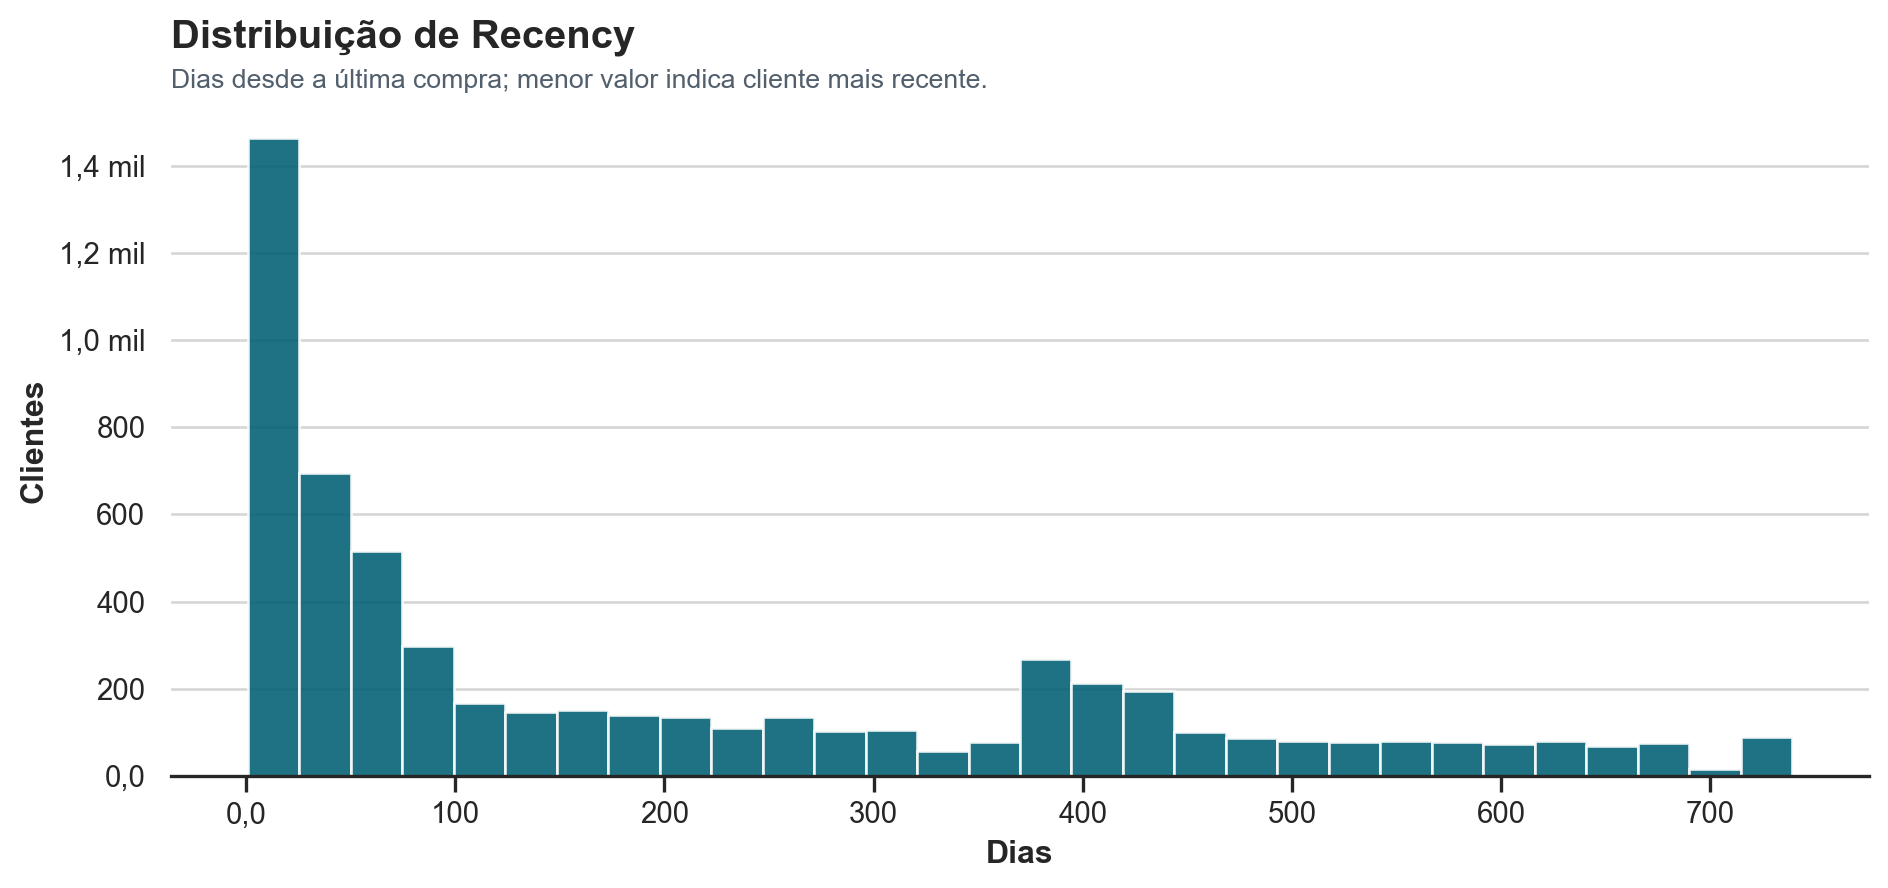

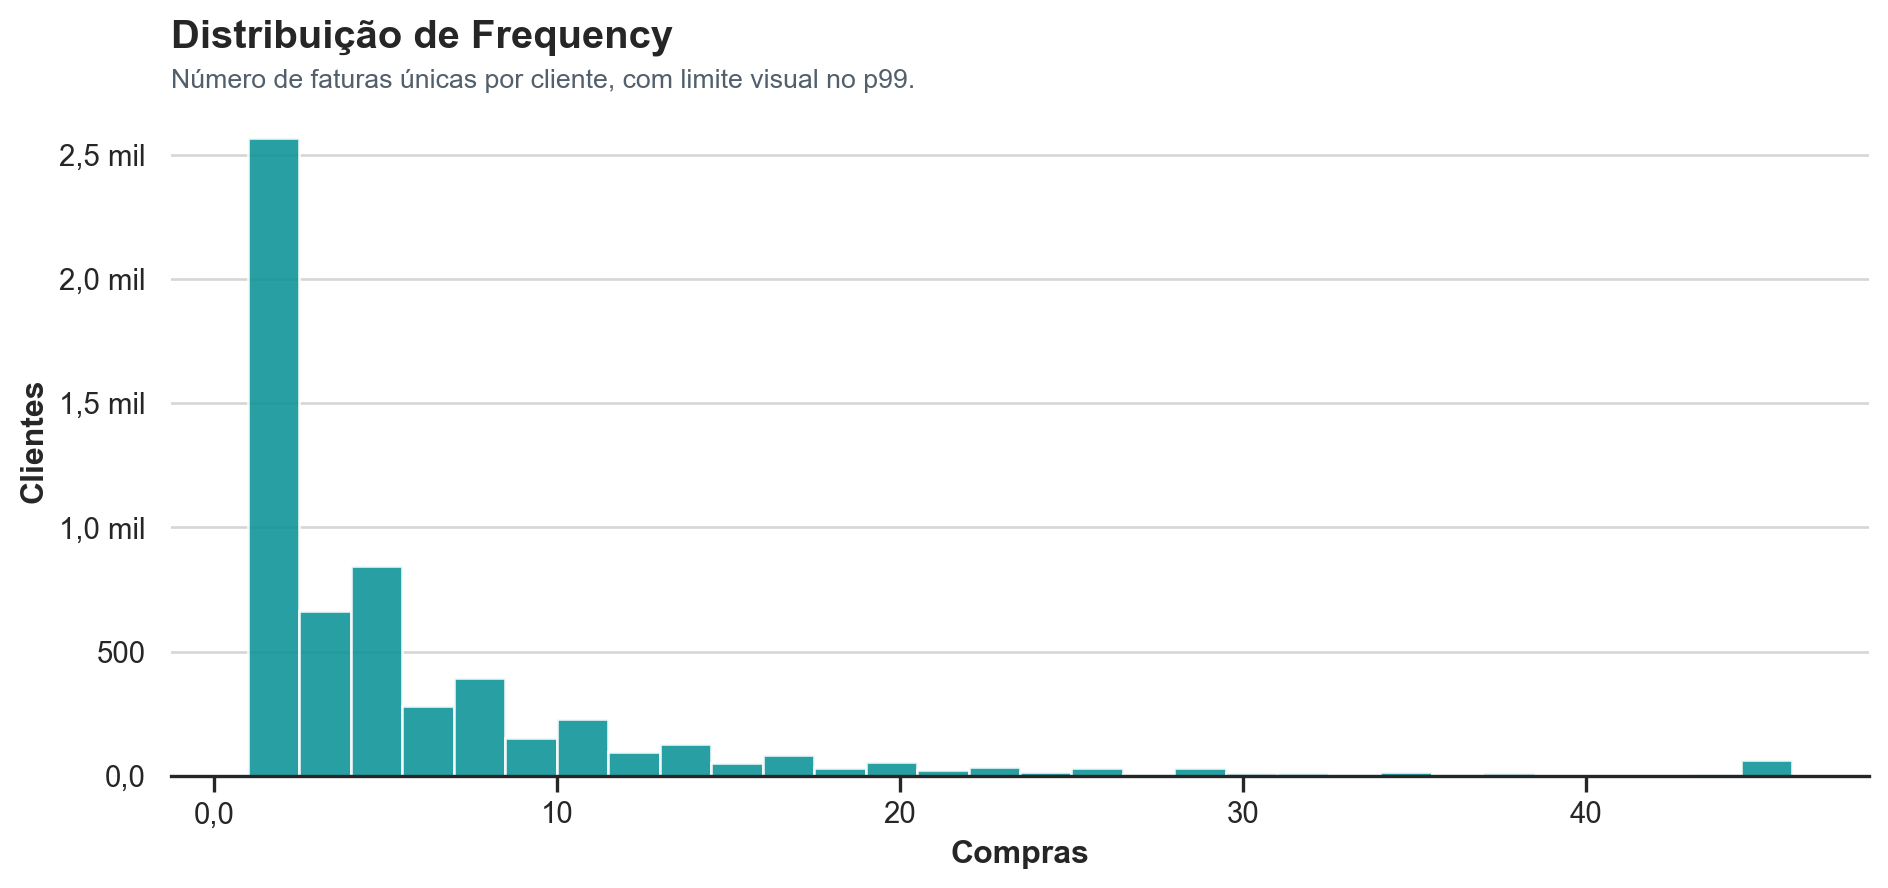

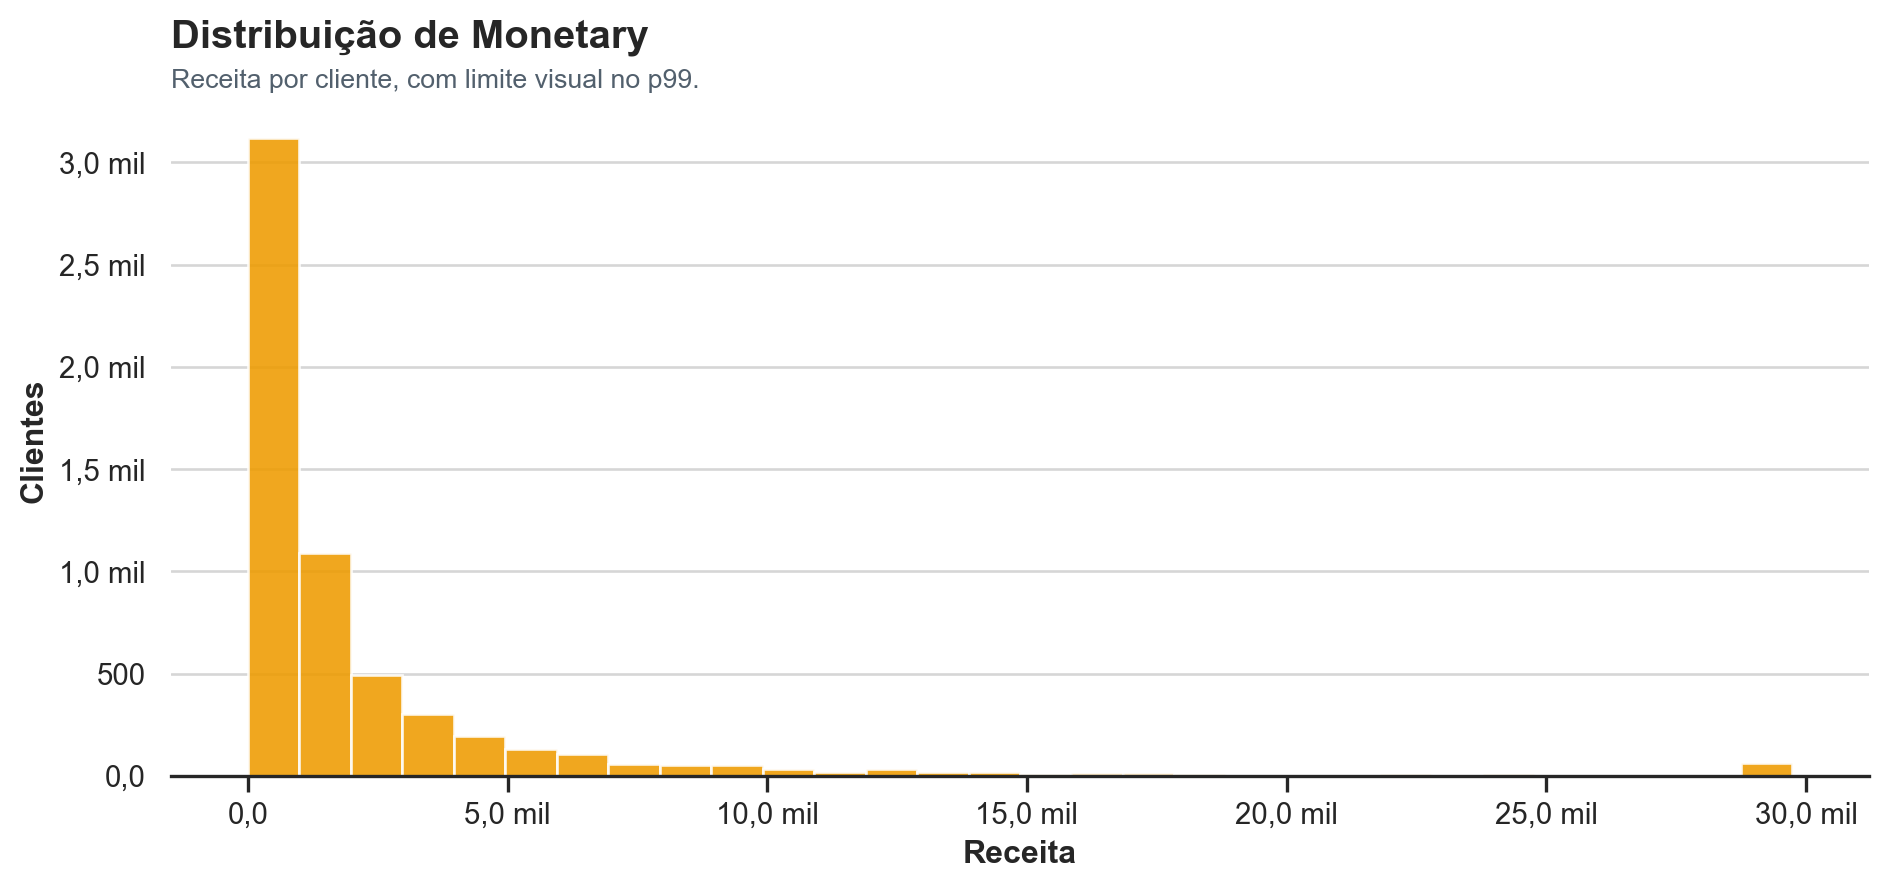

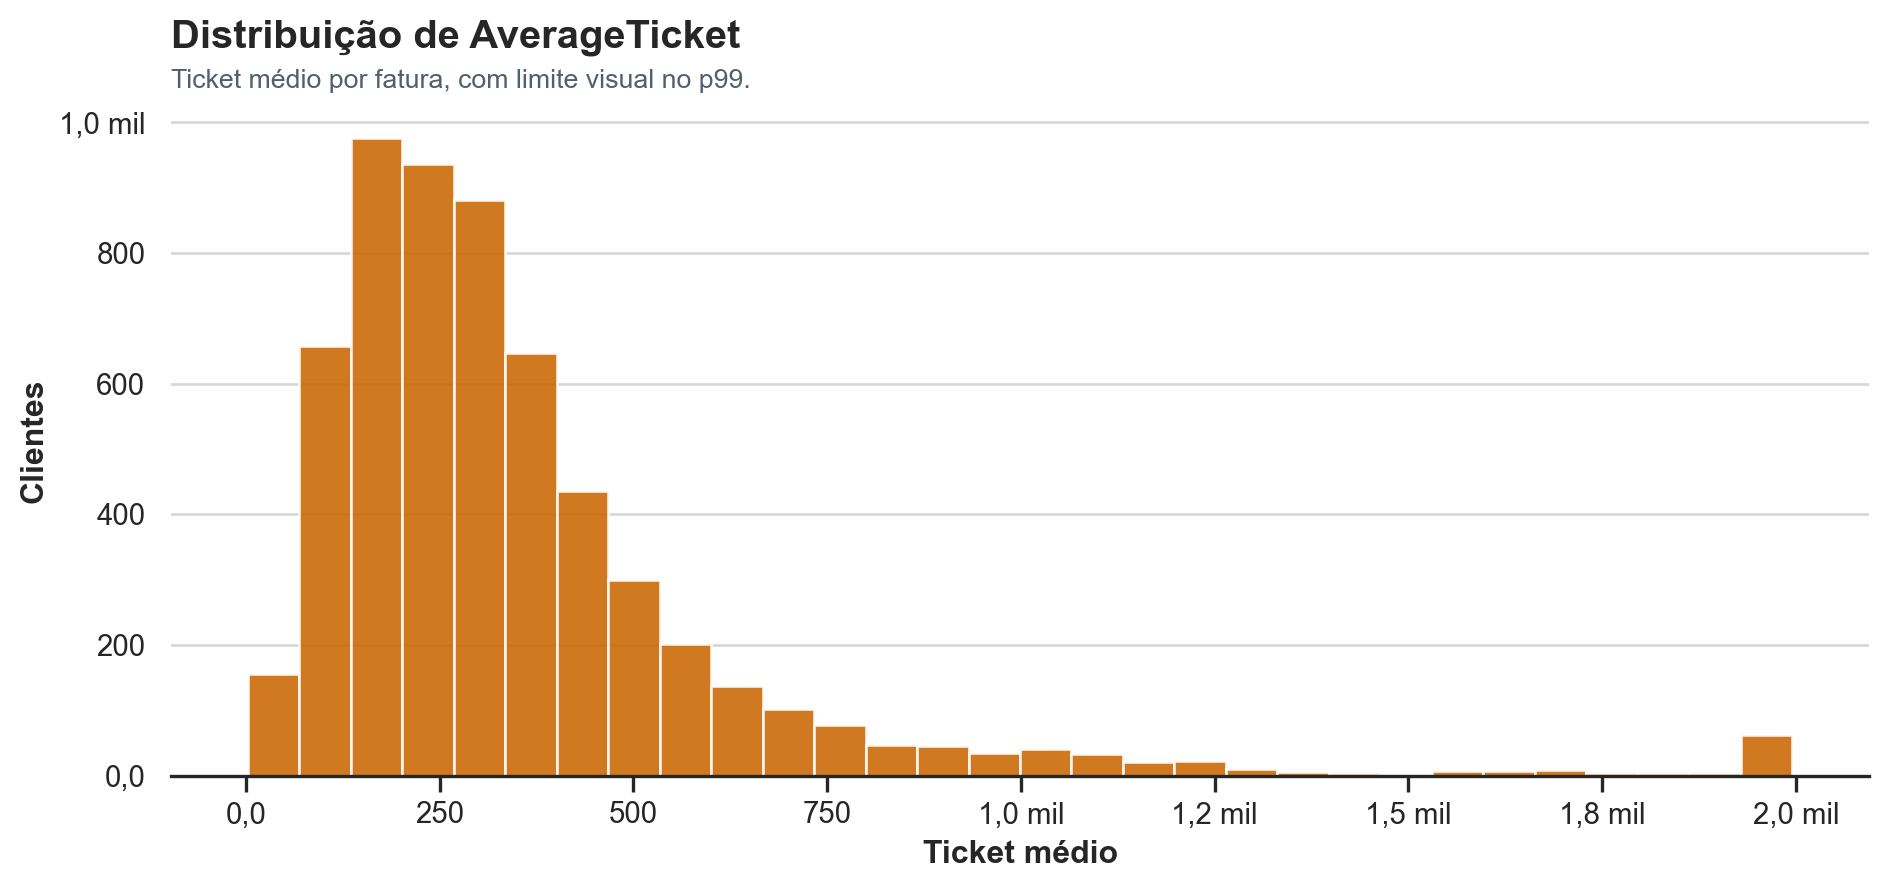

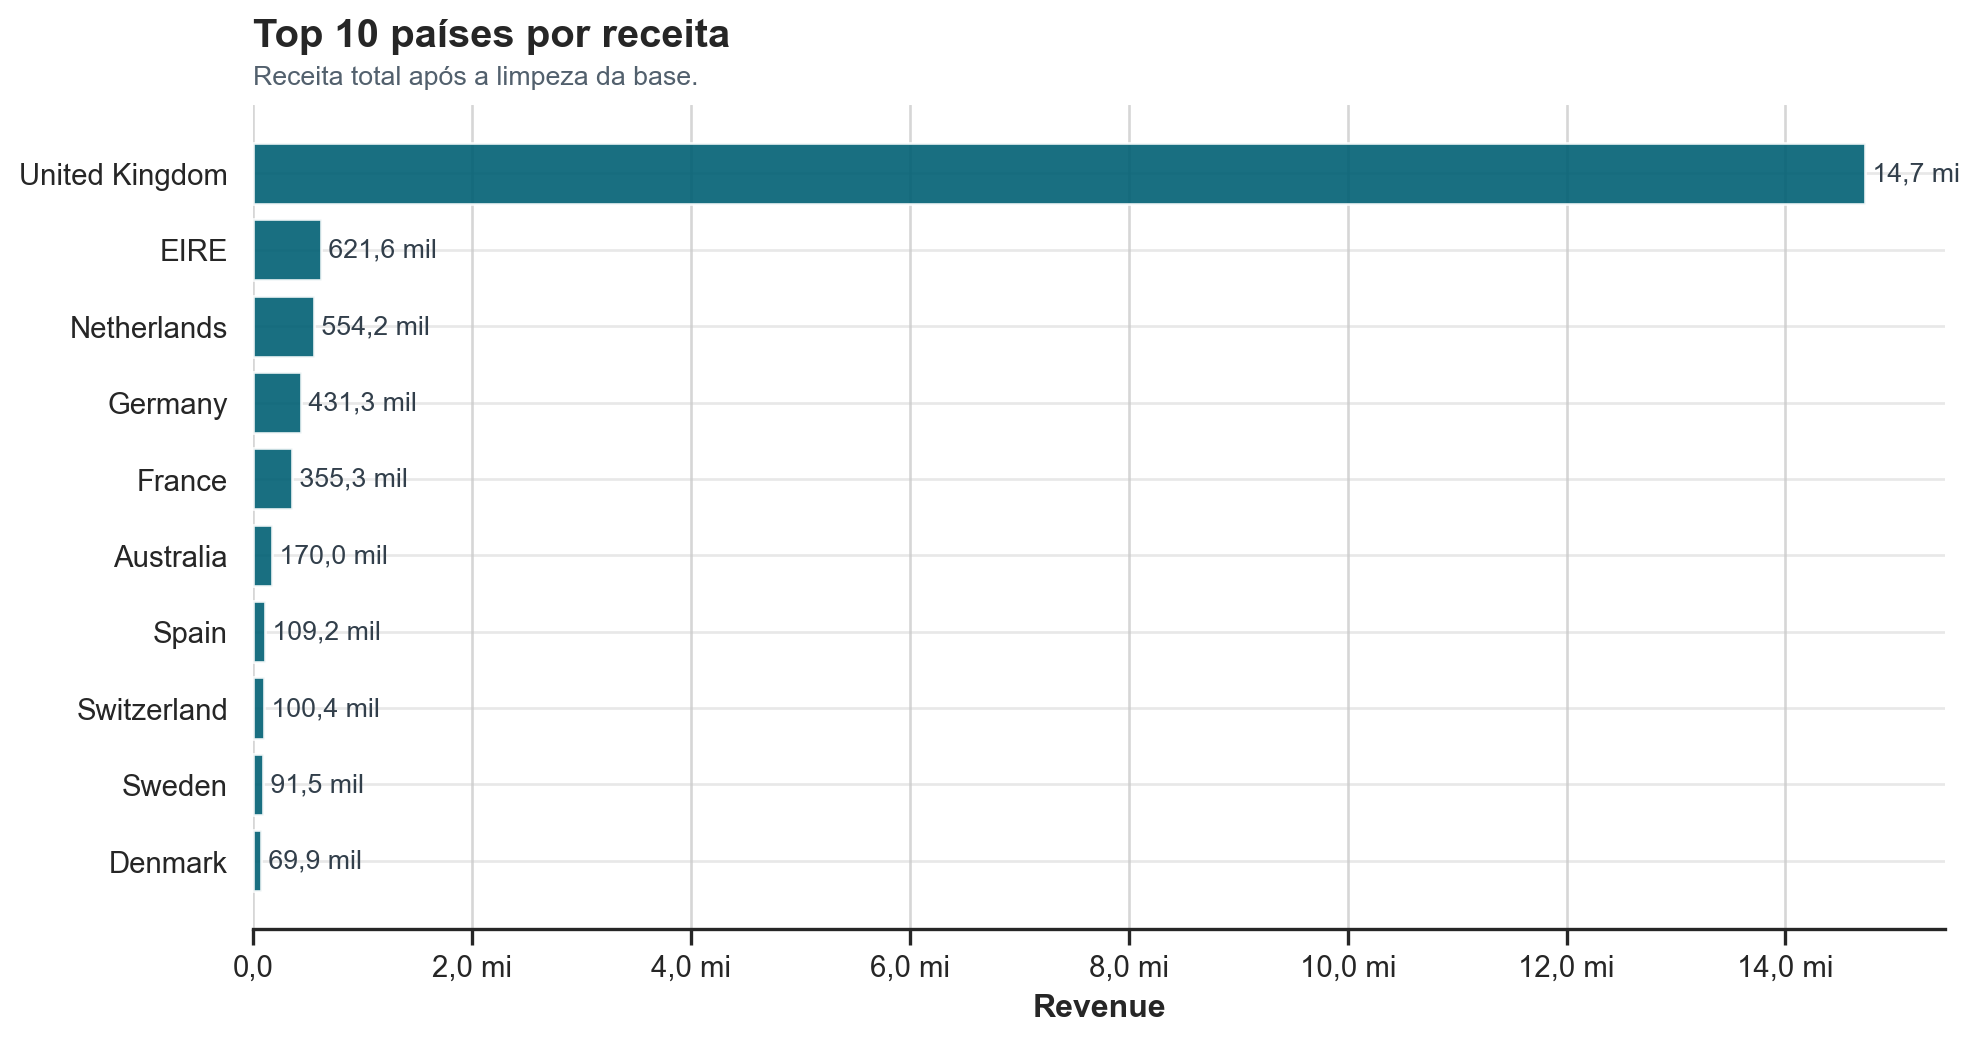

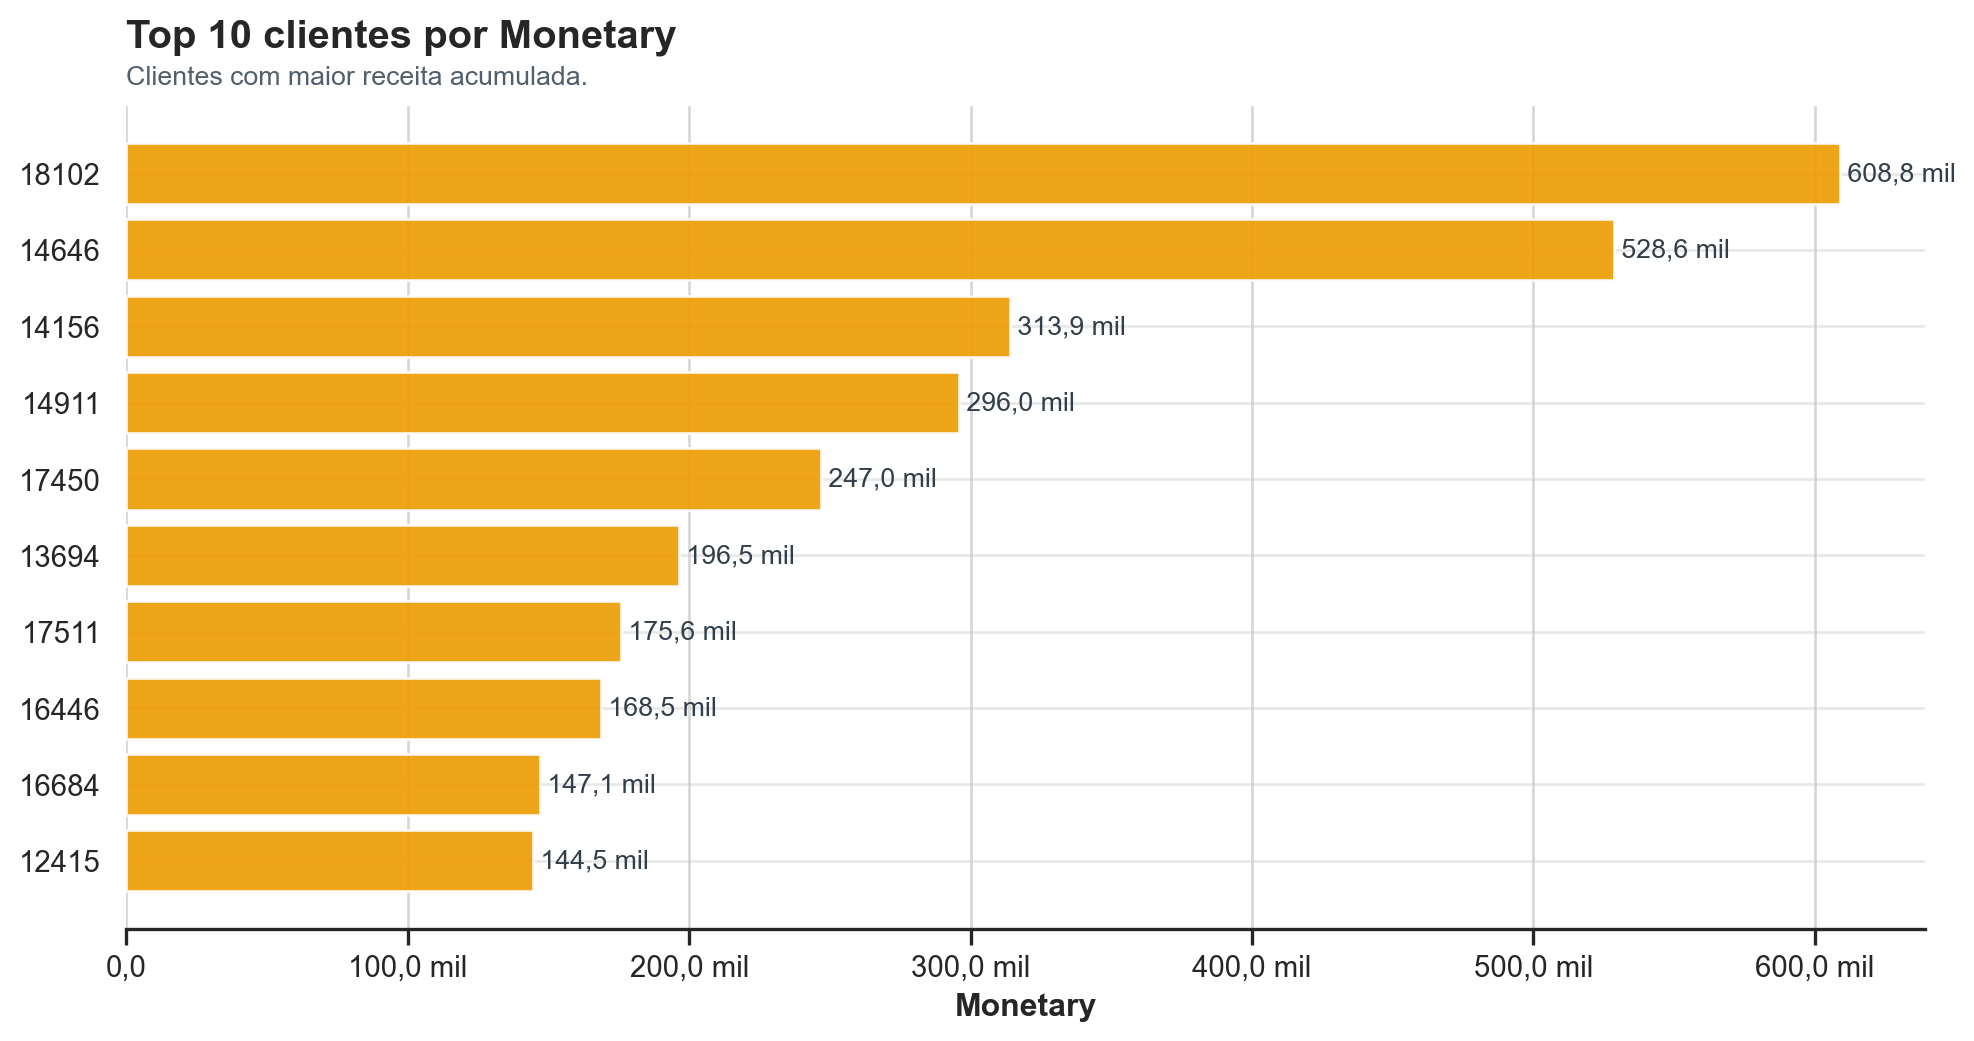

,Country,Revenue
38,United Kingdom,14723147.52
10,EIRE,621631.11
24,Netherlands,554232.34
14,Germany,431262.46
13,France,355257.47
0,Australia,169968.11
32,Spain,109178.53
34,Switzerland,100365.34
33,Sweden,91549.72
9,Denmark,69862.19


,Customer ID,Monetary
5692,18102,608821.65
2277,14646,528602.52
1789,14156,313946.37
2538,14911,295972.63
5050,17450,246973.09
1331,13694,196482.81
5109,17511,175603.55
4061,16446,168472.50
4295,16684,147142.77
68,12415,144458.37


In [18]:
hist(rfm["Recency"], "Distribuição de Recency", "Dias desde a última compra; menor valor indica cliente mais recente.", "Dias", PALETTE[0])
hist(rfm["Frequency"], "Distribuição de Frequency", "Número de faturas únicas por cliente, com limite visual no p99.", "Compras", PALETTE[1], q=.99)
hist(rfm["Monetary"], "Distribuição de Monetary", "Receita por cliente, com limite visual no p99.", "Receita", PALETTE[3], q=.99)
hist(rfm["AverageTicket"], "Distribuição de AverageTicket", "Ticket médio por fatura, com limite visual no p99.", "Ticket médio", PALETTE[4], q=.99)

country_revenue = clean_df.groupby("Country", as_index=False)["Revenue"].sum().sort_values("Revenue", ascending=False).head(10)
top_customers = rfm.nlargest(10, "Monetary")[["Customer ID", "Monetary"]]
barh(country_revenue.sort_values("Revenue"), "Country", "Revenue", "Top 10 países por receita", "Receita total após a limpeza da base.", PALETTE[0])
barh(top_customers.sort_values("Monetary"), "Customer ID", "Monetary", "Top 10 clientes por Monetary", "Clientes com maior receita acumulada.", PALETTE[3])
display(country_revenue)
display(top_customers)


<span style="color:steelblue; text-align: left">

## Preparação dos dados para clustering
</span>

As variáveis principais são `Recency`, `Frequency`, `Monetary`, `AverageTicket` e `UniqueProducts`. A transformação `log1p` é aplicada nas variáveis assimétricas (`Frequency`, `Monetary`, `AverageTicket` e `UniqueProducts`) para reduzir o peso de outliers, uma prática comum em pré-processamento quando distribuições são concentradas e de cauda longa [Kuhn e Johnson, 2013; Hastie, Tibshirani e Friedman, 2009]. Em seguida, os atributos são padronizados porque o K-Means usa distância euclidiana e é sensível à escala [MacQueen, 1967; Jain, 2010]. `Recency` deve ser lido de forma inversa: menor recência significa cliente mais recente ou ativo.


In [19]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageTicket",
    "UniqueProducts",
]
log_features = [
    "Frequency",
    "Monetary",
    "AverageTicket",
    "UniqueProducts",
]

cluster_df = rfm[features].copy()
for col in log_features:
    cluster_df[col] = np.log1p(cluster_df[col])

scaler = StandardScaler()
x_scaled = scaler.fit_transform(cluster_df)

print("Padronização utilizada: StandardScaler")
display(cluster_df.head())


Padronização utilizada: StandardScaler


,Recency,Frequency,Monetary,AverageTicket,UniqueProducts
0,326,2.56,11.26,8.77,3.33
1,2,2.20,8.64,6.56,4.84
2,75,1.79,7.61,6.00,3.26
3,19,1.61,8.40,7.01,4.93
4,310,0.69,5.82,5.82,2.89


<span style="color:steelblue; text-align: left">

## Escolha do número de clusters
</span>

São testados valores de `k` entre 2 e 10. A análise usa `inertia`, relacionada à compactação interna típica do objetivo de mínimos quadrados do K-Means [Lloyd, 1982; Jain, 2010], e `silhouette_score`, para avaliar coesão e separação entre clusters [Rousseeuw, 1987]. A escolha final combina métrica e utilidade de negócio, já que um número matematicamente bom pode ser amplo demais para orientar ações [Wedel e Kamakura, 2000].


,k,inertia,silhouette_score
0,2,17255.96,0.35
1,3,13659.28,0.28
2,4,11603.71,0.27
3,5,10286.31,0.25
4,6,9217.00,0.25
5,7,8533.81,0.23
6,8,7935.78,0.23
7,9,7438.42,0.23
8,10,6993.62,0.23


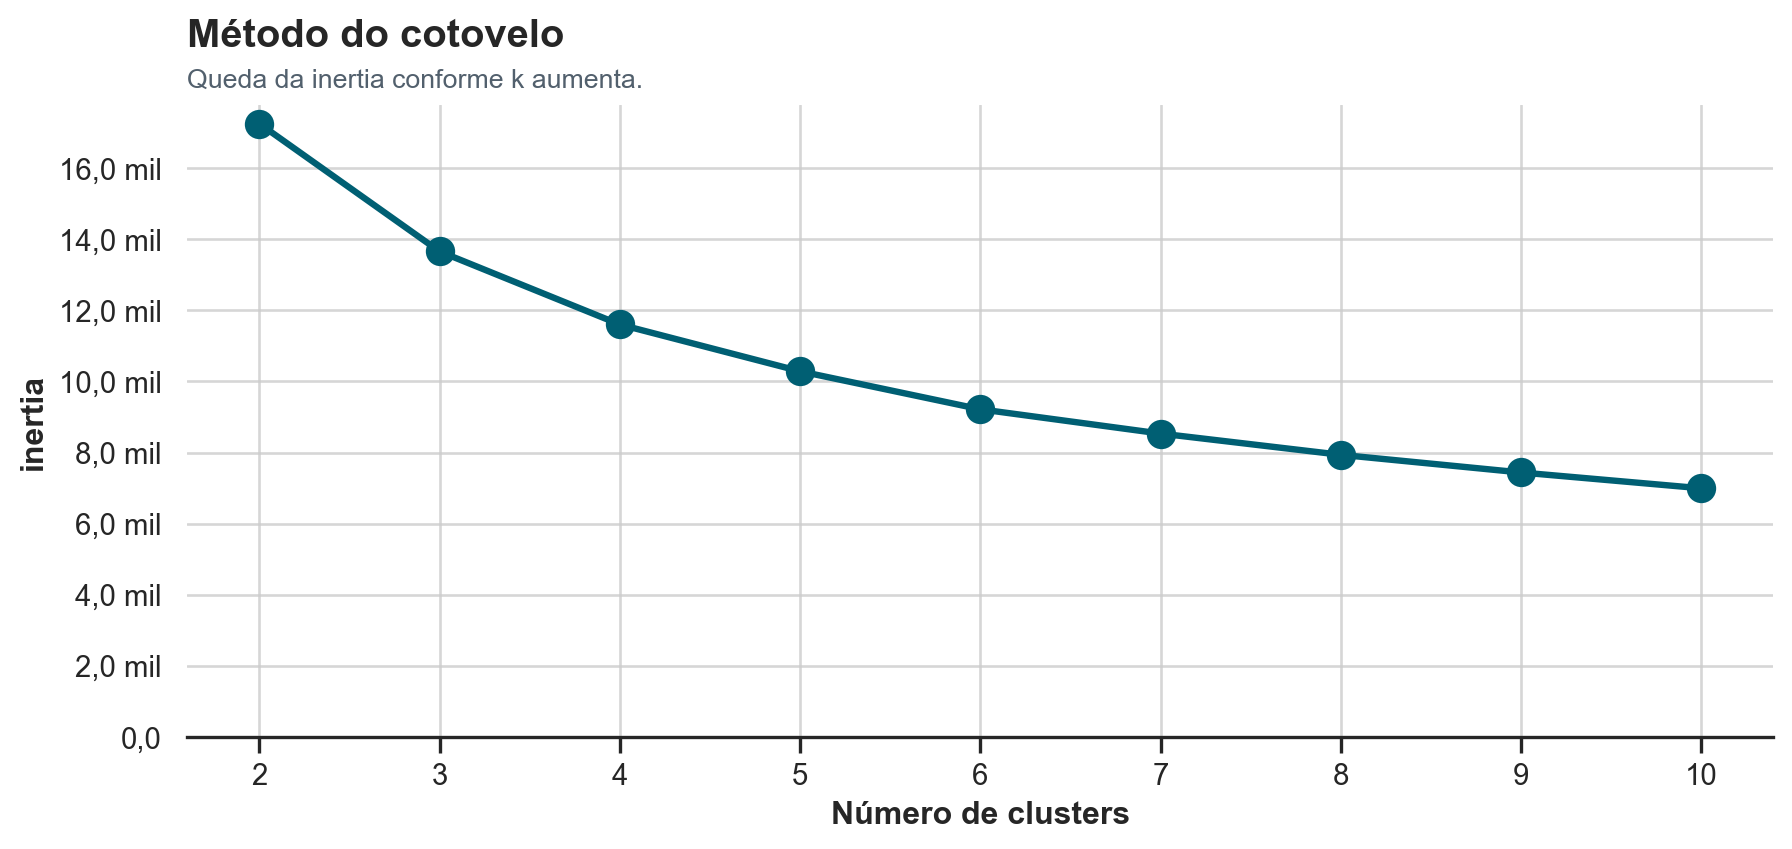

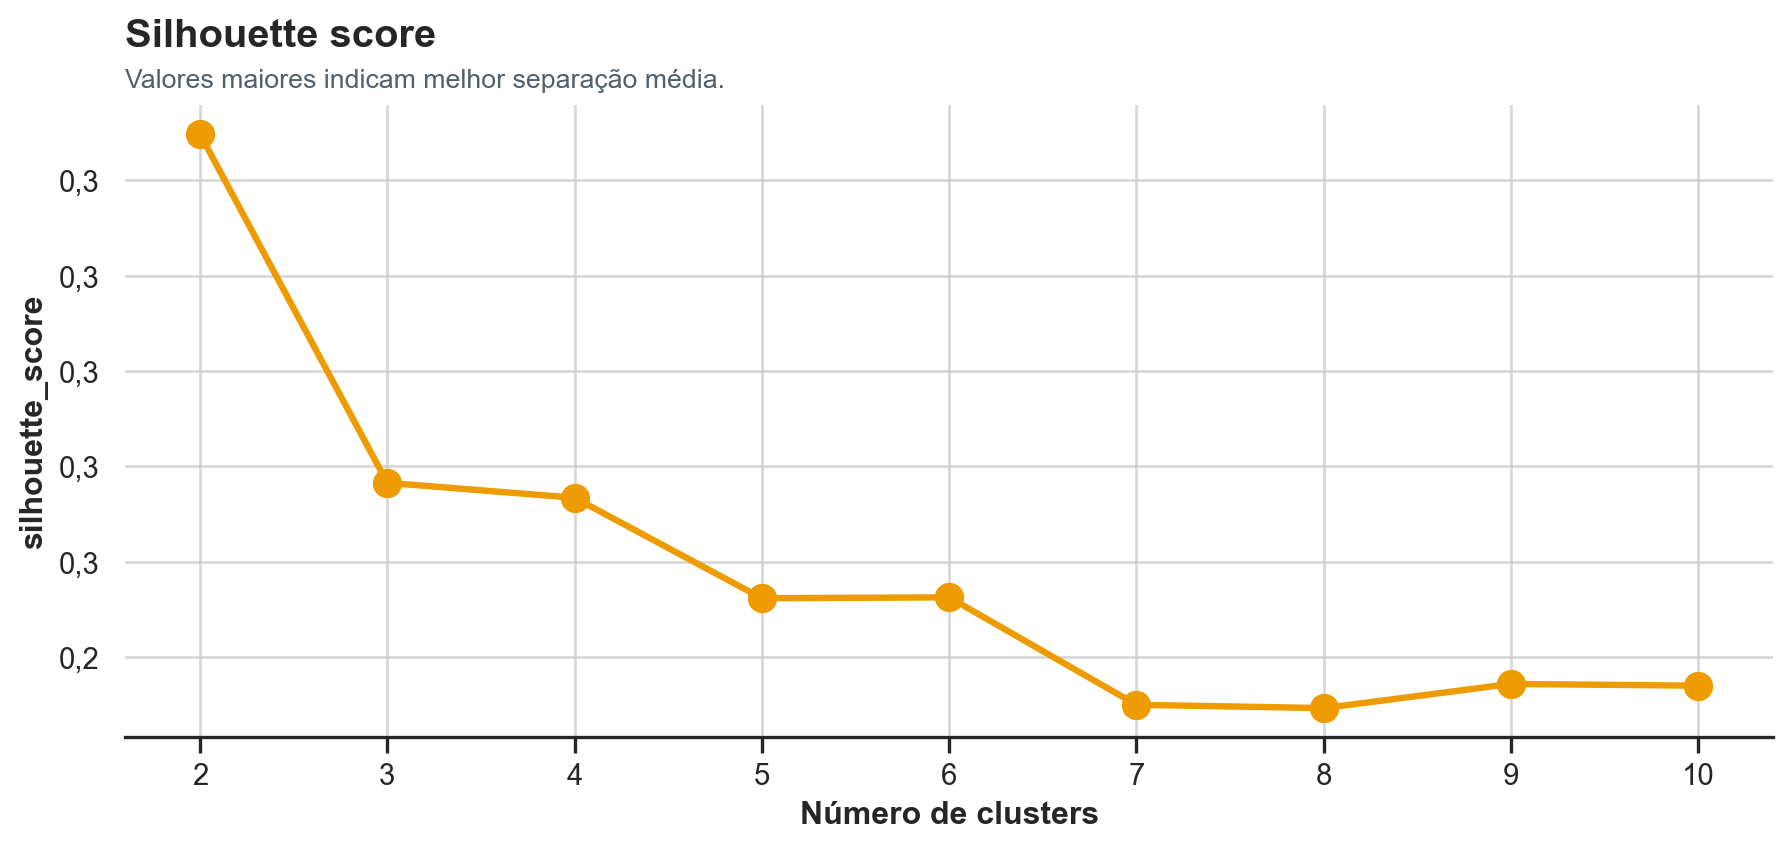


**Número de clusters escolhido: 6.**

O maior silhouette foi observado em `k=2`. Ainda assim, `k=6` foi escolhido por oferecer segmentos mais acionáveis para Next Best Action, separando clientes de alto valor, fiéis, ocasionais, de baixo valor, inativos e clientes de valor em risco. A decisão prioriza equilíbrio entre qualidade estatística, interpretabilidade e utilidade comercial.


In [20]:
def fit_kmeans(x: np.ndarray, k: int, n_init: int = 10) -> tuple[np.ndarray, float]:
    """Treina K-Means e retorna rótulos e inertia para um k candidato."""
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=n_init,
    )
    labels = model.fit_predict(x)
    return labels, float(model.inertia_)


def silhouette(x: np.ndarray, labels: np.ndarray, sample: int = 2500) -> float:
    """Calcula silhouette score com amostragem limitada para manter execução rápida."""
    return float(
        silhouette_score(
            x,
            labels,
            sample_size=min(sample, len(x)),
            random_state=RANDOM_STATE,
        )
    )


rows = []
for k in range(2, 11):
    labels, inertia = fit_kmeans(x_scaled, k, n_init=10)
    rows.append({
        "k": k,
        "inertia": inertia,
        "silhouette_score": silhouette(x_scaled, labels),
    })

k_metrics = pd.DataFrame(rows)
display(k_metrics.round(4))
lineplot(
    k_metrics,
    "k",
    "inertia",
    "Método do cotovelo",
    "Queda da inertia conforme k aumenta.",
    PALETTE[0],
    zero=True,
)
lineplot(
    k_metrics,
    "k",
    "silhouette_score",
    "Silhouette score",
    "Valores maiores indicam melhor separação média.",
    PALETTE[3],
)

# CORREÇÃO: best_k é usado explicitamente na justificativa exibida no notebook.
best_k = int(k_metrics.loc[k_metrics["silhouette_score"].idxmax(), "k"])
# CORREÇÃO P4: número de clusters parametrizado na célula de configuração.
selected_k = N_CLUSTERS
text = f"""
**Número de clusters escolhido: {selected_k}.**

O maior silhouette foi observado em `k={best_k}`. Ainda assim, `k={selected_k}` foi escolhido por oferecer segmentos mais acionáveis para Next Best Action, separando clientes de alto valor, fiéis, ocasionais, de baixo valor, inativos e clientes de valor em risco. A decisão prioriza equilíbrio entre qualidade estatística, interpretabilidade e utilidade comercial.
"""
display(Markdown(text))


<span style="color:steelblue; text-align: left">

## Segmentação com K-Means

</span>

O modelo final é treinado com o número de clusters escolhido. O K-Means busca particionar observações em grupos próximos a centroides, minimizando distâncias internas, ideia formalizada em trabalhos clássicos de MacQueen e Lloyd [MacQueen, 1967; Lloyd, 1982]. O rótulo técnico `Cluster` é adicionado à tabela RFM para análise de tamanho, médias, medianas, receita total e percentual de receita.


In [21]:
labels, final_inertia = fit_kmeans(x_scaled, selected_k, n_init=20)
rfm["Cluster"] = labels.astype(int)

cluster_vars = ["Recency", "Frequency", "Monetary", "AverageTicket", "QuantityTotal", "UniqueProducts"]
cluster_size = rfm["Cluster"].value_counts().sort_index().rename_axis("Cluster").reset_index(name="Clientes")
cluster_mean = rfm.groupby("Cluster")[cluster_vars].mean().round(2)
cluster_median = rfm.groupby("Cluster")[cluster_vars].median().round(2)
cluster_revenue = rfm.groupby("Cluster", as_index=False).agg(ReceitaTotal=("Monetary", "sum"))
cluster_revenue["PercentualReceita"] = (cluster_revenue["ReceitaTotal"] / cluster_revenue["ReceitaTotal"].sum() * 100).round(2)

display(cluster_size)
display(cluster_mean)
display(cluster_median)
display(cluster_revenue)


,Cluster,Clientes
0,0,674
1,1,1158
2,2,1095
3,3,1510
4,4,577
5,5,864


,Recency,Frequency,Monetary,AverageTicket,QuantityTotal,UniqueProducts
Cluster,,,,,,
0,198.63,2.88,2931.68,1098.75,2046.04,70.58
1,95.69,2.17,443.49,227.96,299.01,25.14
2,488.79,1.83,517.80,303.95,305.30,32.18
3,84.15,6.51,1760.76,283.66,1053.46,99.74
4,421.09,1.39,129.98,100.71,77.98,7.58
5,38.76,23.02,13834.69,554.13,8114.42,248.89


,Recency,Frequency,Monetary,AverageTicket,QuantityTotal,UniqueProducts
Cluster,,,,,,
0,149.50,3.00,1635.15,672.61,926.00,57.50
1,65.00,2.00,389.32,205.65,221.50,22.00
2,456.00,1.00,406.30,282.30,225.00,26.00
3,41.00,6.00,1590.66,272.96,881.00,83.00
4,430.00,1.00,118.86,101.36,59.00,6.00
5,17.00,16.00,6698.07,431.78,3716.00,199.00


,Cluster,ReceitaTotal,PercentualReceita
0,0,1975951.49,11.14
1,1,513556.93,2.89
2,2,566995.71,3.20
3,3,2658749.94,14.98
4,4,75000.23,0.42
5,5,11953174.87,67.37


<span style="color:steelblue; text-align: left">

## Interpretação dos clusters
</span>

O número do cluster não tem significado de negócio. A interpretação abaixo transforma cada grupo em um segmento usando recência, frequência, receita, ticket médio e variedade de produtos. Essa tradução de agrupamentos estatísticos para segmentos gerenciais é central em segmentação de mercado aplicada [Wedel e Kamakura, 2000; Chen, Sain e Guo, 2012].


In [22]:
ACTIONS = {
    "Campeões": "Oferecer programa VIP, acesso antecipado e benefícios exclusivos.",
    "Alto Valor em Risco": "Priorizar campanhas de reativação e ofertas personalizadas.",
    "Clientes Fiéis": "Estimular cross-sell e bundles.",
    "Compradores Ocasionais": "Campanhas de segunda compra e cupons de baixo custo.",
    "Baixo Valor": "Automação de marketing de baixo custo.",
    "Clientes Inativos": "Reativação pontual ou baixa prioridade.",
}

profile = rfm.groupby("Cluster").agg(
    Clientes=("Customer ID", "count"),
    Recency_mean=("Recency", "mean"),
    Frequency_mean=("Frequency", "mean"),
    Monetary_mean=("Monetary", "mean"),
    AverageTicket_mean=("AverageTicket", "mean"),
    UniqueProducts_mean=("UniqueProducts", "mean"),
    ReceitaTotal=("Monetary", "sum"),
).reset_index()
profile["PercentualReceita"] = profile["ReceitaTotal"] / profile["ReceitaTotal"].sum() * 100


def rank01(s: pd.Series, high: bool = True) -> pd.Series:
    """Normaliza ranks entre 0 e 1; high=True favorece valores maiores."""
    r = s.rank(ascending=True)
    if r.max() == r.min():
        score = r * 0 + 1
    else:
        score = (r - r.min()) / (r.max() - r.min())
    return score if high else 1 - score


def segment_names(p: pd.DataFrame) -> dict[int, str]:
    """Nomeia clusters por rankings de recência, frequência, valor, ticket e variedade."""
    p = p.set_index("Cluster")
    rem: set[int] = set(p.index)
    names: dict[int, str] = {}
    recent = rank01(p["Recency_mean"], high=False)
    old = rank01(p["Recency_mean"], high=True)
    freq = rank01(p["Frequency_mean"], high=True)
    mon = rank01(p["Monetary_mean"], high=True)
    ticket = rank01(p["AverageTicket_mean"], high=True)
    prod = rank01(p["UniqueProducts_mean"], high=True)

    champ = (recent * 0.25 + freq * 0.30 + mon * 0.30 + prod * 0.15).idxmax()
    names[int(champ)] = "Campeões"
    rem.discard(champ)

    if rem:
        risk = (
            mon.loc[list(rem)] * 0.45
            + ticket.loc[list(rem)] * 0.30
            + old.loc[list(rem)] * 0.25
        ).idxmax()
        names[int(risk)] = "Alto Valor em Risco"
        rem.discard(risk)
    if rem:
        loyal = freq.loc[list(rem)].idxmax()
        names[int(loyal)] = "Clientes Fiéis"
        rem.discard(loyal)
    if rem:
        inactive = old.loc[list(rem)].idxmax()
        names[int(inactive)] = "Clientes Inativos"
        rem.discard(inactive)
    if rem:
        low = (
            mon.loc[list(rem)] * 0.45
            + freq.loc[list(rem)] * 0.30
            + prod.loc[list(rem)] * 0.25
        ).idxmin()
        names[int(low)] = "Baixo Valor"
        rem.discard(low)
    for cl in rem:
        names[int(cl)] = "Compradores Ocasionais"
    return names


def validate_segment_names(p: pd.DataFrame, assigned_names: dict[int, str]) -> None:
    """Emite alerta quando nomes automáticos violam condições mínimas de negócio."""
    # CORREÇÃO: validação de sanidade para evitar nomeação frágil de segmentos.
    named = p.assign(NomeSegmento=p["Cluster"].map(assigned_names))
    recency_overall = named["Recency_mean"].mean()
    monetary_median = named["Monetary_mean"].median()

    try:
        champions_recency = named.loc[
            named["NomeSegmento"] == "Campeões",
            "Recency_mean",
        ].iloc[0]
        inactive_recency = named.loc[
            named["NomeSegmento"] == "Clientes Inativos",
            "Recency_mean",
        ].iloc[0]
        risk_monetary = named.loc[
            named["NomeSegmento"] == "Alto Valor em Risco",
            "Monetary_mean",
        ].iloc[0]

        assert champions_recency < recency_overall, "Campeões com recência acima da média."
        assert inactive_recency > recency_overall, "Clientes Inativos com recência abaixo da média."
        assert risk_monetary > monetary_median, "Alto Valor em Risco com monetary abaixo da mediana."
    except (AssertionError, IndexError) as exc:
        warnings.warn(
            "Verificar atribuição manual de segmentos — critérios automáticos "
            f"não foram satisfeitos. Detalhe: {exc}",
            stacklevel=2,
        )


names = segment_names(profile)
validate_segment_names(profile, names)
profile["NomeSegmento"] = profile["Cluster"].map(names)
profile["PerfilComportamental"] = profile.apply(
    lambda r: (
        f"Recency média de {fmt(r['Recency_mean'], 0)} dias, "
        f"frequência média de {fmt(r['Frequency_mean'], 1)} compras, "
        f"receita média de {fmt(r['Monetary_mean'], 2)}, "
        f"ticket médio de {fmt(r['AverageTicket_mean'], 2)} e "
        f"{fmt(r['UniqueProducts_mean'], 0)} produtos distintos."
    ),
    axis=1,
)
profile["AcaoRecomendada"] = profile["NomeSegmento"].map(ACTIONS)

rfm["SegmentName"] = rfm["Cluster"].map(names)
rfm["NextBestAction"] = rfm["SegmentName"].map(ACTIONS)

segment_table = profile[[
    "Cluster",
    "NomeSegmento",
    "PerfilComportamental",
    "ReceitaTotal",
    "PercentualReceita",
    "AcaoRecomendada",
]].sort_values("ReceitaTotal", ascending=False)
display(segment_table)


,Cluster,NomeSegmento,PerfilComportamental,ReceitaTotal,PercentualReceita,AcaoRecomendada
5,5,Campeões,"Recency média de 39 dias, frequência média de 23,0 compras, receita média de 13.834,69, ticket médio de 554,13 e 249 produtos distintos.",11953174.87,67.37,"Oferecer programa VIP, acesso antecipado e benefícios exclusivos."
3,3,Clientes Fiéis,"Recency média de 84 dias, frequência média de 6,5 compras, receita média de 1.760,76, ticket médio de 283,66 e 100 produtos distintos.",2658749.94,14.98,Estimular cross-sell e bundles.
0,0,Alto Valor em Risco,"Recency média de 199 dias, frequência média de 2,9 compras, receita média de 2.931,68, ticket médio de 1.098,75 e 71 produtos distintos.",1975951.49,11.14,Priorizar campanhas de reativação e ofertas personalizadas.
2,2,Clientes Inativos,"Recency média de 489 dias, frequência média de 1,8 compras, receita média de 517,80, ticket médio de 303,95 e 32 produtos distintos.",566995.71,3.20,Reativação pontual ou baixa prioridade.
1,1,Compradores Ocasionais,"Recency média de 96 dias, frequência média de 2,2 compras, receita média de 443,49, ticket médio de 227,96 e 25 produtos distintos.",513556.93,2.89,Campanhas de segunda compra e cupons de baixo custo.
4,4,Baixo Valor,"Recency média de 421 dias, frequência média de 1,4 compras, receita média de 129,98, ticket médio de 100,71 e 8 produtos distintos.",75000.23,0.42,Automação de marketing de baixo custo.


<span style="color:steelblue; text-align: left">

## Visualizações dos clusters
</span>

As visualizações conectam padrões de frequência, valor, recência, receita e tamanho dos segmentos. Gráficos exploratórios ajudam a validar se os grupos são interpretáveis e se a solução faz sentido além da métrica numérica [Tukey, 1977; Rousseeuw, 1987]. A leitura deve considerar que menor `Recency` representa compra mais recente.


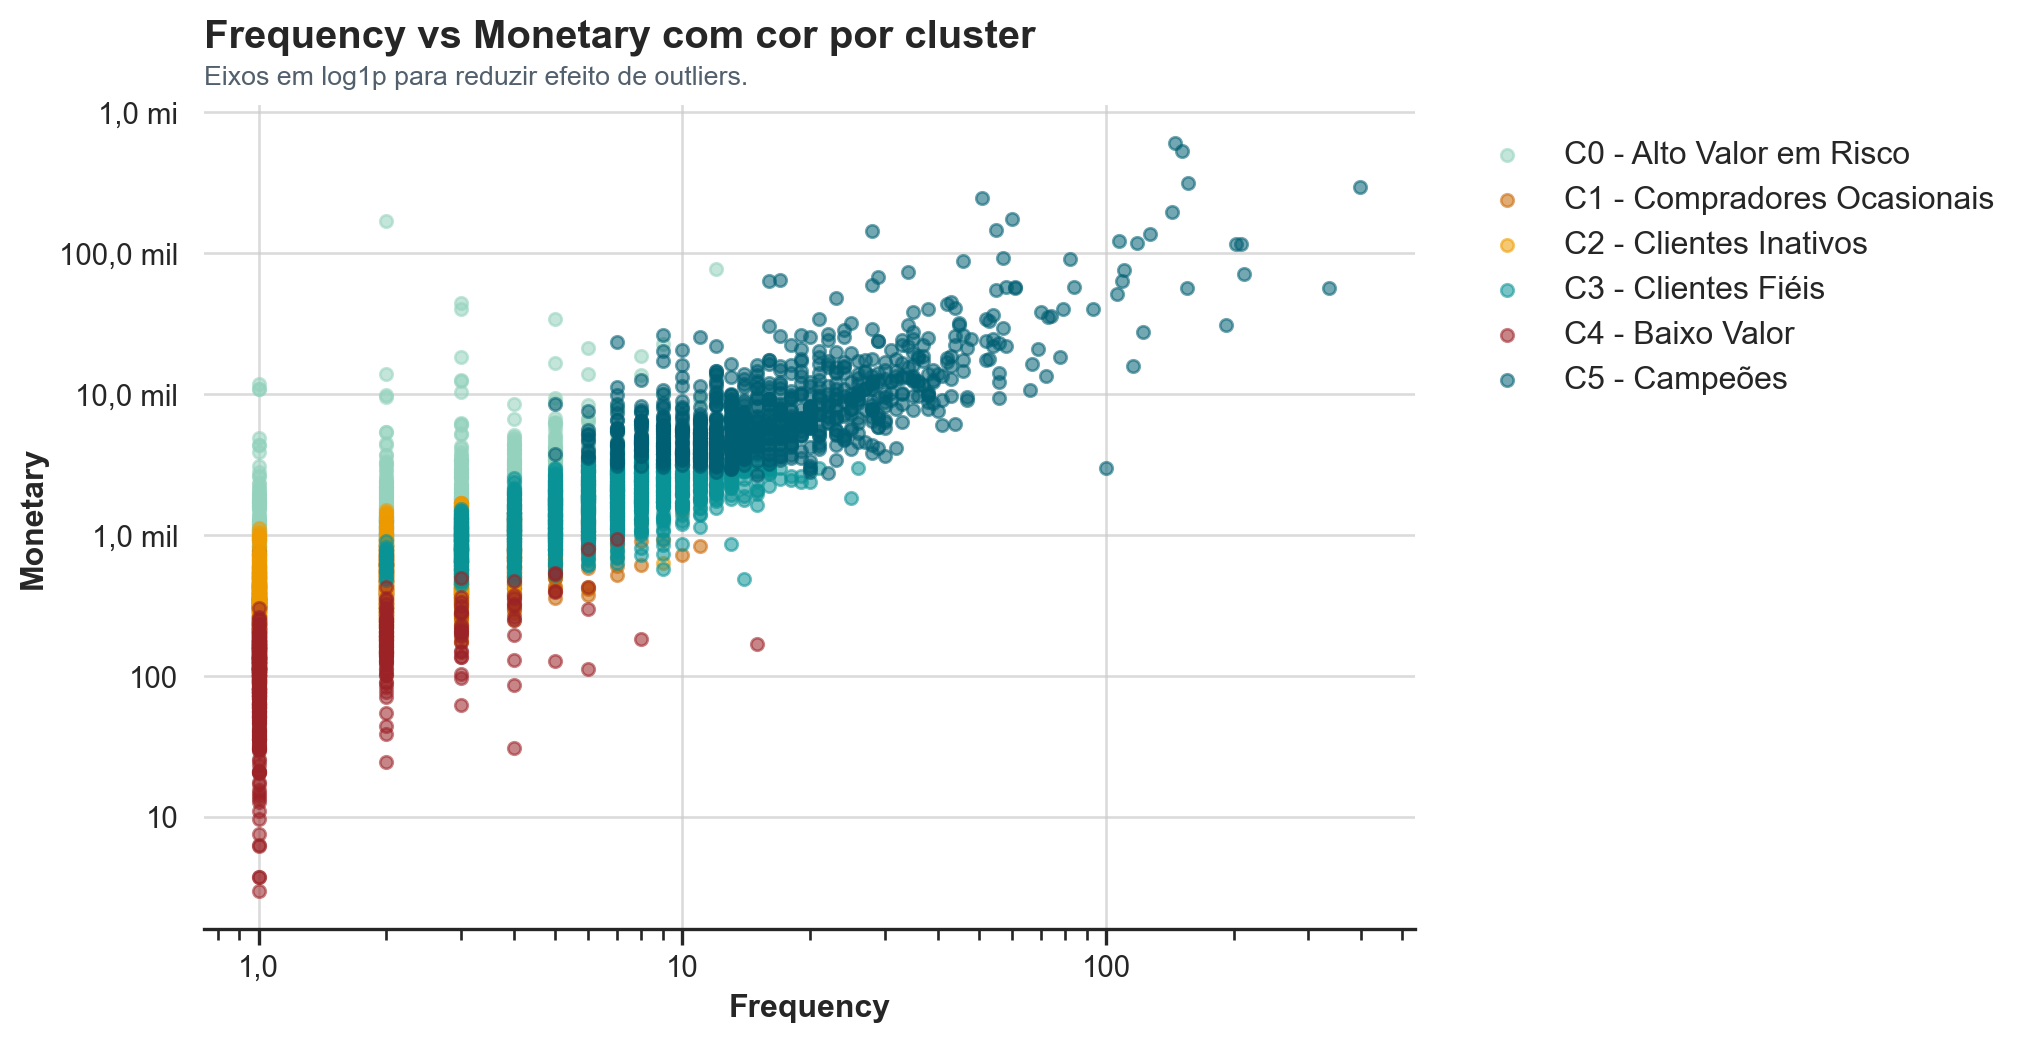

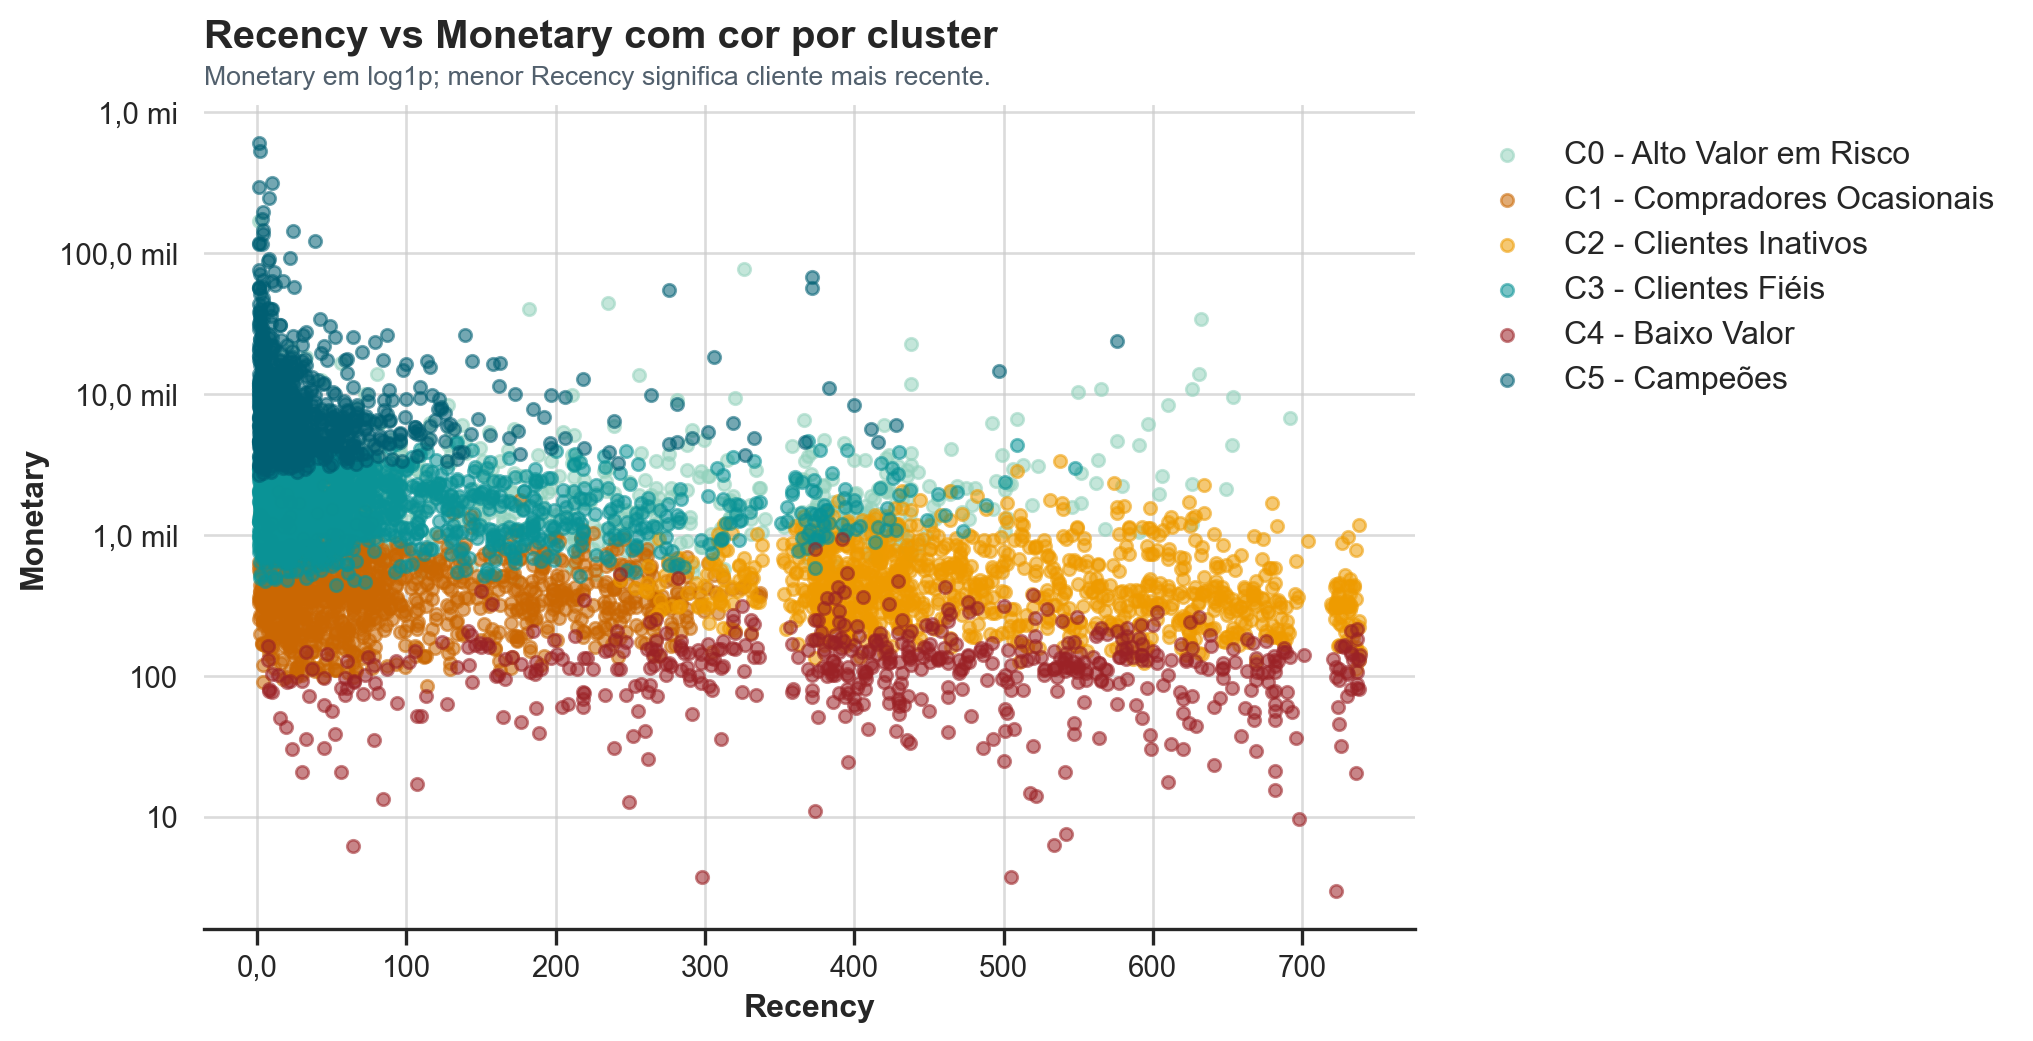

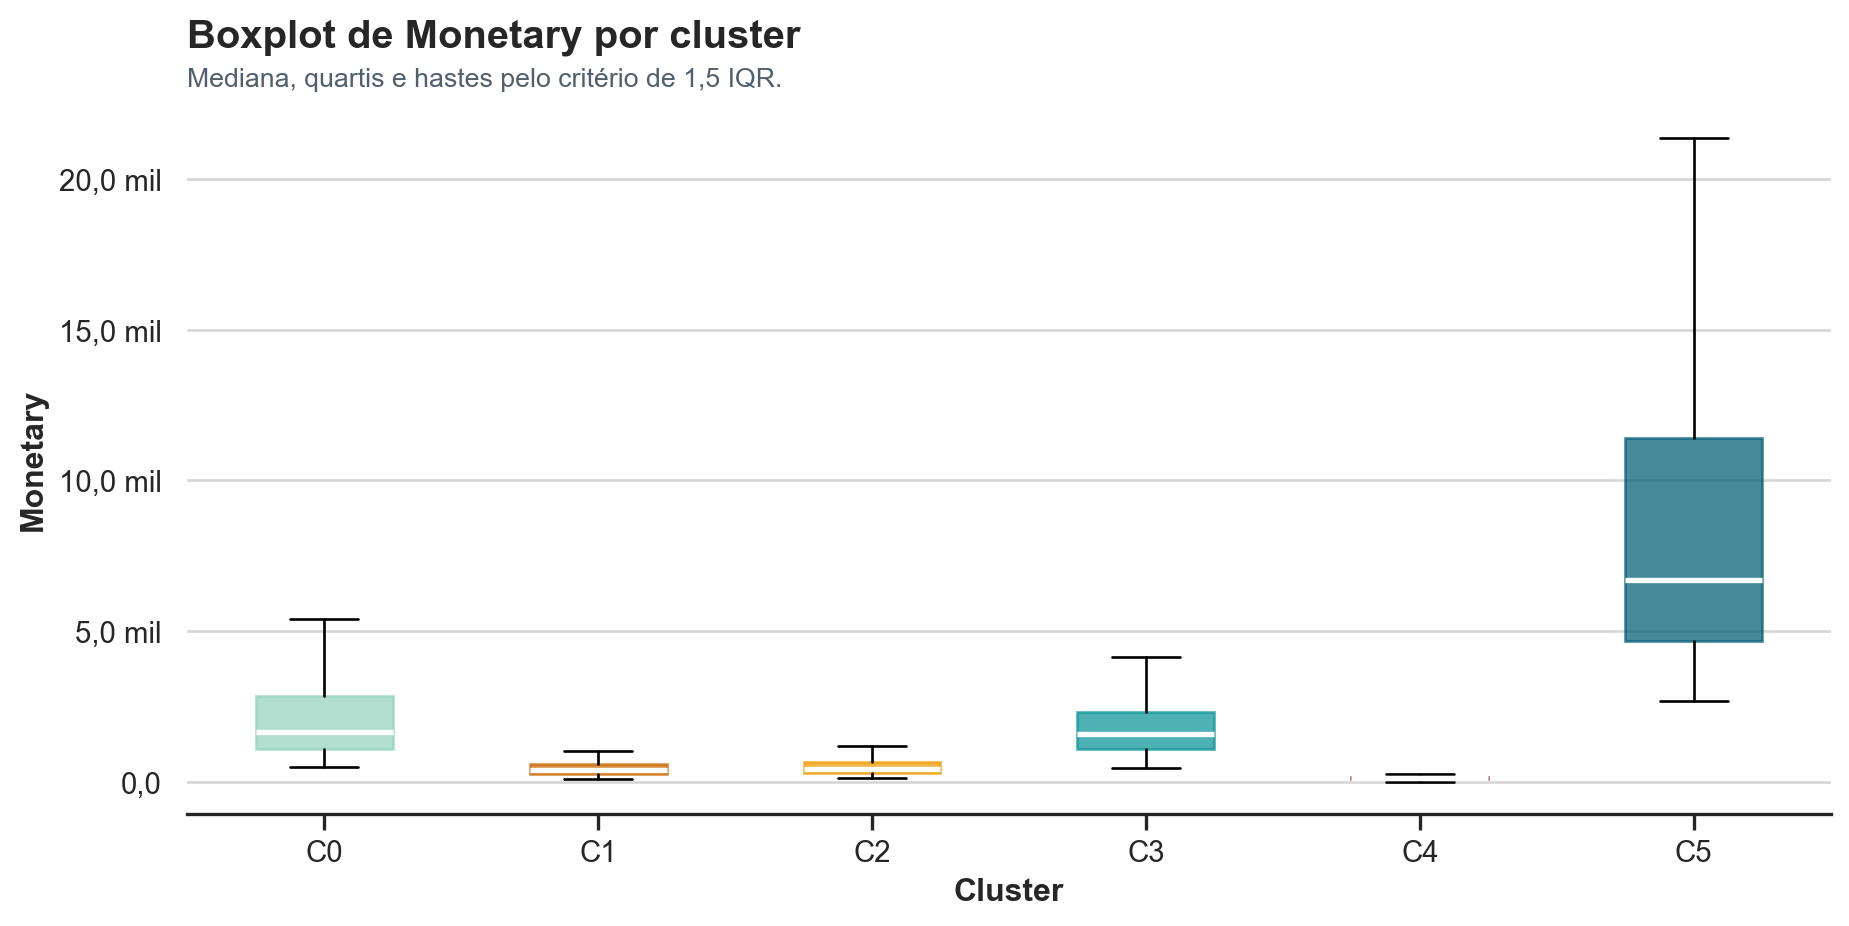

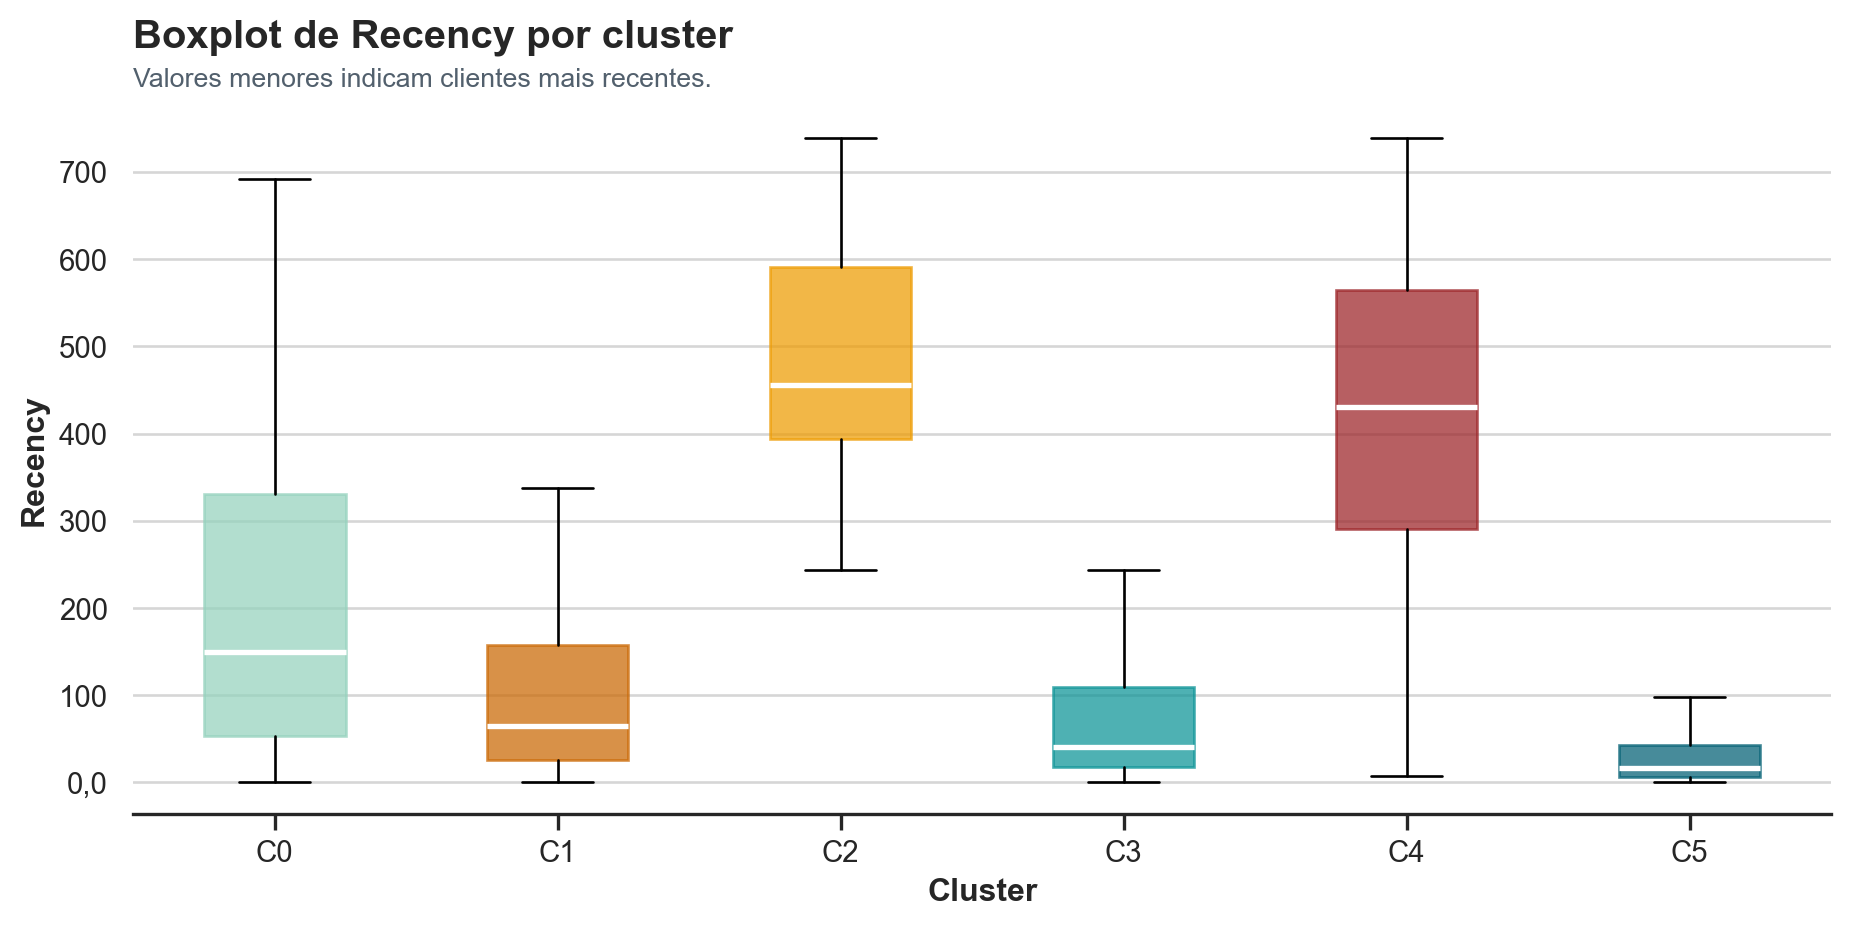

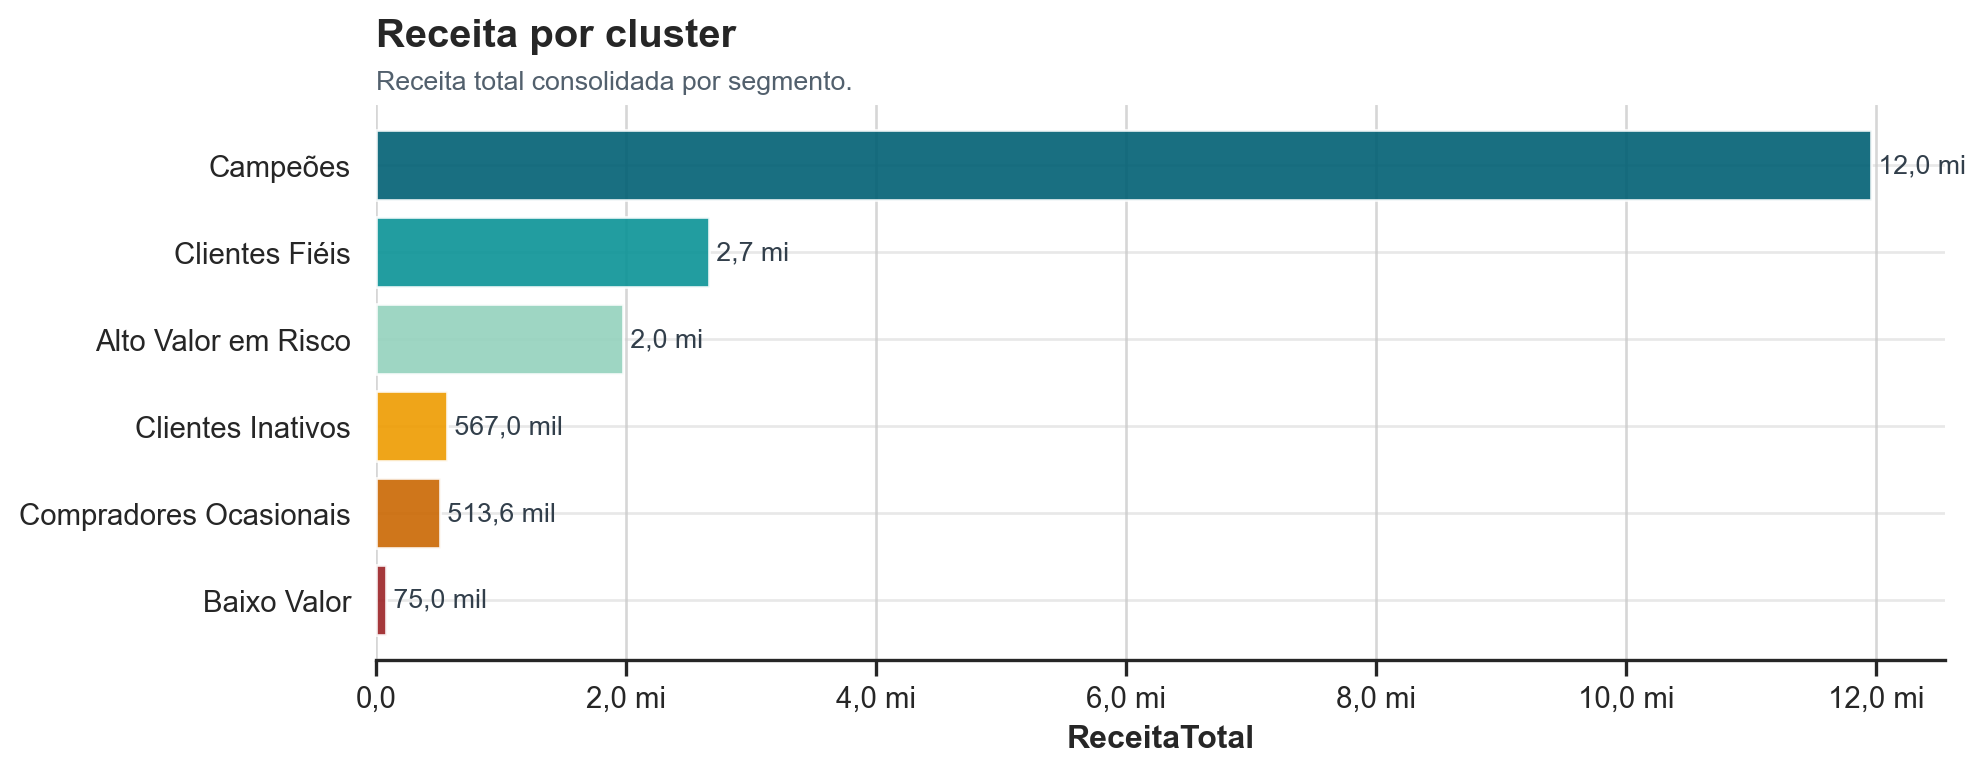

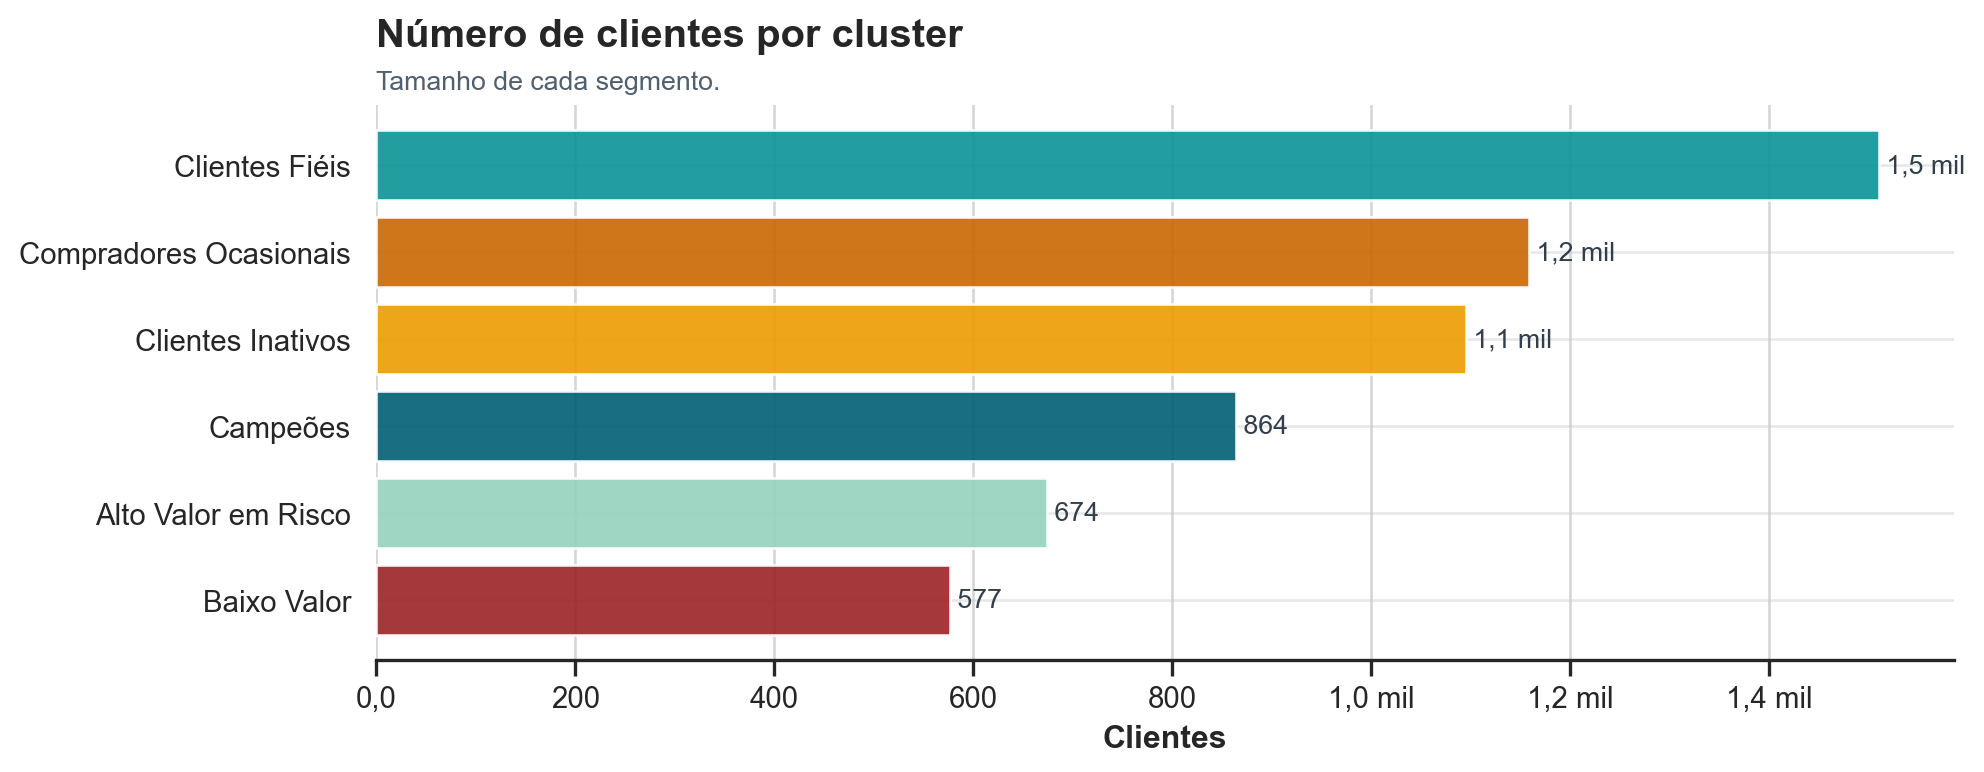

In [23]:
order = segment_table["Cluster"].tolist()
cluster_colors = {cl: PALETTE[i % len(PALETTE)] for i, cl in enumerate(order)}

scatter(rfm, "Frequency", "Monetary", "Frequency vs Monetary com cor por cluster", "Eixos em log1p para reduzir efeito de outliers.", cluster_colors, logx=True, logy=True)
scatter(rfm, "Recency", "Monetary", "Recency vs Monetary com cor por cluster", "Monetary em log1p; menor Recency significa cliente mais recente.", cluster_colors, logy=True)
boxplot(rfm, "Cluster", "Monetary", "Boxplot de Monetary por cluster", "Mediana, quartis e hastes pelo critério de 1,5 IQR.", cluster_colors)
boxplot(rfm, "Cluster", "Recency", "Boxplot de Recency por cluster", "Valores menores indicam clientes mais recentes.", cluster_colors)
barh(profile.sort_values("ReceitaTotal"), "NomeSegmento", "ReceitaTotal", "Receita por cluster", "Receita total consolidada por segmento.", color_col="Cluster", cmap=cluster_colors)
barh(profile.sort_values("Clientes"), "NomeSegmento", "Clientes", "Número de clientes por cluster", "Tamanho de cada segmento.", color_col="Cluster", cmap=cluster_colors)


<span style="color:steelblue; text-align: left">

## Next Best Action
</span>

Next Best Action transforma segmentação em decisão operacional. A primeira versão abaixo é uma recomendação heurística por segmento, útil para leitura gerencial inicial. Em seguida, o notebook evolui essa lógica para uma camada preditiva e prescritiva, na qual a ação é escolhida por lucro esperado simulado. Essa abordagem é coerente com pesquisas sobre intervenções de marketing personalizadas e analytics prescritivo, nas quais dados históricos orientam políticas de ação e alocação de recursos [Rust e Verhoef, 2005; Bertsimas e Kallus, 2019].


In [24]:
next_action_summary = rfm.groupby(["SegmentName", "NextBestAction"], as_index=False).agg(
    Clientes=("Customer ID", "count"),
    ReceitaTotal=("Monetary", "sum"),
    RecencyMedia=("Recency", "mean"),
    FrequencyMedia=("Frequency", "mean"),
).sort_values("ReceitaTotal", ascending=False)
next_action_summary["PercentualReceita"] = next_action_summary["ReceitaTotal"] / next_action_summary["ReceitaTotal"].sum() * 100

display(next_action_summary)
display(rfm[["Customer ID", "Cluster", "SegmentName", "Recency", "Frequency", "Monetary", "AverageTicket", "UniqueProducts", "NextBestAction"]].head(10))


,SegmentName,NextBestAction,Clientes,ReceitaTotal,RecencyMedia,FrequencyMedia,PercentualReceita
2,Campeões,"Oferecer programa VIP, acesso antecipado e benefícios exclusivos.",864,11953174.87,38.76,23.02,67.37
3,Clientes Fiéis,Estimular cross-sell e bundles.,1510,2658749.94,84.15,6.51,14.98
0,Alto Valor em Risco,Priorizar campanhas de reativação e ofertas personalizadas.,674,1975951.49,198.63,2.88,11.14
4,Clientes Inativos,Reativação pontual ou baixa prioridade.,1095,566995.71,488.79,1.83,3.20
5,Compradores Ocasionais,Campanhas de segunda compra e cupons de baixo custo.,1158,513556.93,95.69,2.17,2.89
1,Baixo Valor,Automação de marketing de baixo custo.,577,75000.23,421.09,1.39,0.42


,Customer ID,Cluster,SegmentName,Recency,Frequency,Monetary,AverageTicket,UniqueProducts,NextBestAction
0,12346,0,Alto Valor em Risco,326,12,77556.46,6463.04,27,Priorizar campanhas de reativação e ofertas personalizadas.
1,12347,5,Campeões,2,8,5633.32,704.16,126,"Oferecer programa VIP, acesso antecipado e benefícios exclusivos."
2,12348,3,Clientes Fiéis,75,5,2019.40,403.88,25,Estimular cross-sell e bundles.
3,12349,0,Alto Valor em Risco,19,4,4428.69,1107.17,138,Priorizar campanhas de reativação e ofertas personalizadas.
4,12350,2,Clientes Inativos,310,1,334.40,334.40,17,Reativação pontual ou baixa prioridade.
5,12351,2,Clientes Inativos,375,1,300.93,300.93,21,Reativação pontual ou baixa prioridade.
6,12352,3,Clientes Fiéis,36,10,2849.84,284.98,70,Estimular cross-sell e bundles.
7,12353,1,Compradores Ocasionais,204,2,406.76,203.38,23,Campanhas de segunda compra e cupons de baixo custo.
8,12354,0,Alto Valor em Risco,232,1,1079.40,1079.40,58,Priorizar campanhas de reativação e ofertas personalizadas.
9,12355,0,Alto Valor em Risco,214,2,947.61,473.81,35,Priorizar campanhas de reativação e ofertas personalizadas.


<span style="color:steelblue; text-align: left">

## Da análise preditiva à análise prescritiva
</span>

A segmentação responde **quem são os clientes** e quais padrões comportamentais aparecem na base. O modelo supervisionado responde **qual é a probabilidade de recompra futura**. A camada prescritiva responde **qual ação maximiza o valor esperado** dado esse cenário.

Essa evolução aproxima o projeto do framework de Bertsimas e Kallus [Bertsimas e Kallus, 2019]: `X` representa os dados observados do cliente, `Y` representa a recompra futura, `z` representa a decisão de incentivo ou campanha, e a função objetivo escolhe a ação que maximiza lucro esperado. O notebook passa, portanto, de uma recomendação heurística por cluster para uma recomendação prescritiva simulada.

Importante: a simulação abaixo **não estima efeito causal real** do incentivo. Os valores de uplift são hipóteses de negócio para mostrar a mecânica prescritiva. Em produção, o efeito incremental de cada campanha deveria ser validado por experimento A/B ou uplift modeling, pois perguntas causais dependem de intervenções bem definidas [Imbens e Rubin, 2015].


<span style="color:steelblue; text-align: left">

## Target temporal de recompra futura
</span>

Para evitar vazamento de dados, a base é dividida por tempo. As features são construídas apenas com compras anteriores à data de corte. O target `repurchase_90d` observa os 90 dias seguintes à data de corte e recebe valor 1 quando o cliente comprou novamente nesse período.

Esse target representa **recompra futura** em uma janela definida, não churn supervisionado clássico. O objetivo não é rotular definitivamente um cliente como perdido, mas estimar a probabilidade de uma nova compra dentro de uma janela operacional de decisão.

A etapa preditiva ainda separa um hold-out independente antes da validação de modelos. Esse hold-out fica fora do treinamento e é usado depois para gerar probabilidades e alimentar a simulação financeira sem overfitting.


In [25]:
# CORREÇÃO P4: horizonte de previsão parametrizado na célula de configuração.
prediction_horizon_days = PREDICTION_HORIZON_DAYS
cutoff_date = clean_df["InvoiceDate"].max() - pd.Timedelta(days=prediction_horizon_days)
target_end_date = cutoff_date + pd.Timedelta(days=prediction_horizon_days)

feature_df = clean_df.loc[clean_df["InvoiceDate"] < cutoff_date].copy()
target_df = clean_df.loc[
    (clean_df["InvoiceDate"] >= cutoff_date)
    & (clean_df["InvoiceDate"] <= target_end_date)
].copy()

predictive_features = feature_df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (cutoff_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
    QuantityTotal=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
    CountryMode=("Country", mode_or_unknown),
).reset_index()

# CORREÇÃO: AverageTicket protegido contra divisão por zero também no dataset preditivo.
predictive_features["AverageTicket"] = np.where(
    predictive_features["Frequency"] > 0,
    predictive_features["Monetary"] / predictive_features["Frequency"],
    0.0,
)

future_buyers = set(target_df["Customer ID"].unique())
predictive_features["repurchase_90d"] = (
    predictive_features["Customer ID"].isin(future_buyers).astype(int)
)

target_summary = pd.DataFrame({
    "Métrica": [
        "Data de corte",
        "Fim da janela de target",
        "Clientes com features pré-cutoff",
        "Compradores na janela futura",
    ],
    "Valor": [
        cutoff_date.strftime("%Y-%m-%d"),
        target_end_date.strftime("%Y-%m-%d"),
        fmt(predictive_features["Customer ID"].nunique()),
        fmt(predictive_features["repurchase_90d"].sum()),
    ],
})
target_distribution = predictive_features["repurchase_90d"].value_counts(
).rename_axis("repurchase_90d").reset_index(name="Clientes")
target_distribution["Percentual"] = (
    target_distribution["Clientes"] / target_distribution["Clientes"].sum() * 100
)

display(target_summary)
display(target_distribution.sort_values("repurchase_90d"))
display(predictive_features.head())


,Métrica,Valor
0,Data de corte,2011-09-10
1,Fim da janela de target,2011-12-09
2,Clientes com features pré-cutoff,5.281
3,Compradores na janela futura,2.292


,repurchase_90d,Clientes,Percentual
0,0,2989,56.60
1,1,2292,43.40


,Customer ID,Recency,Frequency,Monetary,QuantityTotal,UniqueProducts,CountryMode,AverageTicket,repurchase_90d
0,12346,235,12,77556.46,74285,27,United Kingdom,6463.04,0
1,12347,39,6,4114.18,2418,107,Iceland,685.70,1
2,12348,158,4,1709.40,2497,25,Finland,427.35,1
3,12349,317,3,2671.14,993,90,Italy,890.38,1
4,12350,219,1,334.40,197,17,Norway,334.40,0


<span style="color:steelblue; text-align: left">

## Modelo de probabilidade de recompra
</span>

O K-Means segmenta comportamento observado; ele não estima diretamente a chance de recompra. Para criar a camada preditiva, um modelo supervisionado usa features pré-cutoff para estimar `prob_repurchase_90d`, isto é, a probabilidade de o cliente comprar novamente nos 90 dias posteriores à data de corte.

A regressão logística é usada como baseline interpretável. Modelos de árvore são avaliados como comparação. Para evitar leakage, o cluster preditivo entra como uma transformação dentro do `Pipeline`: o K-Means é ajustado apenas no treino e apenas prediz clusters para validação e hold-out. Além disso, a probabilidade usada na simulação prescritiva é calibrada com `CalibratedClassifierCV`, pois calibração reduz viés sistemático das probabilidades, essencial quando elas entram em cálculos financeiros.


,Modelo,Amostra,ROC_AUC,Recall,Precision,Accuracy,BrierScore
2,GradientBoostingClassifier,Validação,0.80,0.61,0.72,0.73,0.18
1,RandomForestClassifier,Validação,0.79,0.65,0.69,0.72,0.19
0,LogisticRegression,Validação,0.79,0.67,0.67,0.71,0.18


,Modelo,Amostra,BrierScore
0,LogisticRegression sem calibração,Validação,0.18
1,LogisticRegression calibrada,Validação,0.18


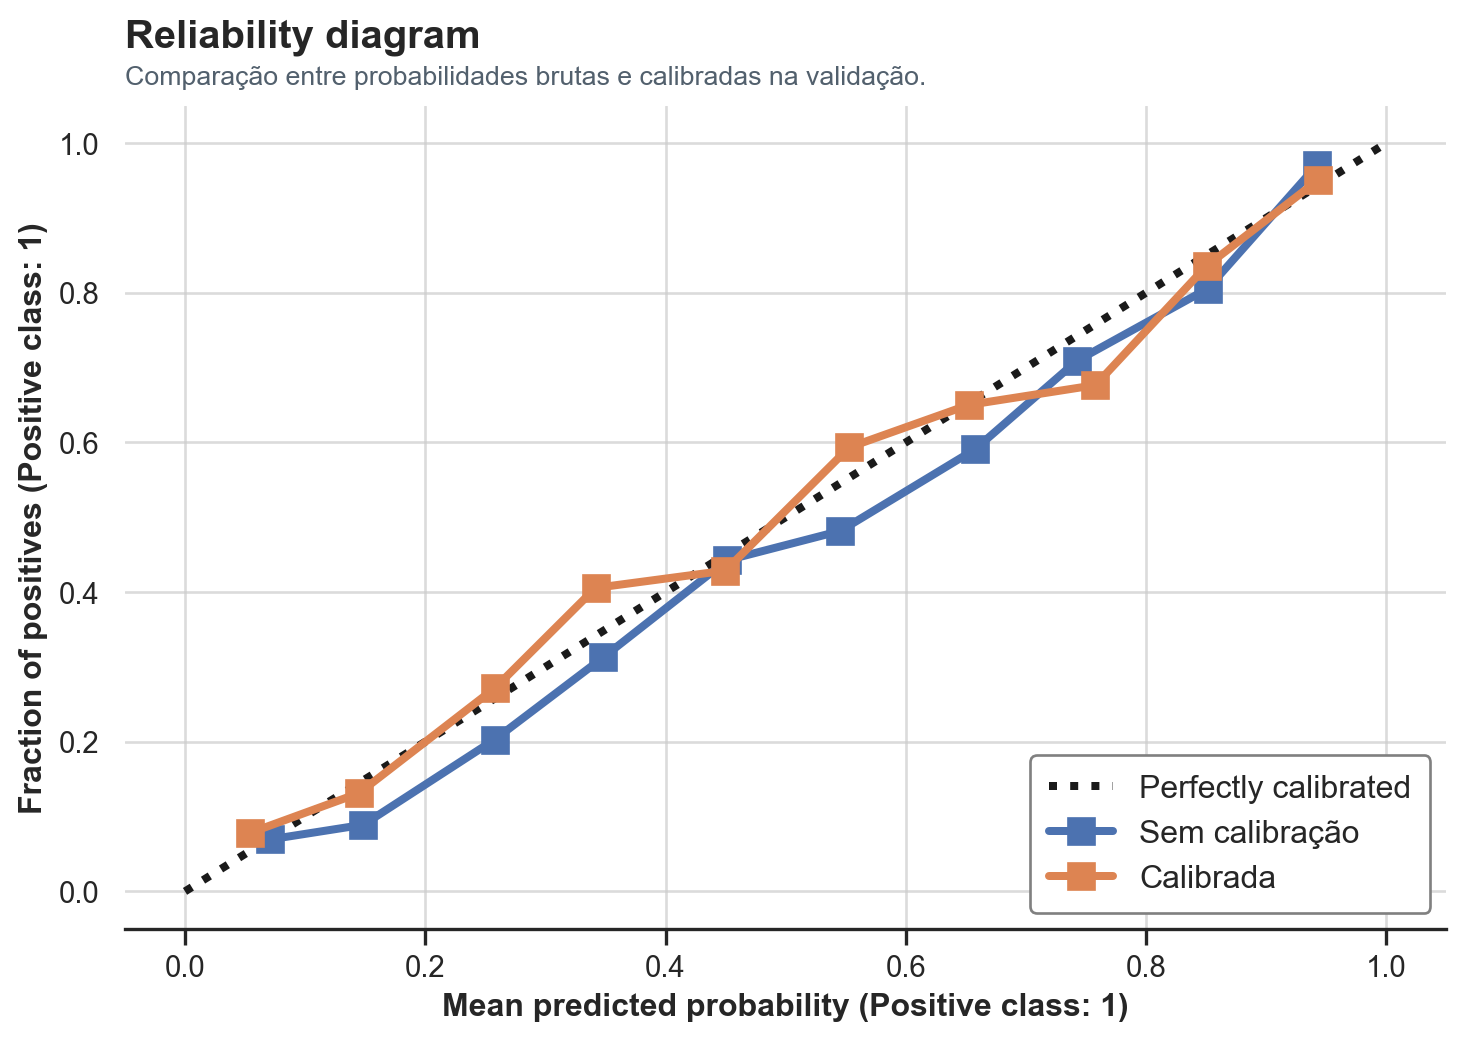

,Modelo,Amostra,ROC_AUC,Recall,Precision,BrierScore
0,LogisticRegression sem calibração,Hold-out,0.80,0.71,0.68,0.18
1,LogisticRegression calibrada,Hold-out,0.80,0.64,0.72,0.18


,Cluster,Clientes,Recency_mean,Frequency_mean,Monetary_mean,AverageTicket_mean,UniqueProducts_mean,ReceitaTotal,PercentualReceita,PredictiveSegment
3,3,480,50.83,20.32,12159.10,554.49,218.43,5836370.05,67.52,Campeões
1,1,783,117.50,6.27,1675.11,283.22,91.83,1311608.58,15.17,Clientes Fiéis
5,5,339,228.23,2.66,2706.62,991.84,62.25,917543.74,10.61,Alto Valor em Risco
2,2,679,407.04,1.69,456.28,287.40,32.11,309814.41,3.58,Clientes Inativos
0,0,545,106.64,2.15,421.96,218.49,23.17,229967.45,2.66,Compradores Ocasionais
4,4,315,390.84,1.28,122.90,101.51,7.01,38713.13,0.45,Baixo Valor


,Customer ID,PredictiveSegment,repurchase_90d,prob_repurchase_90d_raw,prob_repurchase_90d,Recency,Frequency,Monetary,AverageTicket
348,12748,Campeões,1,1.00,1.00,0,259,36987.41,142.81
2002,14606,Campeões,1,1.00,1.00,3,170,28268.60,166.29
4879,17841,Campeões,1,1.00,1.00,1,168,53394.36,317.82
633,13069,Campeões,1,0.98,0.99,9,34,9121.71,268.29
3618,16422,Campeões,1,1.00,0.99,9,97,58084.77,598.81
2038,14646,Campeões,1,1.00,0.99,2,120,426699.12,3555.83
2055,14667,Campeões,1,0.98,0.99,4,47,18756.96,399.08
1276,13798,Campeões,1,0.99,0.99,2,95,67844.16,714.15
1932,14527,Campeões,1,1.00,0.99,8,107,24564.90,229.58
4586,17511,Campeões,1,0.99,0.98,3,50,143916.92,2878.34


In [96]:
numeric_predictors = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageTicket",
    "QuantityTotal",
    "UniqueProducts",
]
categorical_predictors = ["CountryMode"]
model_features = numeric_predictors + categorical_predictors

# CORREÇÃO P1: reset de índice garante alinhamento seguro após merges e filtragens.
predictive_features = predictive_features.reset_index(drop=True)
modeling_df = predictive_features[
    ["Customer ID", "repurchase_90d"] + model_features
].copy()
modeling_df = modeling_df.reset_index(drop=True)  # Índice resetado para garantir alinhamento seguro com X_train.index após splits

X = modeling_df[model_features]
y = modeling_df["repurchase_90d"]
stratify_all = y if y.nunique() == 2 and y.value_counts().min() >= 2 else None

# CORREÇÃO: hold-out independente separado antes de qualquer split de treino/validação.
X_dev, X_hold, y_dev, y_hold = train_test_split(
    X,
    y,
    test_size=HOLDOUT_FRACTION,
    random_state=RANDOM_STATE,
    stratify=stratify_all,
)
stratify_dev = y_dev if y_dev.nunique() == 2 and y_dev.value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X_dev,
    y_dev,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=stratify_dev,
)


class KMeansClusterAdder(BaseEstimator, TransformerMixin):
    """Adiciona `PredictiveCluster` ajustando K-Means apenas no conjunto de treino."""

    def __init__(
        self,
        cluster_features: list[str] | None = None,
        log_features: list[str] | None = None,
        n_clusters: int = N_CLUSTERS,
        random_state: int = 42,
        n_init: int = 20,
    ) -> None:
        self.cluster_features = cluster_features
        self.log_features = log_features
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.n_init = n_init

    def fit(self, X: pd.DataFrame, y: pd.Series | None = None) -> "KMeansClusterAdder":
        # CORREÇÃO: KMeans.fit roda só em X_train dentro do Pipeline; validação e hold-out usam predict.
        x_df = self._as_frame(X, fit=True)
        cluster_input = self._cluster_input(x_df)
        self.cluster_scaler_ = StandardScaler()
        scaled = self.cluster_scaler_.fit_transform(cluster_input)
        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            n_init=self.n_init,
        )
        self.kmeans_.fit(scaled)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        # CORREÇÃO P1: falha explicitamente se transform for chamado antes de fit.
        check_is_fitted(self, ["kmeans_", "cluster_scaler_"])
        x_df = self._as_frame(X, fit=False)
        cluster_input = self._cluster_input(x_df)
        scaled = self.cluster_scaler_.transform(cluster_input)
        x_out = x_df.copy()
        x_out["PredictiveCluster"] = self.kmeans_.predict(scaled).astype(str)
        return x_out

    def _as_frame(self, X: pd.DataFrame, fit: bool) -> pd.DataFrame:
        if isinstance(X, pd.DataFrame):
            if fit:
                self.feature_names_in_ = list(X.columns)
            return X.copy()
        return pd.DataFrame(X, columns=self.feature_names_in_)

    def _cluster_input(self, x_df: pd.DataFrame) -> pd.DataFrame:
        cluster_features = self.cluster_features or numeric_predictors
        log_cols = self.log_features or []
        cluster_input = x_df[cluster_features].copy()
        for col in log_cols:
            if col in cluster_input.columns:
                cluster_input[col] = np.log1p(cluster_input[col].clip(lower=0))
        return cluster_input


def make_one_hot_encoder() -> OneHotEncoder:
    """Cria encoder compatível com versões recentes e antigas do scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor() -> Pipeline:
    """Monta pré-processamento com cluster temporal sem vazamento entre splits."""
    cluster_step = KMeansClusterAdder(
        cluster_features=features,
        log_features=log_features,
        n_clusters=selected_k,
        random_state=RANDOM_STATE,
        n_init=20,
    )
    columns_step = ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_predictors),
            (
                "categorical",
                make_one_hot_encoder(),
                ["CountryMode", "PredictiveCluster"],
            ),
        ]
    )
    return Pipeline([
        ("cluster", cluster_step),
        ("columns", columns_step),
    ])


def make_model_specs() -> dict[str, Any]:
    """Define modelos candidatos para comparação supervisionada."""
    return {
        "LogisticRegression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "RandomForestClassifier": RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "GradientBoostingClassifier": GradientBoostingClassifier(
            random_state=RANDOM_STATE,
        ),
    }


def make_repurchase_pipeline(estimator: Any) -> Pipeline:
    """Combina pré-processamento sem leakage e estimador supervisionado."""
    return Pipeline([
        ("preprocess", make_preprocessor()),
        ("model", estimator),
    ])


def evaluate_classifier(
    model_name: str,
    dataset_name: str,
    estimator: Any,
    X_eval: pd.DataFrame,
    y_eval: pd.Series,
) -> dict[str, float | str]:
    """Calcula métricas de classificação e calibração para uma amostra."""
    y_prob = estimator.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)
    auc = roc_auc_score(y_eval, y_prob) if y_eval.nunique() == 2 else np.nan
    return {
        "Modelo": model_name,
        "Amostra": dataset_name,
        "ROC_AUC": auc,
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_eval, y_pred),
        "BrierScore": brier_score_loss(y_eval, y_prob),
    }


fitted_models = {}
metric_rows = []
for model_name, estimator in make_model_specs().items():
    candidate_pipeline = make_repurchase_pipeline(estimator)
    candidate_pipeline.fit(X_train, y_train)
    metric_rows.append(
        evaluate_classifier(model_name, "Validação", candidate_pipeline, X_test, y_test)
    )
    fitted_models[model_name] = candidate_pipeline

model_metrics = pd.DataFrame(metric_rows).sort_values("ROC_AUC", ascending=False)
display(model_metrics.round(4))

baseline_model_name = "LogisticRegression"
baseline_pipeline = make_repurchase_pipeline(make_model_specs()[baseline_model_name])
baseline_pipeline.fit(X_train, y_train)

# CORREÇÃO: calibração isotônica antes de usar probabilidades em cálculos financeiros.
calibrated_repurchase_model = CalibratedClassifierCV(
    estimator=make_repurchase_pipeline(make_model_specs()[baseline_model_name]),
    method="isotonic",
    cv=5,
)
calibrated_repurchase_model.fit(X_train, y_train)

calibration_metrics = pd.DataFrame([
    evaluate_classifier(
        "LogisticRegression sem calibração",
        "Validação",
        baseline_pipeline,
        X_test,
        y_test,
    ),
    evaluate_classifier(
        "LogisticRegression calibrada",
        "Validação",
        calibrated_repurchase_model,
        X_test,
        y_test,
    ),
])
display(calibration_metrics[["Modelo", "Amostra", "BrierScore"]].round(4))

fig, ax = plt.subplots(figsize=(7.8, 5.6))
CalibrationDisplay.from_estimator(
    baseline_pipeline,
    X_test,
    y_test,
    n_bins=10,
    ax=ax,
    name="Sem calibração",
)
CalibrationDisplay.from_estimator(
    calibrated_repurchase_model,
    X_test,
    y_test,
    n_bins=10,
    ax=ax,
    name="Calibrada",
)
add_titles(
    ax,
    "Reliability diagram",
    "Comparação entre probabilidades brutas e calibradas na validação.",
)
ax.grid(alpha=0.7)
plt.tight_layout()
plt.show()

holdout_metrics = pd.DataFrame([
    evaluate_classifier(
        "LogisticRegression sem calibração",
        "Hold-out",
        baseline_pipeline,
        X_hold,
        y_hold,
    ),
    evaluate_classifier(
        "LogisticRegression calibrada",
        "Hold-out",
        calibrated_repurchase_model,
        X_hold,
        y_hold,
    ),
])
display(
    holdout_metrics[[
        "Modelo",
        "Amostra",
        "ROC_AUC",
        "Recall",
        "Precision",
        "BrierScore",
    ]].round(4)
)

cluster_segmenter = KMeansClusterAdder(
    cluster_features=features,
    log_features=log_features,
    n_clusters=selected_k,
    random_state=RANDOM_STATE,
    n_init=20,
).fit(X_train)
train_clustered = cluster_segmenter.transform(X_train)
train_profile_base = predictive_features.loc[X_train.index].copy()
assert len(train_profile_base) == len(X_train), (
    f"Desalinhamento de índice: train_profile_base tem {len(train_profile_base)} "
    f"linhas, X_train tem {len(X_train)}."
)
train_profile_base["PredictiveCluster"] = train_clustered[
    "PredictiveCluster"
].astype(int).to_numpy()

temporal_profile = train_profile_base.groupby("PredictiveCluster").agg(
    Clientes=("Customer ID", "count"),
    Recency_mean=("Recency", "mean"),
    Frequency_mean=("Frequency", "mean"),
    Monetary_mean=("Monetary", "mean"),
    AverageTicket_mean=("AverageTicket", "mean"),
    UniqueProducts_mean=("UniqueProducts", "mean"),
    ReceitaTotal=("Monetary", "sum"),
).reset_index().rename(columns={"PredictiveCluster": "Cluster"})
temporal_profile["PercentualReceita"] = (
    temporal_profile["ReceitaTotal"] / temporal_profile["ReceitaTotal"].sum() * 100
)

temporal_names = segment_names(temporal_profile)
validate_segment_names(temporal_profile, temporal_names)
temporal_profile["PredictiveSegment"] = temporal_profile["Cluster"].map(
    temporal_names
)

holdout_predictions = predictive_features.loc[X_hold.index].copy()
holdout_clustered = cluster_segmenter.transform(X_hold)
holdout_predictions["PredictiveCluster"] = holdout_clustered[
    "PredictiveCluster"
].astype(int).to_numpy()
holdout_predictions["PredictiveSegment"] = holdout_predictions[
    "PredictiveCluster"
].map(temporal_names)
holdout_predictions["prob_repurchase_90d_raw"] = baseline_pipeline.predict_proba(
    X_hold
)[:, 1]
# CORREÇÃO: probabilidades geradas no hold-out para evitar overfitting na simulação.
holdout_predictions["prob_repurchase_90d"] = calibrated_repurchase_model.predict_proba(
    X_hold
)[:, 1]

prediction_cols = [
    "prob_repurchase_90d_raw",
    "prob_repurchase_90d",
    "PredictiveCluster",
    "PredictiveSegment",
]
predictive_features = predictive_features.drop(
    columns=prediction_cols,
    errors="ignore",
).merge(
    holdout_predictions[["Customer ID"] + prediction_cols],
    on="Customer ID",
    how="left",
)

rfm_probability_cols = ["repurchase_90d"] + prediction_cols
rfm = rfm.drop(columns=rfm_probability_cols, errors="ignore").merge(
    predictive_features[["Customer ID"] + rfm_probability_cols],
    on="Customer ID",
    how="left",
)

display(temporal_profile.sort_values("ReceitaTotal", ascending=False))
display(
    holdout_predictions[[
        "Customer ID",
        "PredictiveSegment",
        "repurchase_90d",
        "prob_repurchase_90d_raw",
        "prob_repurchase_90d",
        "Recency",
        "Frequency",
        "Monetary",
        "AverageTicket",
    ]].sort_values("prob_repurchase_90d", ascending=False).head(10)
)


<span style="color:steelblue; text-align: left">

## Simulação de incentivos e lucro esperado
</span>

A camada prescritiva avalia ações possíveis `z`. Cada ação tem um custo de incentivo, e o uplift passa a variar por segmento temporal. Essa matriz é mais realista que um uplift uniforme, pois segmentos como `Campeões`, `Clientes Inativos` e `Alto Valor em Risco` tendem a reagir de forma diferente a campanhas.

Os valores continuam sendo hipóteses de simulação de negócio, não efeitos causais estimados. Para cada cliente e ação, o lucro esperado é calculado como: `expected_probability = min(prob_repurchase_90d + uplift, 1)`, `expected_revenue = expected_probability * AverageTicket` e `expected_profit = expected_revenue - incentive_cost`.


In [97]:
action_catalog = pd.DataFrame([
    {
        "Action": "No Action",
        "RecommendedAction": "Manter sem incentivo",
        "incentive_cost": 0.00,
    },
    {
        "Action": "Low Incentive",
        "RecommendedAction": "Campanha leve",
        "incentive_cost": 2.00,
    },
    {
        "Action": "Medium Incentive",
        "RecommendedAction": "Campanha intermediária",
        "incentive_cost": 5.00,
    },
    {
        "Action": "High Incentive",
        "RecommendedAction": "Campanha agressiva",
        "incentive_cost": 10.00,
    },
])

# CORREÇÃO: uplift hipotético por segmento — validar com experimento A/B em produção.
uplift_matrix = pd.DataFrame([
    {
        "PredictiveSegment": "Campeões",
        "No Action": 0.00,
        "Low Incentive": 0.02,
        "Medium Incentive": 0.04,
        "High Incentive": 0.05,
    },
    {
        "PredictiveSegment": "Alto Valor em Risco",
        "No Action": 0.00,
        "Low Incentive": 0.04,
        "Medium Incentive": 0.09,
        "High Incentive": 0.15,
    },
    {
        "PredictiveSegment": "Clientes Fiéis",
        "No Action": 0.00,
        "Low Incentive": 0.03,
        "Medium Incentive": 0.07,
        "High Incentive": 0.10,
    },
    {
        "PredictiveSegment": "Compradores Ocasionais",
        "No Action": 0.00,
        "Low Incentive": 0.05,
        "Medium Incentive": 0.10,
        "High Incentive": 0.13,
    },
    {
        "PredictiveSegment": "Baixo Valor",
        "No Action": 0.00,
        "Low Incentive": 0.02,
        "Medium Incentive": 0.04,
        "High Incentive": 0.05,
    },
    {
        "PredictiveSegment": "Clientes Inativos",
        "No Action": 0.00,
        "Low Incentive": 0.01,
        "Medium Incentive": 0.03,
        "High Incentive": 0.04,
    },
])
uplift_long = uplift_matrix.melt(
    id_vars="PredictiveSegment",
    var_name="Action",
    value_name="uplift",
)
incentive_actions = uplift_long.merge(action_catalog, on="Action", how="left")

# A simulação usa apenas clientes do hold-out, ou seja, dados nunca vistos pelo modelo.
decision_base = holdout_predictions[[
    "Customer ID",
    "PredictiveCluster",
    "PredictiveSegment",
    "Recency",
    "Frequency",
    "Monetary",
    "AverageTicket",
    "prob_repurchase_90d",
    "repurchase_90d",
]].copy()
decision_base["_key"] = 1
simulation_actions = action_catalog.copy()
simulation_actions["_key"] = 1

decision_simulation = decision_base.merge(
    simulation_actions,
    on="_key",
).drop(columns="_key")
# CORREÇÃO: join por cliente, segmento e ação para buscar o uplift correto.
decision_simulation = decision_simulation.merge(
    uplift_long,
    on=["PredictiveSegment", "Action"],
    how="left",
)
missing_uplift = decision_simulation["uplift"].isna().sum()
if missing_uplift:
    warnings.warn(
        f"{missing_uplift} combinações cliente/segmento/ação ficaram sem uplift.",
        stacklevel=2,
    )

decision_simulation["expected_probability"] = (
    decision_simulation["prob_repurchase_90d"] + decision_simulation["uplift"]
).clip(upper=1)
decision_simulation["expected_revenue"] = (
    decision_simulation["expected_probability"] * decision_simulation["AverageTicket"]
)
decision_simulation["expected_profit"] = (
    decision_simulation["expected_revenue"] - decision_simulation["incentive_cost"]
)

no_action_profit = decision_simulation.loc[
    decision_simulation["Action"] == "No Action",
    ["Customer ID", "expected_profit"],
].rename(columns={"expected_profit": "ExpectedProfit_NoAction"})

best_action_idx = decision_simulation.groupby("Customer ID")[
    "expected_profit"
].idxmax()
prescriptive_df = decision_simulation.loc[best_action_idx].copy()
prescriptive_df = prescriptive_df.merge(no_action_profit, on="Customer ID", how="left")
prescriptive_df = prescriptive_df.rename(columns={
    "Action": "BestAction",
    "expected_profit": "ExpectedProfit",
})
prescriptive_df["IncrementalProfit"] = (
    prescriptive_df["ExpectedProfit"]
    - prescriptive_df["ExpectedProfit_NoAction"]
)

display(
    incentive_actions[[
        "PredictiveSegment",
        "Action",
        "RecommendedAction",
        "incentive_cost",
        "uplift",
    ]].sort_values(["PredictiveSegment", "Action"])
)
display(
    decision_simulation[[
        "Customer ID",
        "PredictiveSegment",
        "Action",
        "prob_repurchase_90d",
        "uplift",
        "expected_probability",
        "AverageTicket",
        "incentive_cost",
        "expected_profit",
    ]].head(12)
)


,PredictiveSegment,Action,RecommendedAction,incentive_cost,uplift
19,Alto Valor em Risco,High Incentive,Campanha agressiva,10.00,0.15
7,Alto Valor em Risco,Low Incentive,Campanha leve,2.00,0.04
13,Alto Valor em Risco,Medium Incentive,Campanha intermediária,5.00,0.09
1,Alto Valor em Risco,No Action,Manter sem incentivo,0.00,0.00
22,Baixo Valor,High Incentive,Campanha agressiva,10.00,0.05
10,Baixo Valor,Low Incentive,Campanha leve,2.00,0.02
16,Baixo Valor,Medium Incentive,Campanha intermediária,5.00,0.04
4,Baixo Valor,No Action,Manter sem incentivo,0.00,0.00
18,Campeões,High Incentive,Campanha agressiva,10.00,0.05
6,Campeões,Low Incentive,Campanha leve,2.00,0.02


,Customer ID,PredictiveSegment,Action,prob_repurchase_90d,uplift,expected_probability,AverageTicket,incentive_cost,expected_profit
0,14538,Clientes Fiéis,No Action,0.44,0.00,0.44,272.27,0.00,119.58
1,14538,Clientes Fiéis,Low Incentive,0.44,0.03,0.47,272.27,2.00,125.75
2,14538,Clientes Fiéis,Medium Incentive,0.44,0.07,0.51,272.27,5.00,133.64
3,14538,Clientes Fiéis,High Incentive,0.44,0.10,0.54,272.27,10.00,136.81
4,12836,Campeões,No Action,0.87,0.00,0.87,434.66,0.00,377.92
5,12836,Campeões,Low Incentive,0.87,0.02,0.89,434.66,2.00,384.61
6,12836,Campeões,Medium Incentive,0.87,0.04,0.91,434.66,5.00,390.30
7,12836,Campeões,High Incentive,0.87,0.05,0.92,434.66,10.00,389.65
8,16071,Clientes Inativos,No Action,0.16,0.00,0.16,250.19,0.00,41.23
9,16071,Clientes Inativos,Low Incentive,0.16,0.01,0.17,250.19,2.00,41.74


<span style="color:steelblue; text-align: left">

## Recomendação prescritiva de Next Best Action
</span>

A decisão final testa todas as ações disponíveis para cada cliente e seleciona aquela com maior `ExpectedProfit`. O ganho incremental compara a melhor ação contra `No Action`. Assim, a Next Best Action deixa de ser apenas uma regra por cluster e passa a ser uma decisão baseada em lucro esperado.


In [98]:
def build_prescriptive_recommendation(row: pd.Series) -> str:
    """Traduz a ação ótima simulada em uma recomendação executiva de negócio."""
    # CORREÇÃO: função principal com type hint e docstring para uso em portfólio.
    action_label = row["RecommendedAction"]
    segment = row["PredictiveSegment"]
    incremental = row["IncrementalProfit"]

    if row["BestAction"] == "No Action" or incremental <= 0:
        return f"{action_label}: preservar margem; incentivo não aumenta lucro esperado."
    if segment in ["Campeões", "Alto Valor em Risco"] and row["BestAction"] == "High Incentive":
        return "Prioridade máxima de retenção com campanha agressiva."
    if segment in ["Campeões", "Alto Valor em Risco"]:
        return f"Priorizar relacionamento com {action_label.lower()}."
    if segment == "Baixo Valor" and row["BestAction"] == "High Incentive":
        return "Revisar custo antes de campanha agressiva para cliente de baixo valor."
    if segment == "Clientes Inativos":
        return f"Testar reativação controlada com {action_label.lower()}."
    return f"Executar {action_label.lower()} conforme lucro esperado positivo."


prescriptive_df["PrescriptiveNextBestAction"] = prescriptive_df.apply(
    build_prescriptive_recommendation,
    axis=1,
)
prescriptive_df["ClusterSegment"] = (
    "C"
    + prescriptive_df["PredictiveCluster"].astype(str)
    + " - "
    + prescriptive_df["PredictiveSegment"]
)

prescriptive_cols = [
    "BestAction",
    "RecommendedAction",
    "ExpectedProfit",
    "ExpectedProfit_NoAction",
    "IncrementalProfit",
    "PrescriptiveNextBestAction",
]
rfm = rfm.drop(columns=prescriptive_cols, errors="ignore").merge(
    prescriptive_df[["Customer ID"] + prescriptive_cols],
    on="Customer ID",
    how="left",
)

action_summary = prescriptive_df.groupby(
    ["BestAction", "RecommendedAction"],
    as_index=False,
).agg(
    Clientes=("Customer ID", "count"),
    LucroEsperadoTotal=("ExpectedProfit", "sum"),
    LucroIncrementalTotal=("IncrementalProfit", "sum"),
    TicketMedio=("AverageTicket", "mean"),
    ProbabilidadeMediaRecompra=("prob_repurchase_90d", "mean"),
).sort_values("LucroIncrementalTotal", ascending=False)

cluster_action_summary = prescriptive_df.groupby(
    ["PredictiveCluster", "PredictiveSegment", "RecommendedAction"],
    as_index=False,
).agg(
    Clientes=("Customer ID", "count"),
    LucroEsperadoTotal=("ExpectedProfit", "sum"),
    LucroIncrementalTotal=("IncrementalProfit", "sum"),
    ProbabilidadeMediaRecompra=("prob_repurchase_90d", "mean"),
)

display(action_summary.round(4))
display(
    cluster_action_summary.sort_values(
        ["PredictiveCluster", "LucroIncrementalTotal"],
        ascending=[True, False],
    ).head(20).round(4)
)
display(
    prescriptive_df[[
        "Customer ID",
        "PredictiveSegment",
        "prob_repurchase_90d",
        "AverageTicket",
        "BestAction",
        "RecommendedAction",
        "ExpectedProfit",
        "ExpectedProfit_NoAction",
        "IncrementalProfit",
        "PrescriptiveNextBestAction",
    ]].sort_values("IncrementalProfit", ascending=False).head(10)
)


,BestAction,RecommendedAction,Clientes,LucroEsperadoTotal,LucroIncrementalTotal,TicketMedio,ProbabilidadeMediaRecompra
0,High Incentive,Campanha agressiva,403,114445.95,19151.67,490.41,0.50
2,Medium Incentive,Campanha intermediária,311,34735.07,1708.29,257.50,0.40
1,Low Incentive,Campanha leve,31,9302.76,128.41,384.79,0.33
3,No Action,Manter sem incentivo,48,1299.17,0.00,99.79,0.20


,PredictiveCluster,PredictiveSegment,RecommendedAction,Clientes,LucroEsperadoTotal,LucroIncrementalTotal,ProbabilidadeMediaRecompra
0,0,Compradores Ocasionais,Campanha agressiva,97,13525.21,2652.33,0.39
1,0,Compradores Ocasionais,Campanha intermediária,59,3256.63,440.89,0.39
2,1,Clientes Fiéis,Campanha agressiva,165,30245.01,3125.60,0.57
3,1,Clientes Fiéis,Campanha intermediária,18,1595.51,81.10,0.62
5,2,Clientes Inativos,Campanha intermediária,156,9310.71,571.85,0.19
4,2,Clientes Inativos,Campanha agressiva,6,695.14,75.82,0.19
6,2,Clientes Inativos,Manter sem incentivo,18,495.94,0.00,0.19
7,3,Campeões,Campanha agressiva,37,27176.14,1202.39,0.82
8,3,Campeões,Campanha intermediária,66,20313.54,574.55,0.87
9,3,Campeões,Campanha leve,8,8991.94,116.03,0.99


,Customer ID,PredictiveSegment,prob_repurchase_90d,AverageTicket,BestAction,RecommendedAction,ExpectedProfit,ExpectedProfit_NoAction,IncrementalProfit,PrescriptiveNextBestAction
158,13687,Alto Valor em Risco,0.33,11880.84,High Incentive,Campanha agressiva,5644.12,3872.00,1772.13,Prioridade máxima de retenção com campanha agressiva.
24,12590,Alto Valor em Risco,0.35,4932.13,High Incentive,Campanha agressiva,2462.10,1732.29,729.82,Prioridade máxima de retenção com campanha agressiva.
208,14063,Alto Valor em Risco,0.17,2523.36,High Incentive,Campanha agressiva,804.66,436.16,368.50,Prioridade máxima de retenção com campanha agressiva.
65,12911,Alto Valor em Risco,0.16,1680.47,High Incentive,Campanha agressiva,514.63,272.56,242.07,Prioridade máxima de retenção com campanha agressiva.
167,13734,Alto Valor em Risco,0.15,1675.41,High Incentive,Campanha agressiva,490.73,249.42,241.31,Prioridade máxima de retenção com campanha agressiva.
377,15310,Alto Valor em Risco,0.17,1634.64,High Incentive,Campanha agressiva,519.63,284.44,235.20,Prioridade máxima de retenção com campanha agressiva.
51,12798,Alto Valor em Risco,0.34,1570.46,High Incentive,Campanha agressiva,759.51,533.94,225.57,Prioridade máxima de retenção com campanha agressiva.
67,12967,Alto Valor em Risco,0.28,1435.64,High Incentive,Campanha agressiva,602.72,397.38,205.35,Prioridade máxima de retenção com campanha agressiva.
34,12653,Alto Valor em Risco,0.53,1386.94,High Incentive,Campanha agressiva,930.76,732.72,198.04,Prioridade máxima de retenção com campanha agressiva.
327,14899,Alto Valor em Risco,0.28,1384.88,High Incentive,Campanha agressiva,581.06,383.33,197.73,Prioridade máxima de retenção com campanha agressiva.


<span style="color:steelblue; text-align: left">

## Alocação de budget com restrição orçamentária
</span>

A decisão ótima por cliente ignora que o orçamento de marketing é finito. Nesta etapa, a recomendação prescritiva é submetida a um `budget_total` e uma seleção gulosa prioriza clientes com maior lucro incremental esperado até consumir o orçamento disponível.

Essa alocação gulosa é uma heurística. Para uma otimização exata com múltiplas restrições, limites por segmento, capacidade operacional ou regras comerciais adicionais, o próximo passo seria formular o problema como programação linear inteira (ILP).


<span style="color:steelblue; text-align: left">

## Nota sobre escopo da simulação de budget
</span>

A simulação de incentivos e a alocação de budget operam sobre o **hold-out set**
(aproximadamente 15% da base total de clientes), que é o subconjunto para o qual
o modelo gerou probabilidades em dados nunca vistos durante o treinamento.

Esse recorte é uma escolha metodológica deliberada: usar o hold-out garante que
os lucros esperados não estejam inflados por overfitting. Em produção, o modelo
calibrado seria aplicado sobre **toda a base ativa**, e a simulação de budget
cobriria todos os clientes elegíveis.

Para escalar os resultados à base completa, multiplicar os valores por
`1 / HOLDOUT_FRACTION`, onde `HOLDOUT_FRACTION = 0.15`.


,Métrica,Valor
0,Escopo da simulação,Hold-out set (≈15% da base)
1,Fração da base total,793 de 5281 clientes com features
2,Budget total,"10.000,00"
3,Budget utilizado,"5.647,00"
4,Budget restante,"4.353,00"
5,Clientes atendidos,745
6,Lucro incremental esperado,"20.988,37"


,PredictiveSegment,ClientesAtendidos,CustoTotal,LucroIncrementalEsperadoTotal,ROIEstimado
0,Alto Valor em Risco,98,980.00,12095.52,12.34
3,Clientes Fiéis,183,1740.00,3206.70,1.84
5,Compradores Ocasionais,156,1265.00,3093.23,2.45
2,Campeões,111,716.00,1892.97,2.64
4,Clientes Inativos,162,840.00,647.67,0.77
1,Baixo Valor,35,106.00,52.28,0.49


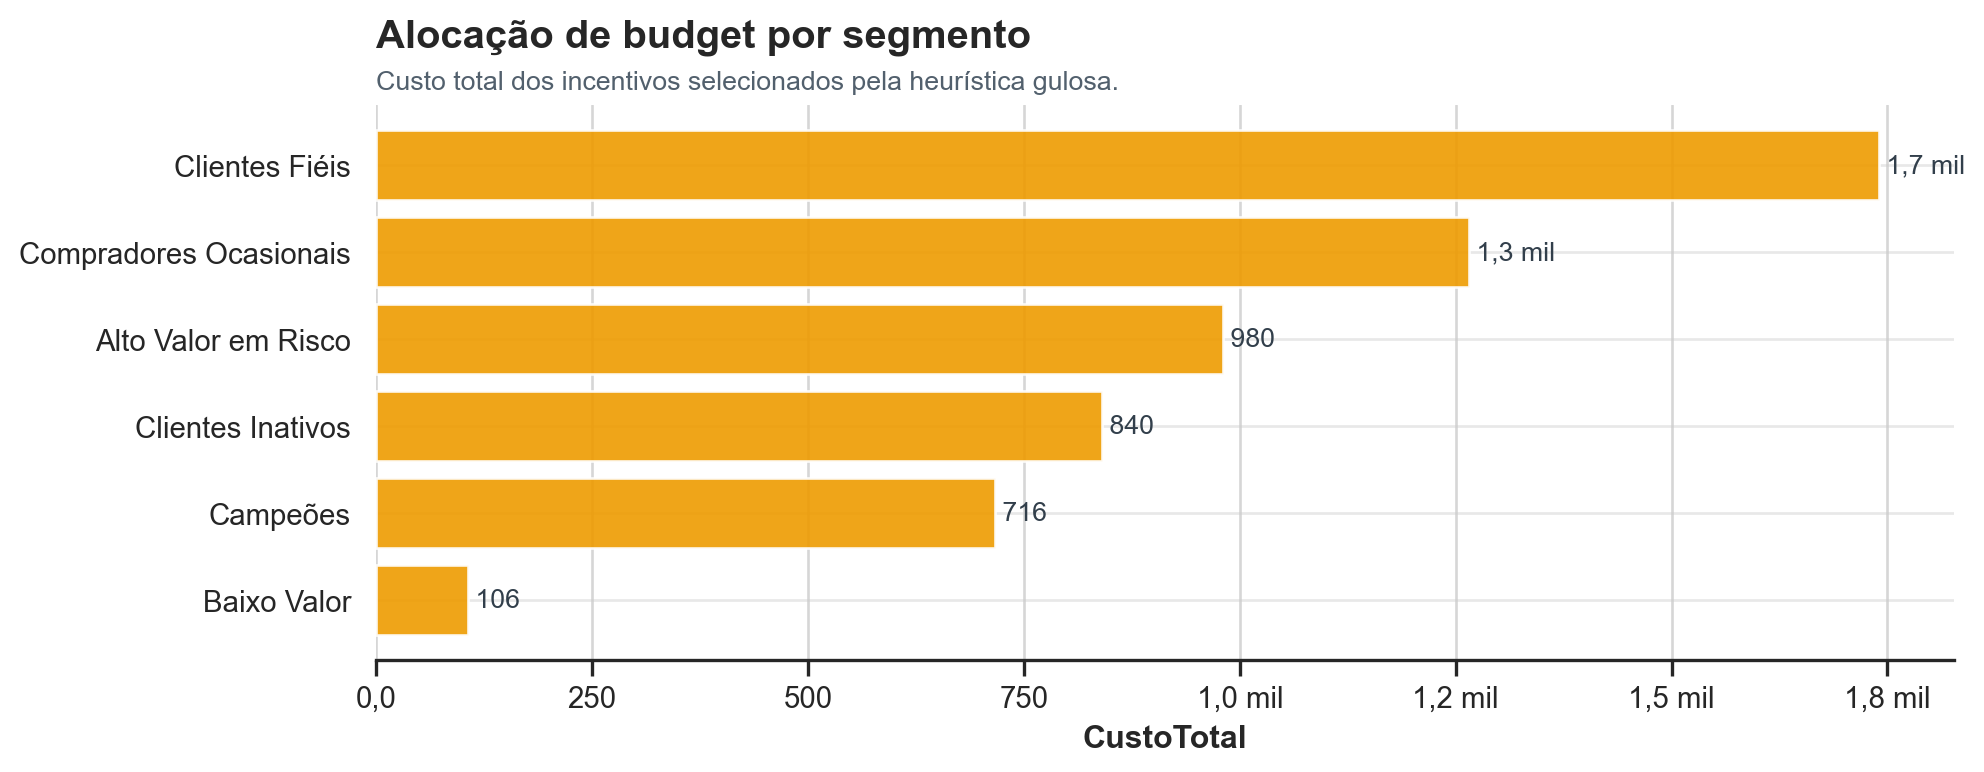

In [99]:
# CORREÇÃO P4: budget parametrizado na célula de configuração.
budget_total = BUDGET_TOTAL

# CORREÇÃO: alocação gulosa é uma heurística — para otimização exata, usar ILP.
budget_candidates = prescriptive_df.loc[
    (prescriptive_df["BestAction"] != "No Action")
    & (prescriptive_df["IncrementalProfit"] > 0)
    & (prescriptive_df["incentive_cost"] > 0)
].copy()
budget_candidates["ExpectedROI"] = np.where(
    budget_candidates["incentive_cost"] > 0,
    budget_candidates["IncrementalProfit"] / budget_candidates["incentive_cost"],
    0.0,
)
budget_candidates = budget_candidates.sort_values(
    "IncrementalProfit",
    ascending=False,
).copy()

remaining_budget = budget_total
selected_indices = []
for idx, row in budget_candidates.iterrows():
    cost = row["incentive_cost"]
    if cost <= remaining_budget:
        selected_indices.append(idx)
        remaining_budget -= cost

budget_selected = budget_candidates.loc[selected_indices].copy()
if budget_selected.empty:
    budget_segment_summary = pd.DataFrame(columns=[
        "PredictiveSegment",
        "ClientesAtendidos",
        "CustoTotal",
        "LucroIncrementalEsperadoTotal",
        "ROIEstimado",
    ])
else:
    budget_segment_summary = budget_selected.groupby(
        "PredictiveSegment",
        as_index=False,
    ).agg(
        ClientesAtendidos=("Customer ID", "count"),
        CustoTotal=("incentive_cost", "sum"),
        LucroIncrementalEsperadoTotal=("IncrementalProfit", "sum"),
    )
    budget_segment_summary["ROIEstimado"] = np.where(
        budget_segment_summary["CustoTotal"] > 0,
        budget_segment_summary["LucroIncrementalEsperadoTotal"]
        / budget_segment_summary["CustoTotal"],
        0.0,
    )
    budget_segment_summary = budget_segment_summary.sort_values(
        "LucroIncrementalEsperadoTotal",
        ascending=False,
    )

# CORREÇÃO P2: escopo explícito evita interpretação incorreta dos resultados.
budget_overview = pd.DataFrame({
    "Métrica": [
        "Escopo da simulação",
        "Fração da base total",
        "Budget total",
        "Budget utilizado",
        "Budget restante",
        "Clientes atendidos",
        "Lucro incremental esperado",
    ],
    "Valor": [
        "Hold-out set (≈15% da base)",
        f"{len(prescriptive_df)} de {len(predictive_features)} clientes com features",
        fmt(budget_total, 2),
        fmt(budget_selected["incentive_cost"].sum(), 2),
        fmt(remaining_budget, 2),
        fmt(len(budget_selected)),
        fmt(budget_selected["IncrementalProfit"].sum(), 2),
    ],
})

display(budget_overview)
display(budget_segment_summary.round(4))

if not budget_segment_summary.empty:
    barh(
        budget_segment_summary.sort_values("CustoTotal"),
        "PredictiveSegment",
        "CustoTotal",
        "Alocação de budget por segmento",
        "Custo total dos incentivos selecionados pela heurística gulosa.",
        PALETTE[3],
    )


<span style="color:steelblue; text-align: left">

## Visualizações da camada prescritiva
</span>

As visualizações abaixo conectam probabilidade calibrada de recompra, segmento temporal, ação recomendada e lucro incremental. A leitura deve separar duas coisas: a probabilidade vem do modelo supervisionado calibrado no hold-out; o ganho incremental vem da simulação de incentivo e depende diretamente das hipóteses de uplift e custo.


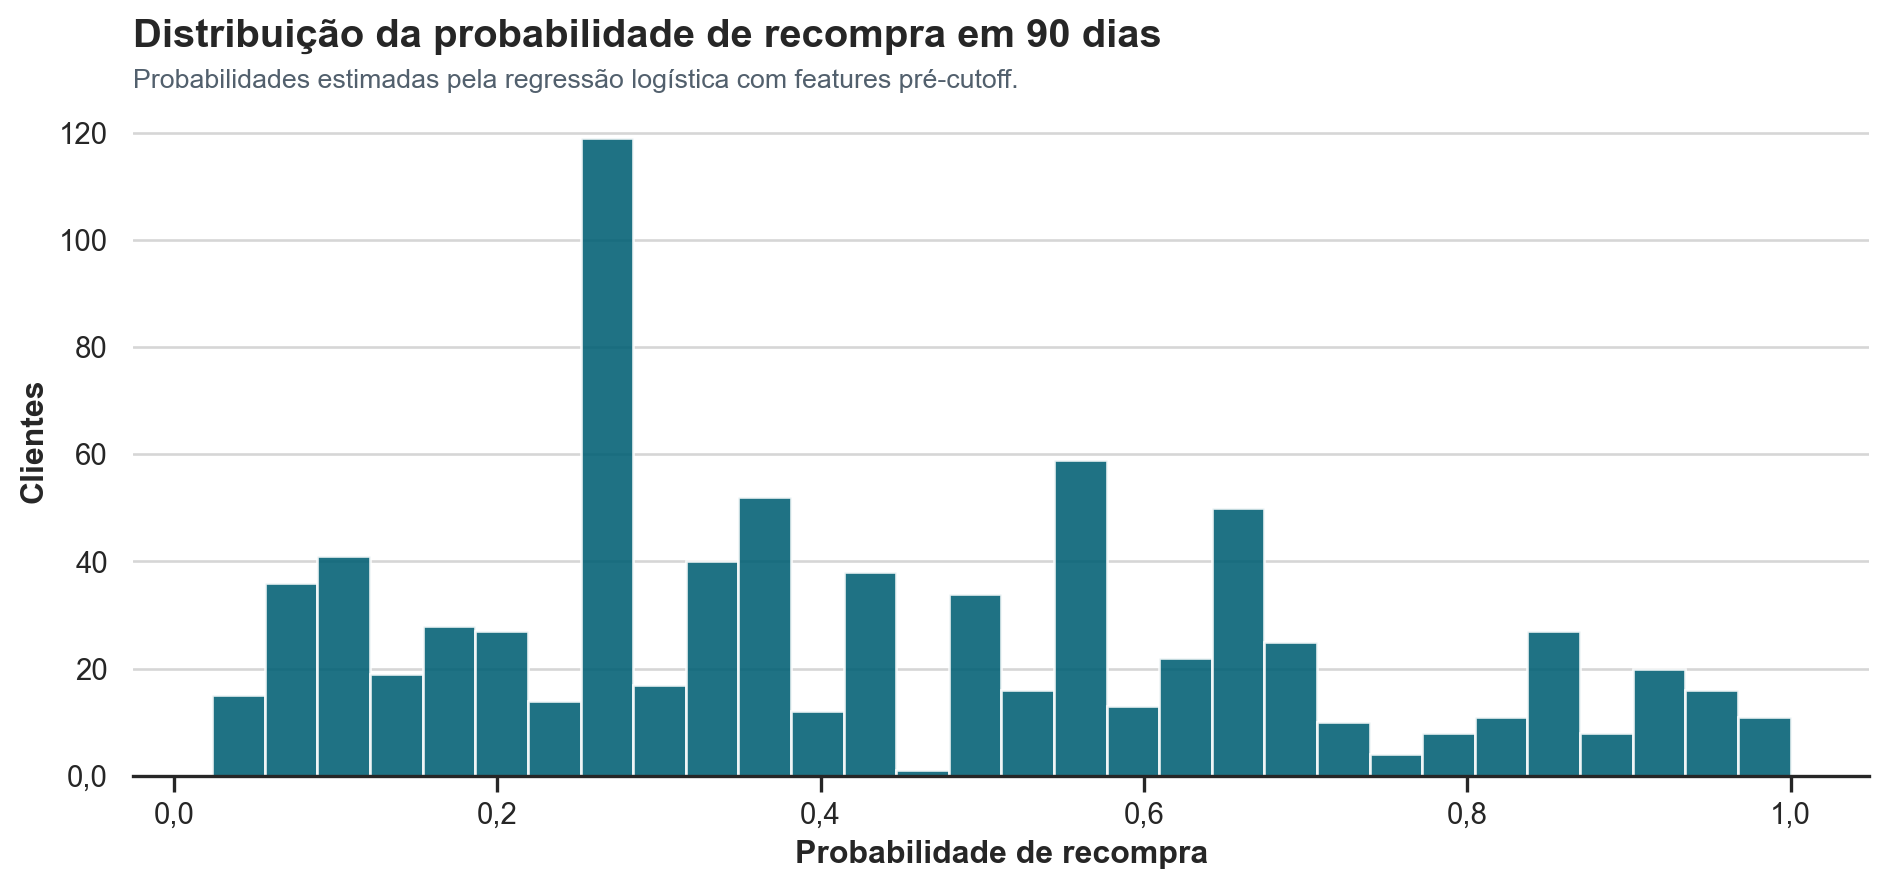

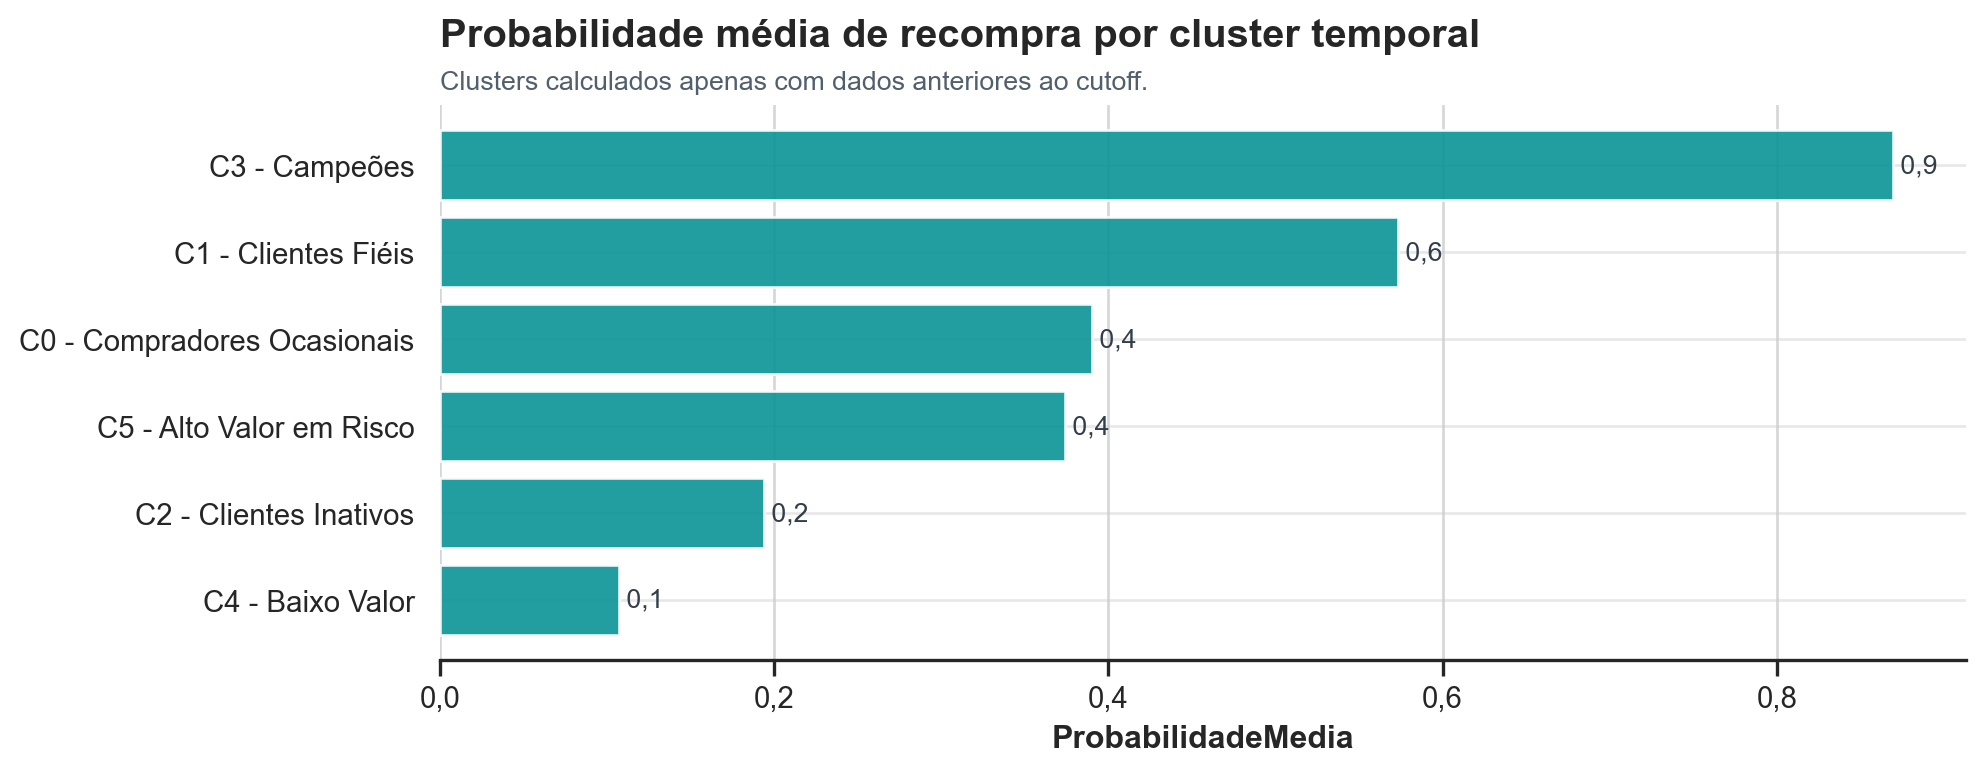

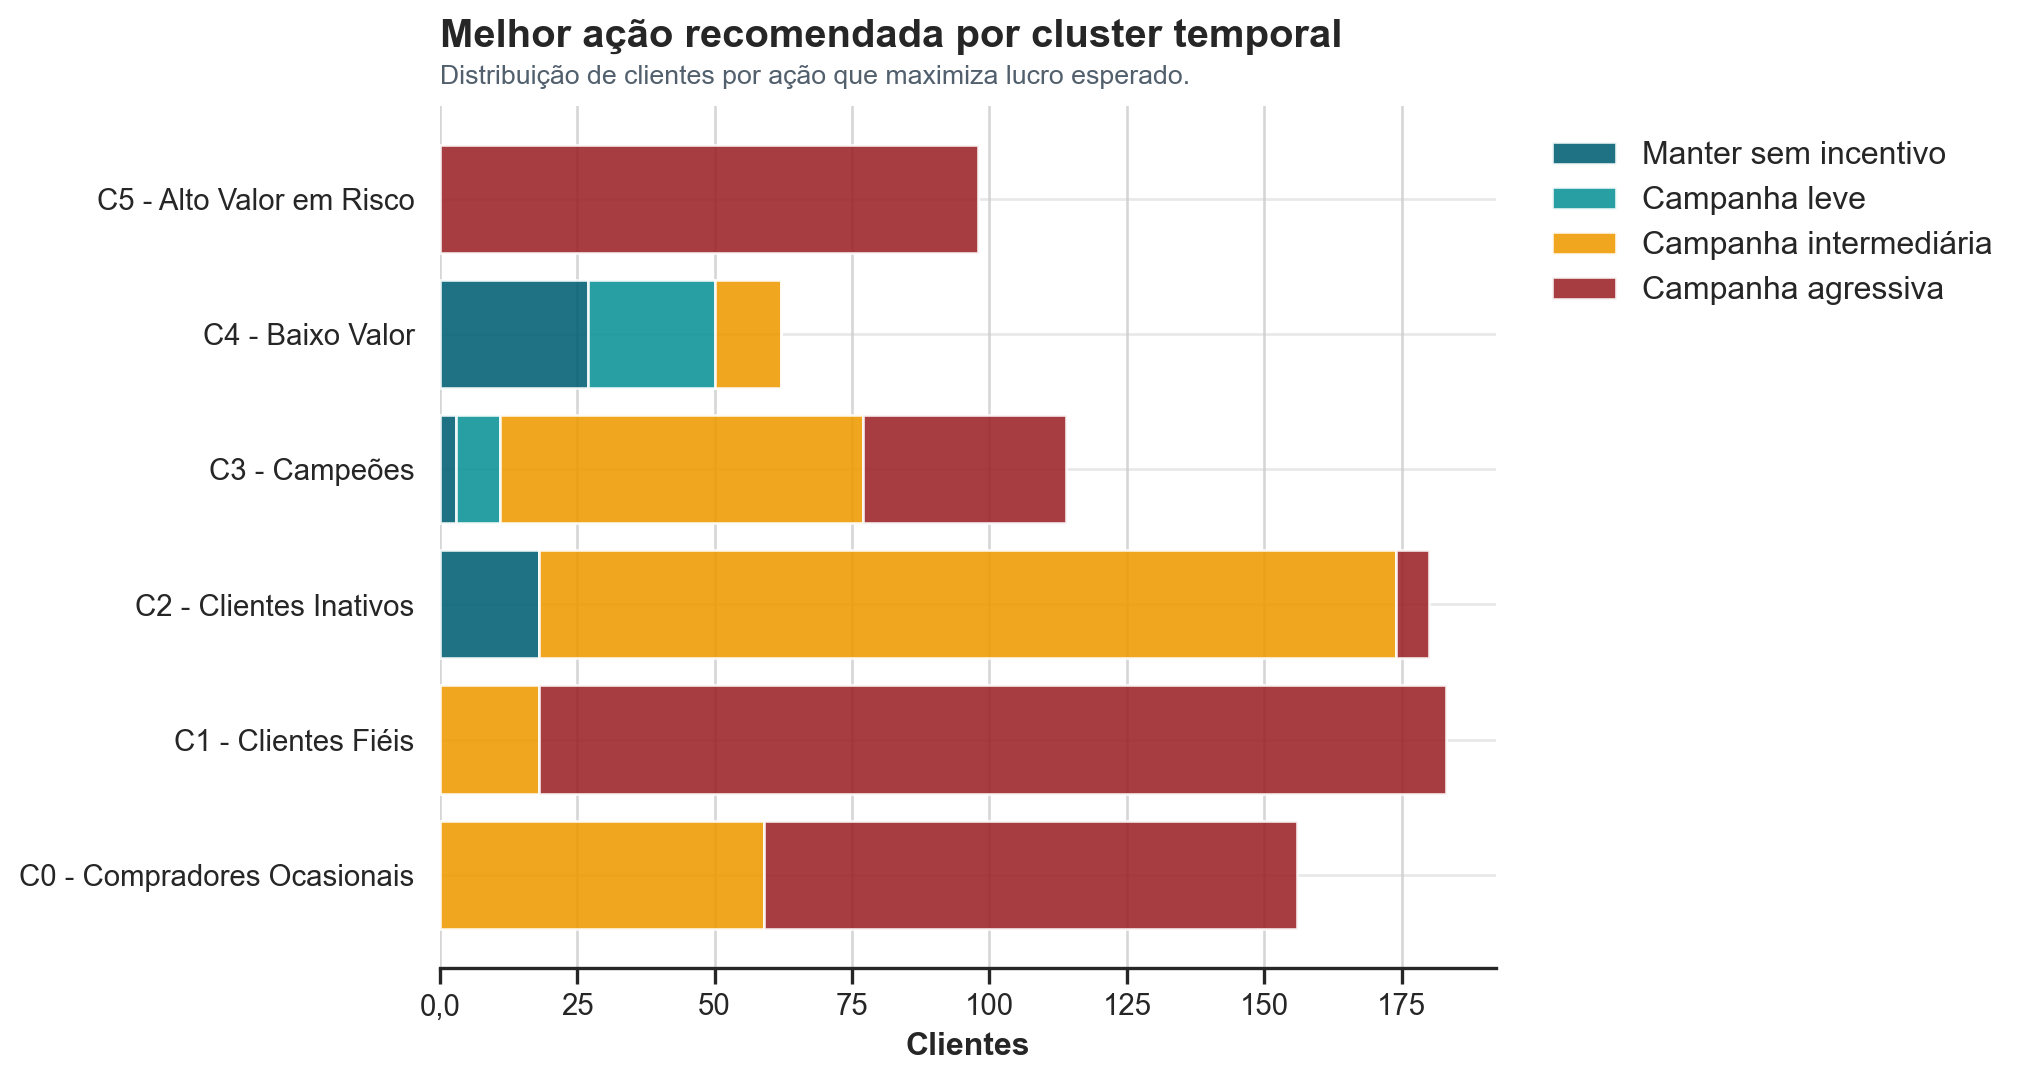

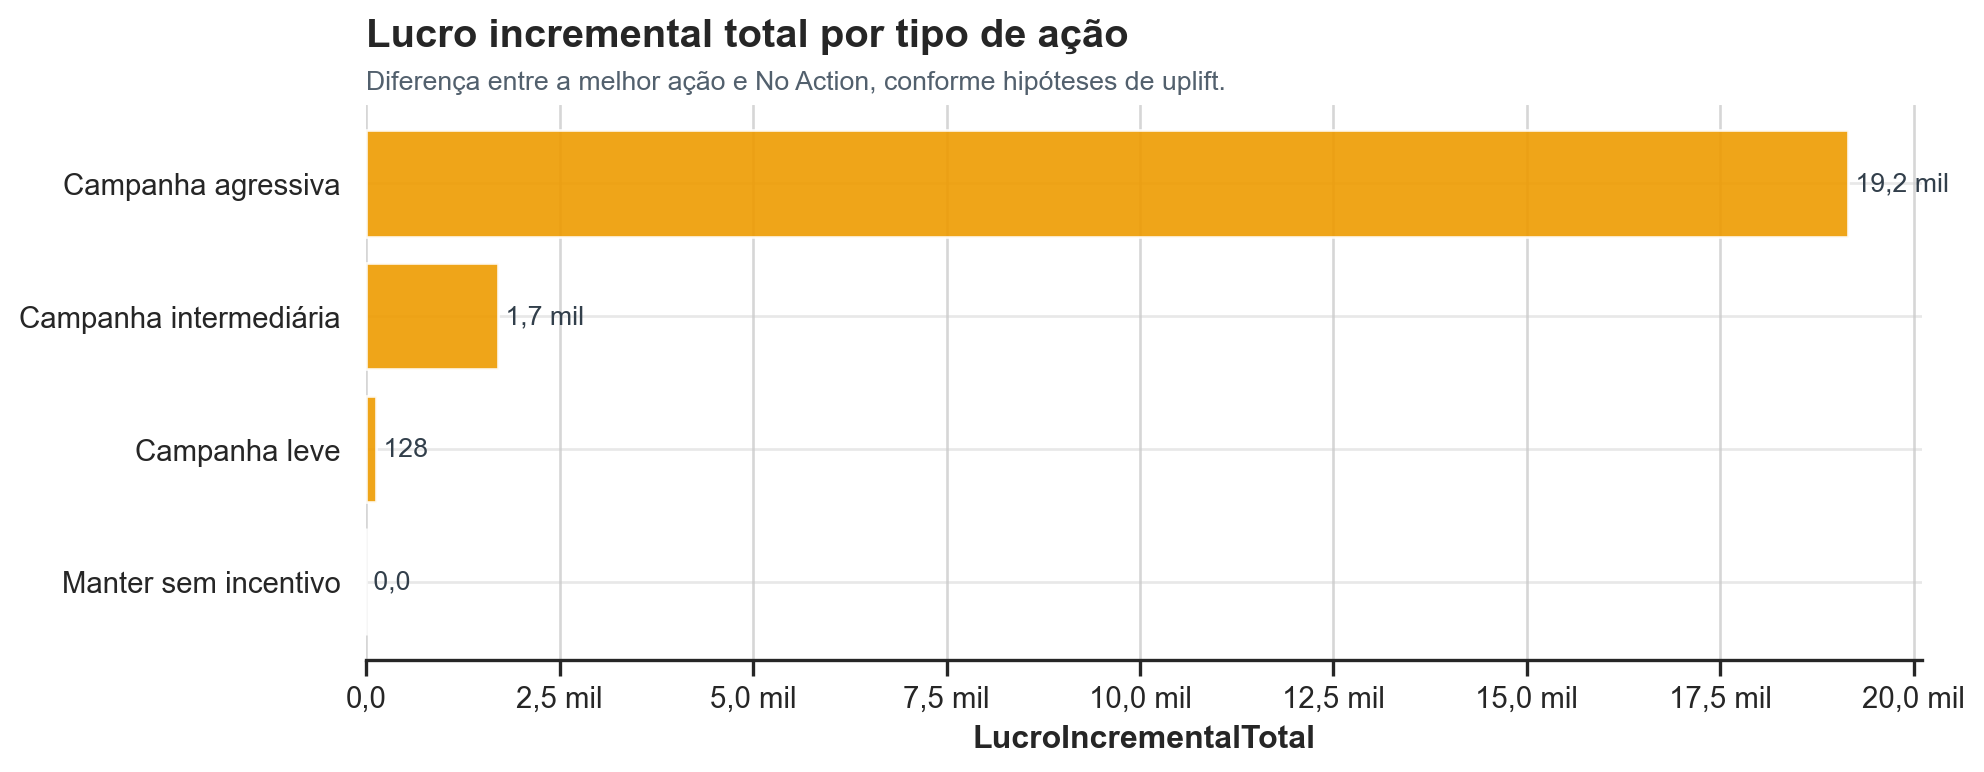

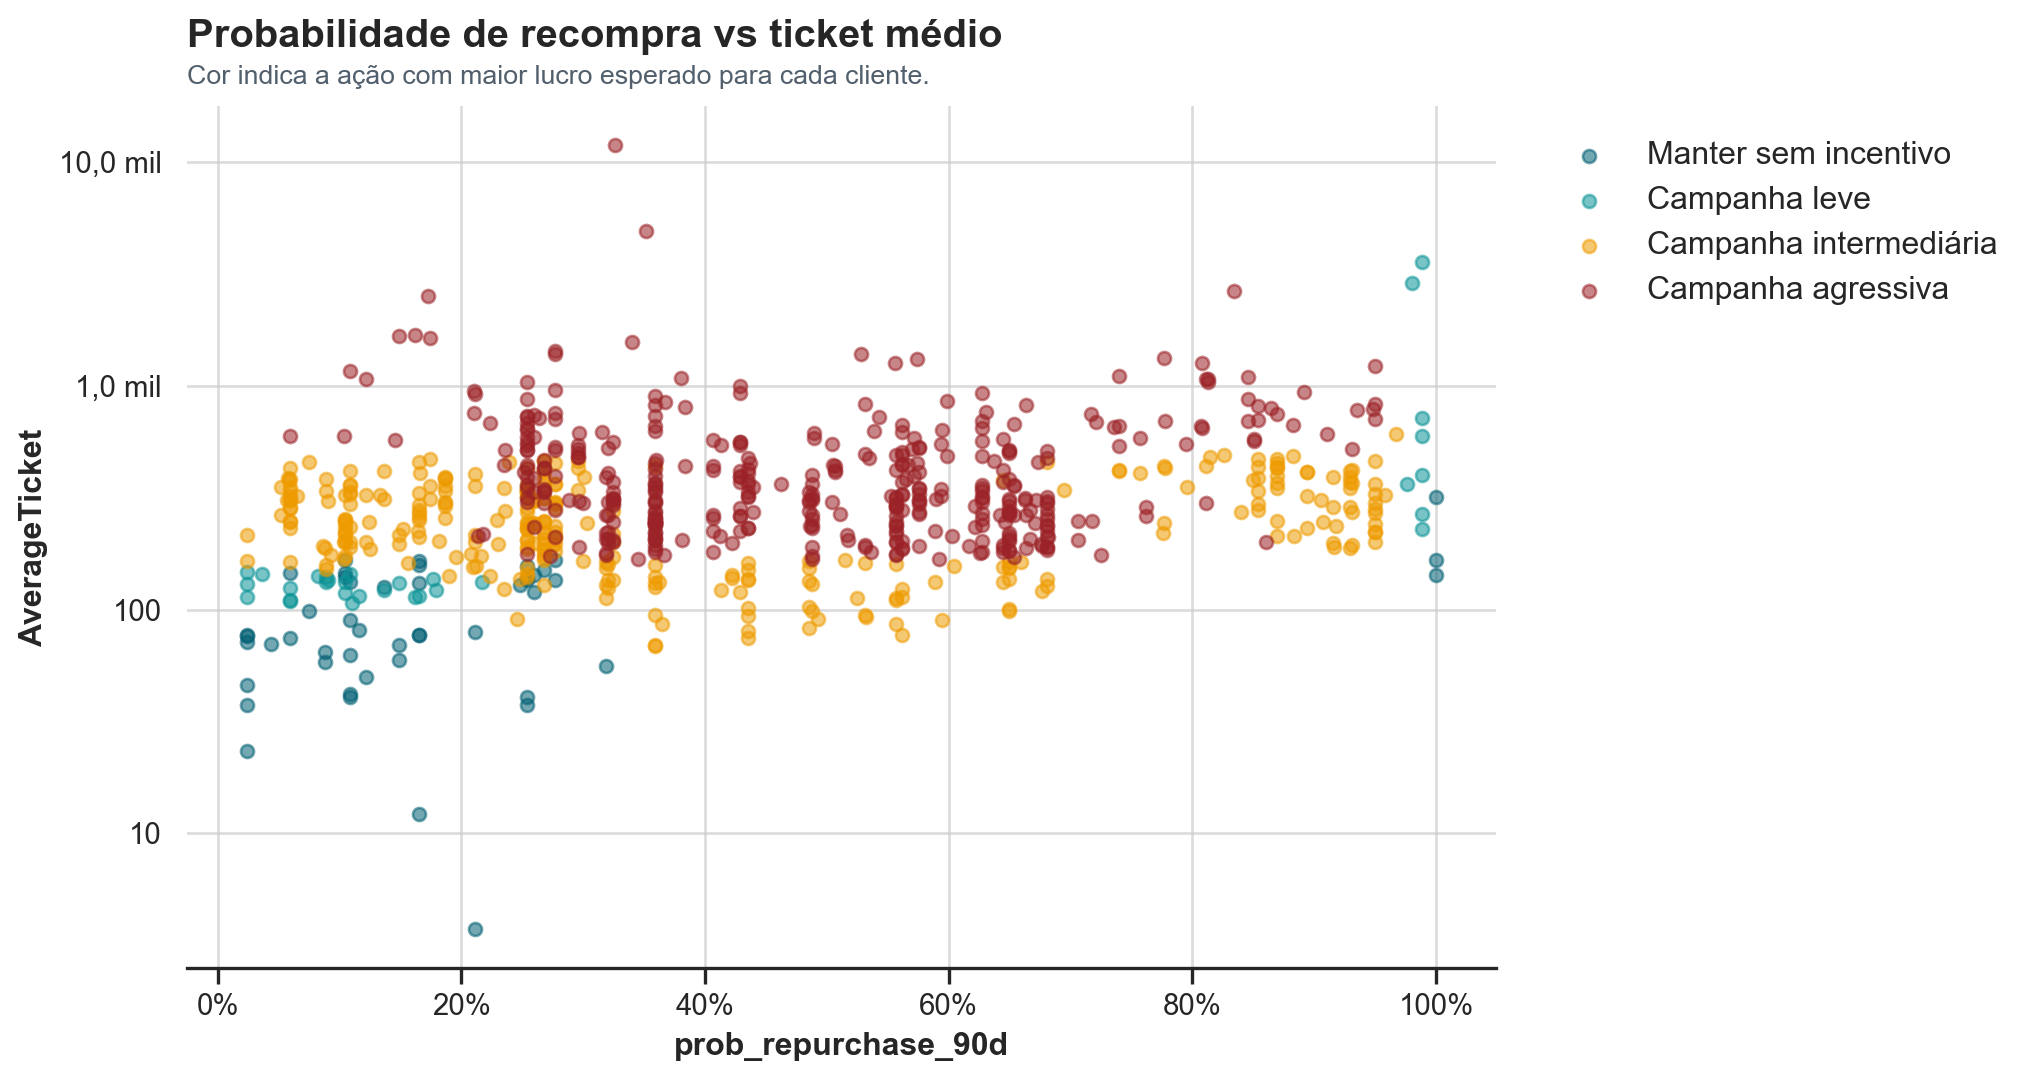

,BestAction,RecommendedAction,Clientes,LucroEsperadoTotal,LucroIncrementalTotal,TicketMedio,ProbabilidadeMediaRecompra
0,High Incentive,Campanha agressiva,403,114445.95,19151.67,490.41,0.50
2,Medium Incentive,Campanha intermediária,311,34735.07,1708.29,257.50,0.40
1,Low Incentive,Campanha leve,31,9302.76,128.41,384.79,0.33
3,No Action,Manter sem incentivo,48,1299.17,0.00,99.79,0.20


In [100]:
action_order = [
    "Manter sem incentivo",
    "Campanha leve",
    "Campanha intermediária",
    "Campanha agressiva",
]
action_palette = {
    "Manter sem incentivo": PALETTE[0],
    "Campanha leve": PALETTE[1],
    "Campanha intermediária": PALETTE[3],
    "Campanha agressiva": PALETTE[5],
}

hist(
    prescriptive_df["prob_repurchase_90d"],
    "Distribuição da probabilidade de recompra em 90 dias",
    "Probabilidades estimadas pela regressão logística com features pré-cutoff.",
    "Probabilidade de recompra",
    PALETTE[0],
    bins=30,
)

prob_by_cluster = prescriptive_df.groupby(
    ["PredictiveCluster", "PredictiveSegment"],
    as_index=False,
).agg(
    ProbabilidadeMedia=("prob_repurchase_90d", "mean"),
    Clientes=("Customer ID", "count"),
)
prob_by_cluster["ClusterSegment"] = (
    "C"
    + prob_by_cluster["PredictiveCluster"].astype(str)
    + " - "
    + prob_by_cluster["PredictiveSegment"]
)
barh(
    prob_by_cluster.sort_values("ProbabilidadeMedia"),
    "ClusterSegment",
    "ProbabilidadeMedia",
    "Probabilidade média de recompra por cluster temporal",
    "Clusters calculados apenas com dados anteriores ao cutoff.",
    PALETTE[1],
)

cluster_action_counts = pd.crosstab(
    prescriptive_df["ClusterSegment"],
    prescriptive_df["RecommendedAction"],
)
cluster_order = prob_by_cluster.sort_values("PredictiveCluster")[
    "ClusterSegment"
].tolist()
cluster_action_counts = cluster_action_counts.reindex(cluster_order).fillna(0)

fig, ax = plt.subplots(figsize=(10.8, 5.8))
left = np.zeros(len(cluster_action_counts))
for action in action_order:
    if action not in cluster_action_counts.columns:
        continue
    values = cluster_action_counts[action].to_numpy()
    ax.barh(
        cluster_action_counts.index,
        values,
        left=left,
        color=action_palette[action],
        alpha=0.88,
        label=action,
    )
    left += values
add_titles(
    ax,
    "Melhor ação recomendada por cluster temporal",
    "Distribuição de clientes por ação que maximiza lucro esperado.",
)
ax.set_xlabel("Clientes")
ax.grid(axis="x", alpha=0.8)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
set_compact_axis(ax, "x")
plt.tight_layout()
plt.show()

barh(
    action_summary.sort_values("LucroIncrementalTotal"),
    "RecommendedAction",
    "LucroIncrementalTotal",
    "Lucro incremental total por tipo de ação",
    "Diferença entre a melhor ação e No Action, conforme hipóteses de uplift.",
    PALETTE[3],
)

fig, ax = plt.subplots(figsize=(10.8, 5.8))
for action in action_order:
    group = prescriptive_df.loc[prescriptive_df["RecommendedAction"] == action]
    if group.empty:
        continue
    ax.scatter(
        group["prob_repurchase_90d"],
        group["AverageTicket"],
        s=24,
        alpha=0.55,
        color=action_palette[action],
        label=action,
    )
add_titles(
    ax,
    "Probabilidade de recompra vs ticket médio",
    "Cor indica a ação com maior lucro esperado para cada cliente.",
)
ax.set_xlabel("prob_repurchase_90d")
ax.set_ylabel("AverageTicket")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
set_compact_axis(ax, "y")
ax.grid(alpha=0.7)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(action_summary.round(4))


<span style="color:steelblue; text-align: left">

## Função de lucro com margem real
</span>

A versão anterior otimizava receita esperada. Esta seção substitui `AverageTicket`
por `AverageTicket × MARGIN_RATE`, aproximando o modelo de uma função objetivo
de lucro real. Em produção, `MARGIN_RATE` deve vir da contabilidade de produto —
pode variar por categoria, canal ou sazonalidade.

A tabela comparativa mostra quantos clientes teriam uma ação diferente com a
função corrigida. Esse delta é o custo de ignorar margem.


,Métrica,Valor
0,Clientes avaliados,793.00
1,Clientes com ação alterada,618.00
2,Percentual com ação alterada,77.93


,customer_id,best_action (receita),expected_profit,best_action (margem),best_margin_profit,ação mudou?
0,12347,High Incentive,518.68,Medium Incentive,177.64,True
354,15169,Medium Incentive,82.32,No Action,27.57,True
505,16250,High Incentive,108.39,Medium Incentive,33.67,True
507,16258,High Incentive,678.28,Medium Incentive,233.28,True
508,16266,Medium Incentive,90.64,No Action,30.35,True
509,16273,Medium Incentive,17.45,No Action,6.09,True
510,16278,High Incentive,267.53,Medium Incentive,88.22,True
512,16284,Medium Incentive,56.27,No Action,19.28,True
513,16289,Low Incentive,24.84,No Action,8.44,True
515,16296,Medium Incentive,40.63,No Action,12.52,True


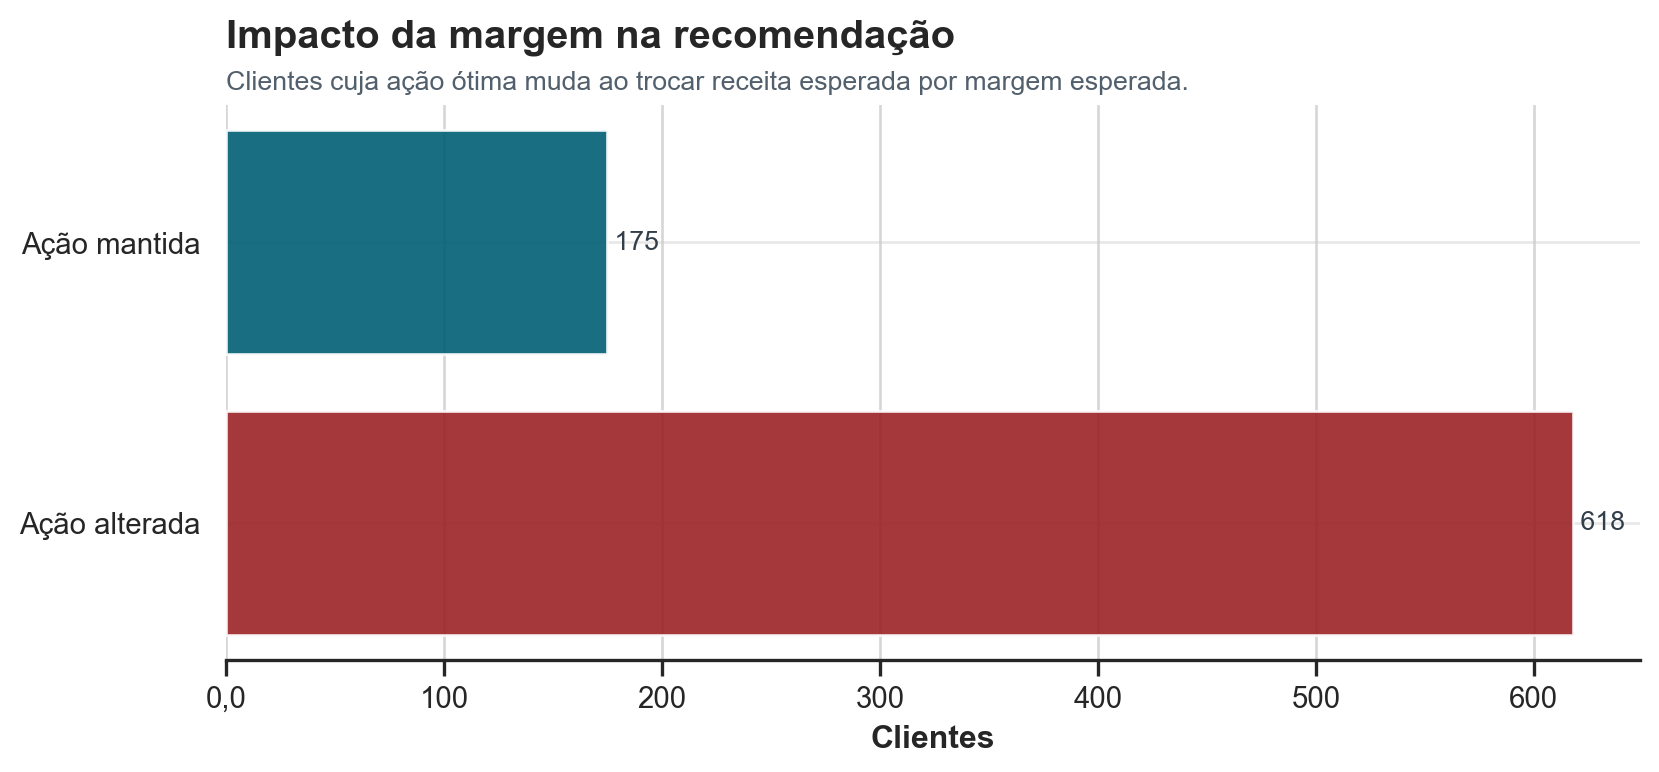

In [101]:
# INCREMENTO 1: substituir receita bruta por margem esperada na função objetivo.
# Isso muda o que estamos otimizando: de receita para lucro real.
decision_simulation["expected_margin"] = (
    decision_simulation["expected_probability"]
    * decision_simulation["AverageTicket"]
    * MARGIN_RATE
)
decision_simulation["expected_profit_margin"] = (
    decision_simulation["expected_margin"] - decision_simulation["incentive_cost"]
)

margin_no_action_profit = decision_simulation.loc[
    decision_simulation["Action"] == "No Action",
    ["Customer ID", "expected_profit_margin"],
].rename(columns={"expected_profit_margin": "ExpectedMarginProfit_NoAction"})

# Recalcular melhor ação com base em margem (não receita).
best_action_margin_idx = decision_simulation.groupby("Customer ID")[
    "expected_profit_margin"
].idxmax()
prescriptive_margin_df = decision_simulation.loc[best_action_margin_idx].copy()
prescriptive_margin_df = prescriptive_margin_df.merge(
    margin_no_action_profit,
    on="Customer ID",
    how="left",
)
prescriptive_margin_df = prescriptive_margin_df.rename(
    columns={
        "Action": "BestActionMargin",
        "RecommendedAction": "RecommendedActionMargin",
        "expected_profit_margin": "BestMarginProfit",
    }
)
prescriptive_margin_df["IncrementalMarginProfit"] = (
    prescriptive_margin_df["BestMarginProfit"]
    - prescriptive_margin_df["ExpectedMarginProfit_NoAction"]
)

margin_action_comparison = prescriptive_df[[
    "Customer ID",
    "BestAction",
    "ExpectedProfit",
]].merge(
    prescriptive_margin_df[[
        "Customer ID",
        "BestActionMargin",
        "BestMarginProfit",
    ]],
    on="Customer ID",
    how="left",
).rename(columns={
    "Customer ID": "customer_id",
    "BestAction": "best_action (receita)",
    "ExpectedProfit": "expected_profit",
    "BestActionMargin": "best_action (margem)",
    "BestMarginProfit": "best_margin_profit",
})
margin_action_comparison["ação mudou?"] = (
    margin_action_comparison["best_action (receita)"]
    != margin_action_comparison["best_action (margem)"]
)

margin_decision_summary = pd.DataFrame({
    "Métrica": [
        "Clientes avaliados",
        "Clientes com ação alterada",
        "Percentual com ação alterada",
    ],
    "Valor": [
        len(margin_action_comparison),
        int(margin_action_comparison["ação mudou?"].sum()),
        margin_action_comparison["ação mudou?"].mean() * 100,
    ],
})

display(margin_decision_summary.round(2))
display(
    margin_action_comparison.sort_values(
        "ação mudou?",
        ascending=False,
    ).head(12).round(2)
)

margin_change_counts = (
    margin_action_comparison["ação mudou?"]
    .map({False: "Ação mantida", True: "Ação alterada"})
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Clientes")
)
fig, ax = plt.subplots(figsize=(8.8, 4.2))
colors = margin_change_counts["Status"].map({
    "Ação mantida": PALETTE[0],
    "Ação alterada": PALETTE[5],
})
ax.barh(
    margin_change_counts["Status"],
    margin_change_counts["Clientes"],
    color=colors,
    alpha=0.9,
)
add_titles(
    ax,
    "Impacto da margem na recomendação",
    "Clientes cuja ação ótima muda ao trocar receita esperada por margem esperada.",
)
ax.set_xlabel("Clientes")
ax.grid(axis="x", alpha=0.8)
set_compact_axis(ax, "x")
for idx, value in enumerate(margin_change_counts["Clientes"]):
    ax.text(value, idx, f" {compact(value)}", va="center", fontsize=10, color="#323F4B")
plt.tight_layout()
plt.show()


<span style="color:steelblue; text-align: left">

## Análise de cenários: baseline vs modelo vs prescrição
</span>

Três cenários são comparados sobre o mesmo hold-out:

- **Cenário A** — nenhum incentivo: lucro esperado sem qualquer intervenção.
- **Cenário B** — campanha uniforme: mesmo incentivo médio para todos os clientes,
  sem personalização.
- **Cenário C** — prescrição individual: ação ótima por cliente com base no modelo.

A diferença entre C e A é o valor do modelo. A diferença entre C e B é o valor
da personalização. Esses dois números são os argumentos centrais para qualquer
apresentação executiva ou justificativa de investimento em analytics.


,Cenário,LucroTotal,CustoTotal,GanhoVsBaseline,ROI
0,A — Sem ação,48578.10,0.00,0.00,NaN
1,B — Campanha uniforme,51579.74,3965.00,3001.64,0.76
2,C — Prescrição por cliente,53385.39,2603.00,4807.28,1.85


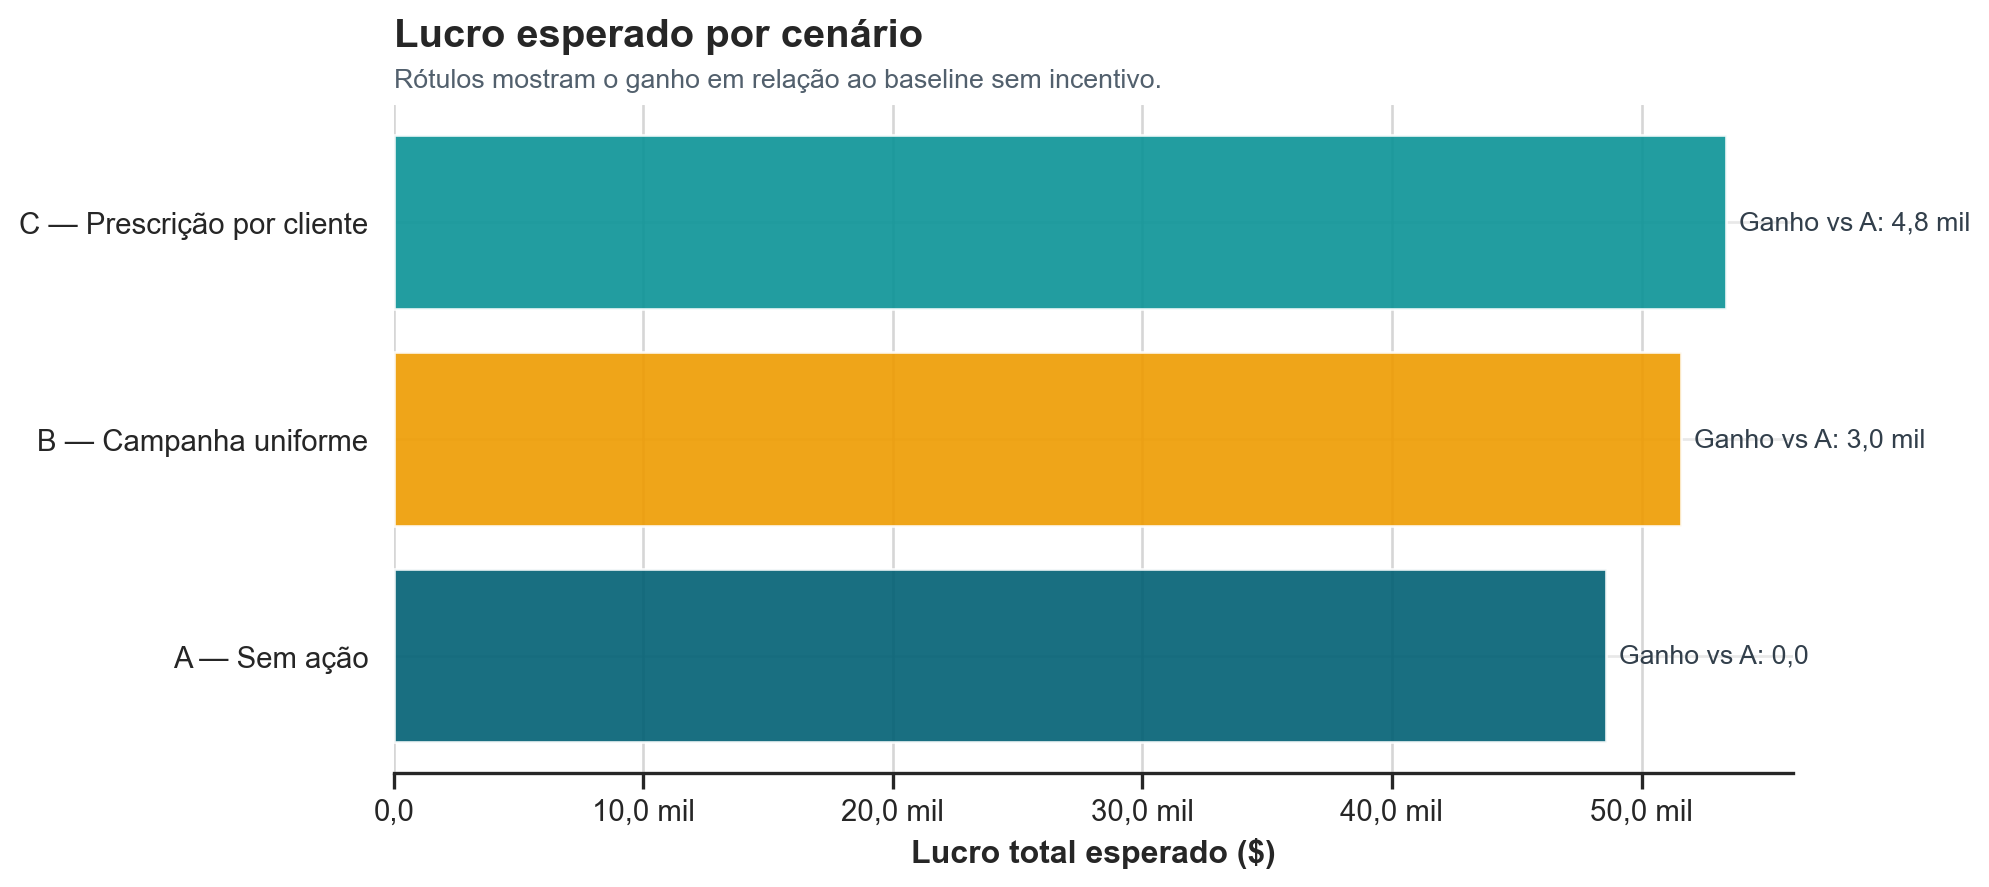

In [102]:
# INCREMENTO 2: comparativo de cenários para justificar ROI do modelo.

# ── Cenário A: sem modelo — nenhum incentivo para ninguém ────────────────────
scenario_a = prescriptive_df.copy()
scenario_a["scenario"] = "A — Sem ação"
scenario_a["scenario_profit"] = (
    scenario_a["prob_repurchase_90d"] * scenario_a["AverageTicket"] * MARGIN_RATE
)
scenario_a["scenario_cost"] = 0.0

# ── Cenário B: sem modelo — campanha uniforme para todos (Medium Incentive) ──
scenario_b = prescriptive_df.copy()
scenario_b["scenario"] = "B — Campanha uniforme (medium)"
scenario_b["scenario_prob"] = (
    scenario_b["prob_repurchase_90d"] + UNIFORM_UPLIFT
).clip(upper=1)
scenario_b["scenario_profit"] = (
    scenario_b["scenario_prob"] * scenario_b["AverageTicket"] * MARGIN_RATE
    - UNIFORM_COST
)
scenario_b["scenario_cost"] = UNIFORM_COST

# ── Cenário C: com prescrição — ação ótima por cliente ───────────────────────
scenario_c = prescriptive_margin_df.copy()
scenario_c["scenario"] = "C — Prescrição por cliente"
scenario_c["scenario_profit"] = scenario_c["BestMarginProfit"]
scenario_c["scenario_cost"] = scenario_c["incentive_cost"]

# ── Consolidação ──────────────────────────────────────────────────────────────
scenario_summary = pd.DataFrame({
    "Cenário": [
        "A — Sem ação",
        "B — Campanha uniforme",
        "C — Prescrição por cliente",
    ],
    "LucroTotal": [
        scenario_a["scenario_profit"].sum(),
        scenario_b["scenario_profit"].sum(),
        scenario_c["scenario_profit"].sum(),
    ],
    "CustoTotal": [
        scenario_a["scenario_cost"].sum(),
        scenario_b["scenario_cost"].sum(),
        scenario_c["scenario_cost"].sum(),
    ],
})
scenario_summary["GanhoVsBaseline"] = (
    scenario_summary["LucroTotal"] - scenario_summary.loc[0, "LucroTotal"]
)
scenario_summary["ROI"] = np.where(
    scenario_summary["CustoTotal"] > 0,
    scenario_summary["GanhoVsBaseline"] / scenario_summary["CustoTotal"],
    np.nan,
)

display(scenario_summary.round(2))

scenario_plot = scenario_summary.sort_values("LucroTotal").reset_index(drop=True)
scenario_colors = scenario_plot["Cenário"].map({
    "A — Sem ação": PALETTE[0],
    "B — Campanha uniforme": PALETTE[3],
    "C — Prescrição por cliente": PALETTE[1],
})

fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.barh(
    scenario_plot["Cenário"],
    scenario_plot["LucroTotal"],
    color=scenario_colors,
    alpha=0.9,
)
add_titles(
    ax,
    "Lucro esperado por cenário",
    "Rótulos mostram o ganho em relação ao baseline sem incentivo.",
)
ax.set_xlabel("Lucro total esperado ($)")
ax.grid(axis="x", alpha=0.8)
set_compact_axis(ax, "x")
offset = max(scenario_plot["LucroTotal"].abs().max() * 0.01, 1)
for idx, row in scenario_plot.iterrows():
    value = row["LucroTotal"]
    gain = row["GanhoVsBaseline"]
    x_pos = value + offset if value >= 0 else value - offset
    ha = "left" if value >= 0 else "right"
    ax.text(
        x_pos,
        idx,
        f"Ganho vs A: {compact(gain)}",
        va="center",
        ha=ha,
        fontsize=10,
        color="#323F4B",
    )
plt.tight_layout()
plt.show()


<span style="color:steelblue; text-align: left">

## Sensibilidade ao erro do modelo
</span>

Modelos preditivos não são perfeitos. Esta seção simula o que acontece com o
lucro esperado total quando as probabilidades reais diferem das estimadas em
até ±15 pontos percentuais.

Um modelo robusto deve ser lucrativo mesmo sob perturbações realistas. Se o
lucro esperado entrar em território negativo com um deslocamento de apenas -5pp,
a política de incentivos é frágil demais para produção.

Esta análise é a ponte entre modelagem e gestão de risco — e o que separa um
notebook de portfólio de uma análise que um CFO levaria a sério.


,Deslocamento (pp),LucroEsperadoTotal,CustoTotal,ROI
0,-15,31033.48,2603.00,11.92
1,-10,35821.24,2603.00,13.76
2,-5,40833.41,2603.00,15.69
3,0,45975.10,2603.00,17.66
4,5,51001.20,2603.00,19.59
5,10,55796.55,2603.00,21.44
6,15,60440.13,2603.00,23.22


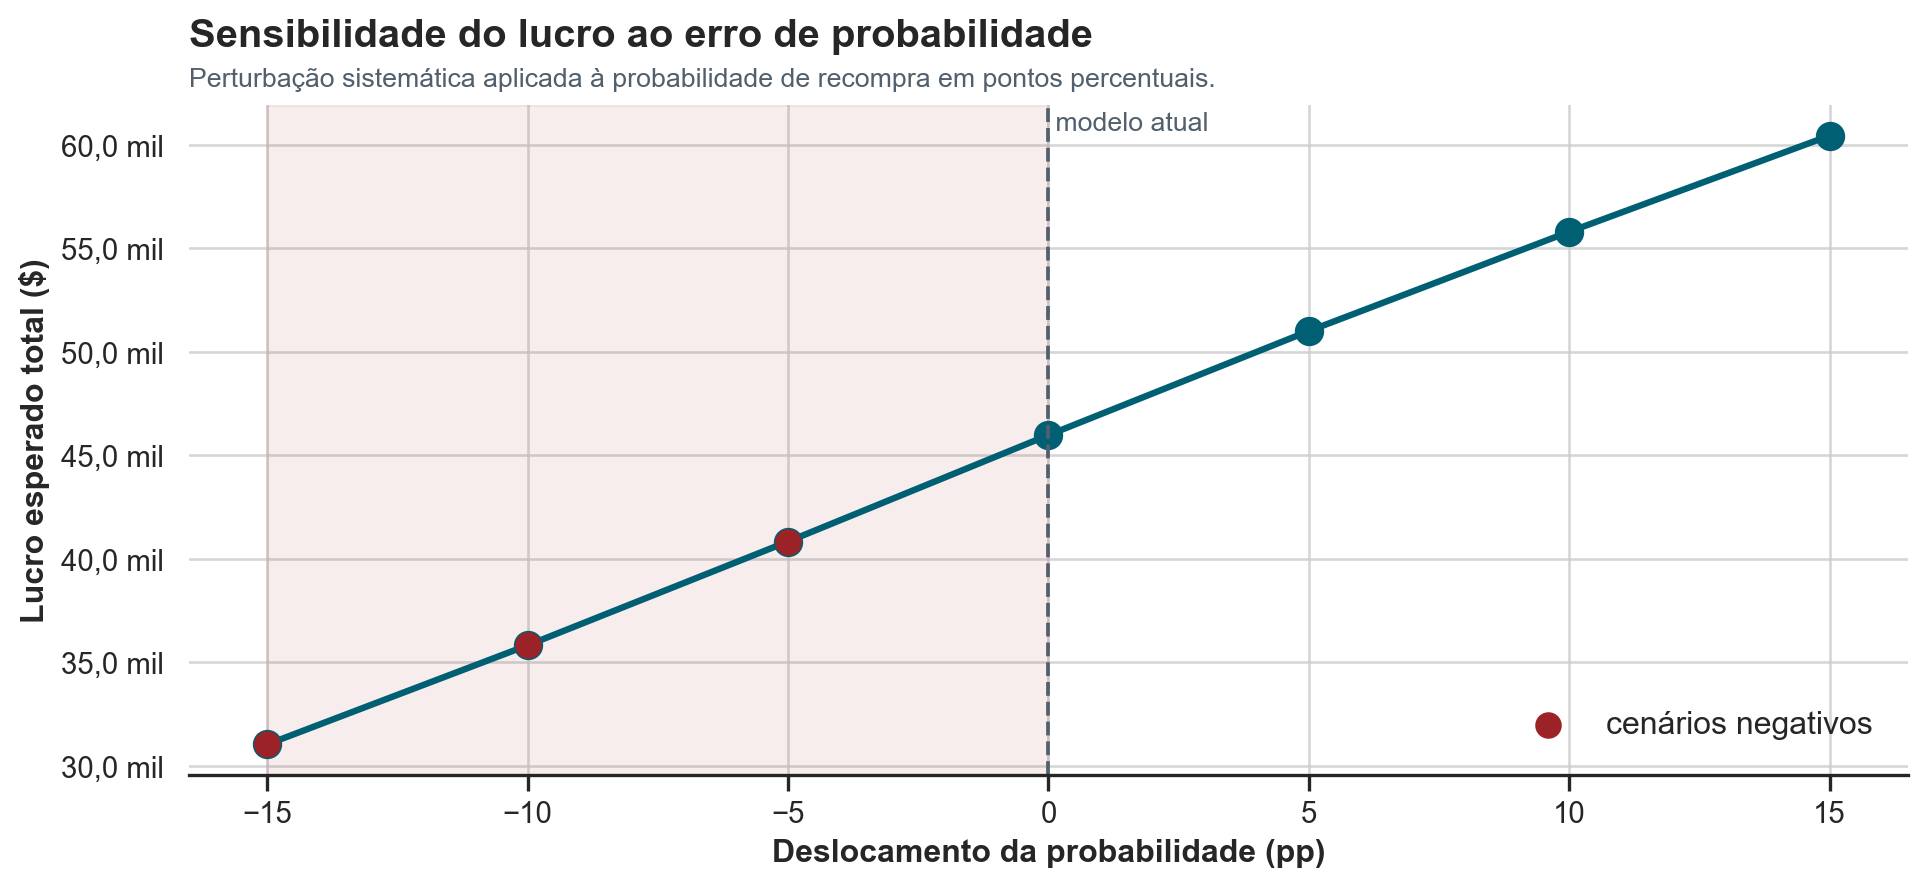

In [103]:
# INCREMENTO 3: análise de sensibilidade ao erro de calibração do modelo.
# Simula o impacto de probabilidades sistematicamente deslocadas no resultado financeiro.

noise_levels = NOISE_LEVELS
# Interpretação: -0.10 significa que as probs reais são 10pp menores que as estimadas.

sensitivity_rows = []
for noise in noise_levels:
    sim = prescriptive_margin_df.copy()
    sim["prob_perturbed"] = (sim["prob_repurchase_90d"] + noise).clip(0, 1)
    sim["expected_revenue_perturbed"] = (
        sim["prob_perturbed"] * sim["AverageTicket"] * MARGIN_RATE
    )
    sim["expected_profit_perturbed"] = (
        sim["expected_revenue_perturbed"] - sim["incentive_cost"]
    )
    total_profit = sim["expected_profit_perturbed"].sum()
    total_cost = sim["incentive_cost"].sum()
    sensitivity_rows.append({
        "Deslocamento (pp)": int(noise * 100),
        "LucroEsperadoTotal": total_profit,
        "CustoTotal": total_cost,
        "ROI": total_profit / total_cost if total_cost > 0 else np.nan,
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)

display(sensitivity_df.round(2))

fig, ax = plt.subplots(figsize=(10.2, 4.8))
ax.plot(
    sensitivity_df["Deslocamento (pp)"],
    sensitivity_df["LucroEsperadoTotal"],
    marker="o",
    linewidth=2.4,
    color=PALETTE[0],
)
negative_sensitivity = sensitivity_df.loc[sensitivity_df["Deslocamento (pp)"] < 0]
ax.scatter(
    negative_sensitivity["Deslocamento (pp)"],
    negative_sensitivity["LucroEsperadoTotal"],
    s=80,
    color=PALETTE[5],
    zorder=3,
    label="cenários negativos",
)
ax.axvspan(
    sensitivity_df["Deslocamento (pp)"].min(),
    0,
    color=PALETTE[5],
    alpha=0.08,
)
ax.axvline(0, color="#52606D", linestyle="--", linewidth=1.4)
ax.text(
    0,
    sensitivity_df["LucroEsperadoTotal"].max(),
    " modelo atual",
    ha="left",
    va="bottom",
    fontsize=10,
    color="#52606D",
)
add_titles(
    ax,
    "Sensibilidade do lucro ao erro de probabilidade",
    "Perturbação sistemática aplicada à probabilidade de recompra em pontos percentuais.",
)
ax.set_xlabel("Deslocamento da probabilidade (pp)")
ax.set_ylabel("Lucro esperado total ($)")
ax.grid(alpha=0.8)
set_compact_axis(ax, "y")
ax.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()


<span style="color:steelblue; text-align: left">

## Decisão "não agir": maturidade de negócio
</span>

Modelos ingênuos enviam campanhas para todos. Modelos maduros sabem quando
**não agir** é a melhor decisão.

Esta seção quantifica explicitamente os clientes para quem nenhum incentivo
gera retorno positivo, e quanto budget é preservado por essa decisão. A
concentração de "não agir" em segmentos de baixo valor e alta inatividade
é a validação mais intuitiva de que o modelo está funcionando corretamente.

Em uma apresentação executiva, mostrar "economizamos $ X evitando incentivos
desnecessários" é tão poderoso quanto "geramos $ Y com campanhas certeiras".


,Grupo,Clientes,PercentualBase,EconomiaBudget,BudgetInvestido,LucroIncrementalTotal
0,Sem incentivo,48,6.05,240.00,0.00,0.00
1,Com incentivo,745,93.95,0.00,5647.00,20988.37


,PredictiveSegment,Clientes,BudgetEconomizado
0,Baixo Valor,27,135.00
2,Clientes Inativos,18,90.00
1,Campeões,3,15.00


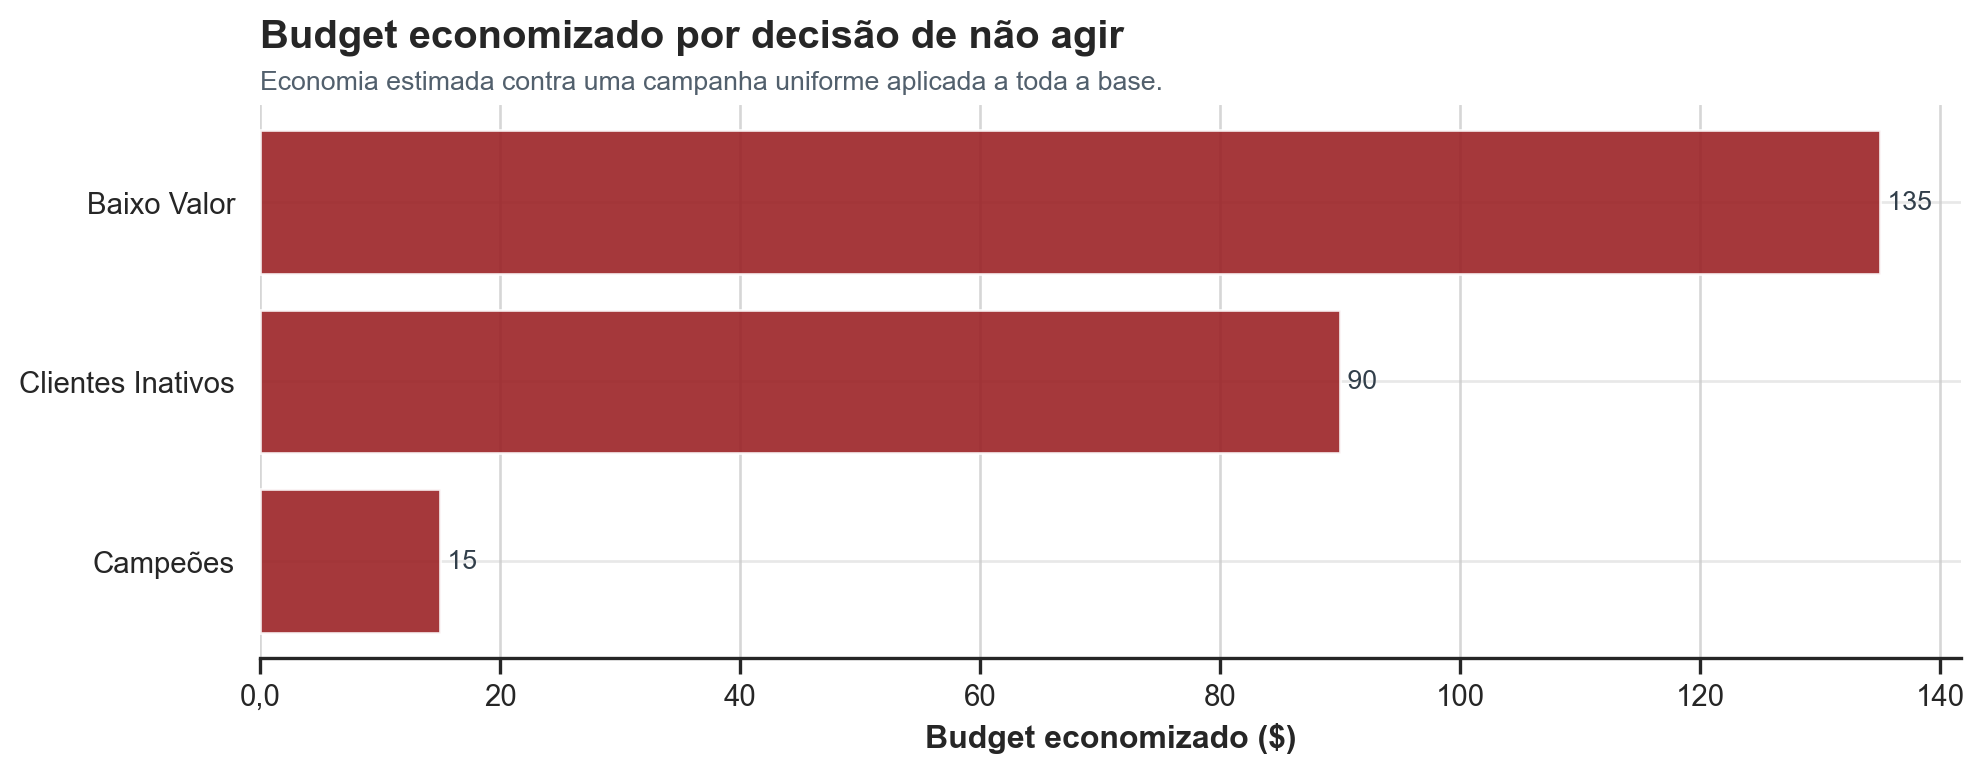

In [104]:
# INCREMENTO 4: "não agir" como decisão explícita e quantificada.
# Mostrar quantos clientes não merecem incentivo e quanto isso economiza.

no_action_clients = prescriptive_df.loc[
    (prescriptive_df["BestAction"] == "No Action")
    | (prescriptive_df["IncrementalProfit"] <= 0)
].copy()

action_clients = prescriptive_df.loc[
    (prescriptive_df["BestAction"] != "No Action")
    & (prescriptive_df["IncrementalProfit"] > 0)
].copy()

# Economia medida contra uma política ingênua de campanha uniforme para toda a base.
no_action_clients["budget_avoided"] = UNIFORM_COST
action_clients["budget_avoided"] = 0.0

no_action_summary = pd.DataFrame({
    "Grupo": ["Sem incentivo", "Com incentivo"],
    "Clientes": [len(no_action_clients), len(action_clients)],
    "PercentualBase": [
        len(no_action_clients) / len(prescriptive_df) * 100,
        len(action_clients) / len(prescriptive_df) * 100,
    ],
    "EconomiaBudget": [
        no_action_clients["budget_avoided"].sum(),
        action_clients["budget_avoided"].sum(),
    ],
    "BudgetInvestido": [
        no_action_clients["incentive_cost"].sum(),
        action_clients["incentive_cost"].sum(),
    ],
    "LucroIncrementalTotal": [
        no_action_clients["IncrementalProfit"].sum(),
        action_clients["IncrementalProfit"].sum(),
    ],
})

# Distribuição dos clientes "não agir" por segmento — onde estão?
no_action_by_segment = (
    no_action_clients.groupby("PredictiveSegment", as_index=False)
    .agg(
        Clientes=("Customer ID", "count"),
        BudgetEconomizado=("budget_avoided", "sum"),
    )
    .sort_values("Clientes", ascending=False)
)

display(no_action_summary.round(2))
display(no_action_by_segment.round(2))

no_action_segment_plot = no_action_by_segment.sort_values("BudgetEconomizado")
fig_height = max(4.2, 0.42 * len(no_action_segment_plot) + 1.4)
fig, ax = plt.subplots(figsize=(10.5, fig_height))
ax.barh(
    no_action_segment_plot["PredictiveSegment"],
    no_action_segment_plot["BudgetEconomizado"],
    color=PALETTE[5],
    alpha=0.9,
)
add_titles(
    ax,
    "Budget economizado por decisão de não agir",
    "Economia estimada contra uma campanha uniforme aplicada a toda a base.",
)
ax.set_xlabel("Budget economizado ($)")
ax.grid(axis="x", alpha=0.8)
set_compact_axis(ax, "x")
for idx, value in enumerate(no_action_segment_plot["BudgetEconomizado"]):
    ax.text(value, idx, f" {compact(value)}", va="center", fontsize=10, color="#323F4B")
plt.tight_layout()
plt.show()


<span style="color:steelblue; text-align: left">

## Curva de budget vs lucro incremental
</span>

Esta curva responde a pergunta que todo CFO faz: *"Qual é o retorno marginal
de cada real adicional investido em campanhas?"*

O gráfico da esquerda mostra o lucro incremental total acumulado conforme o
budget cresce. O gráfico da direita mostra o ROI — que começa alto (clientes
de maior retorno são priorizados) e cai conforme clientes de menor retorno
são incluídos.

O ponto ótimo de investimento é onde o ROI começa a cair abruptamente. Investir
além desse ponto ainda gera lucro, mas a eficiência cai. A linha tracejada
marca o `BUDGET_TOTAL` atual — à esquerda ou à direita do ponto ótimo?

Esta visualização transforma o notebook em ferramenta de planejamento estratégico:
o gestor não precisa mais adivinhar o budget certo — ele pode lê-lo no gráfico.


,PercentilBudget,Budget,LucroIncremental,ClientesAtendidos,ROI
0,25%,637.47,3127.29,65.00,4.91
1,50%,1274.94,4079.46,147.00,3.20
2,75%,1965.53,4641.84,284.00,2.36
3,100%,2603.00,4807.28,473.00,1.85


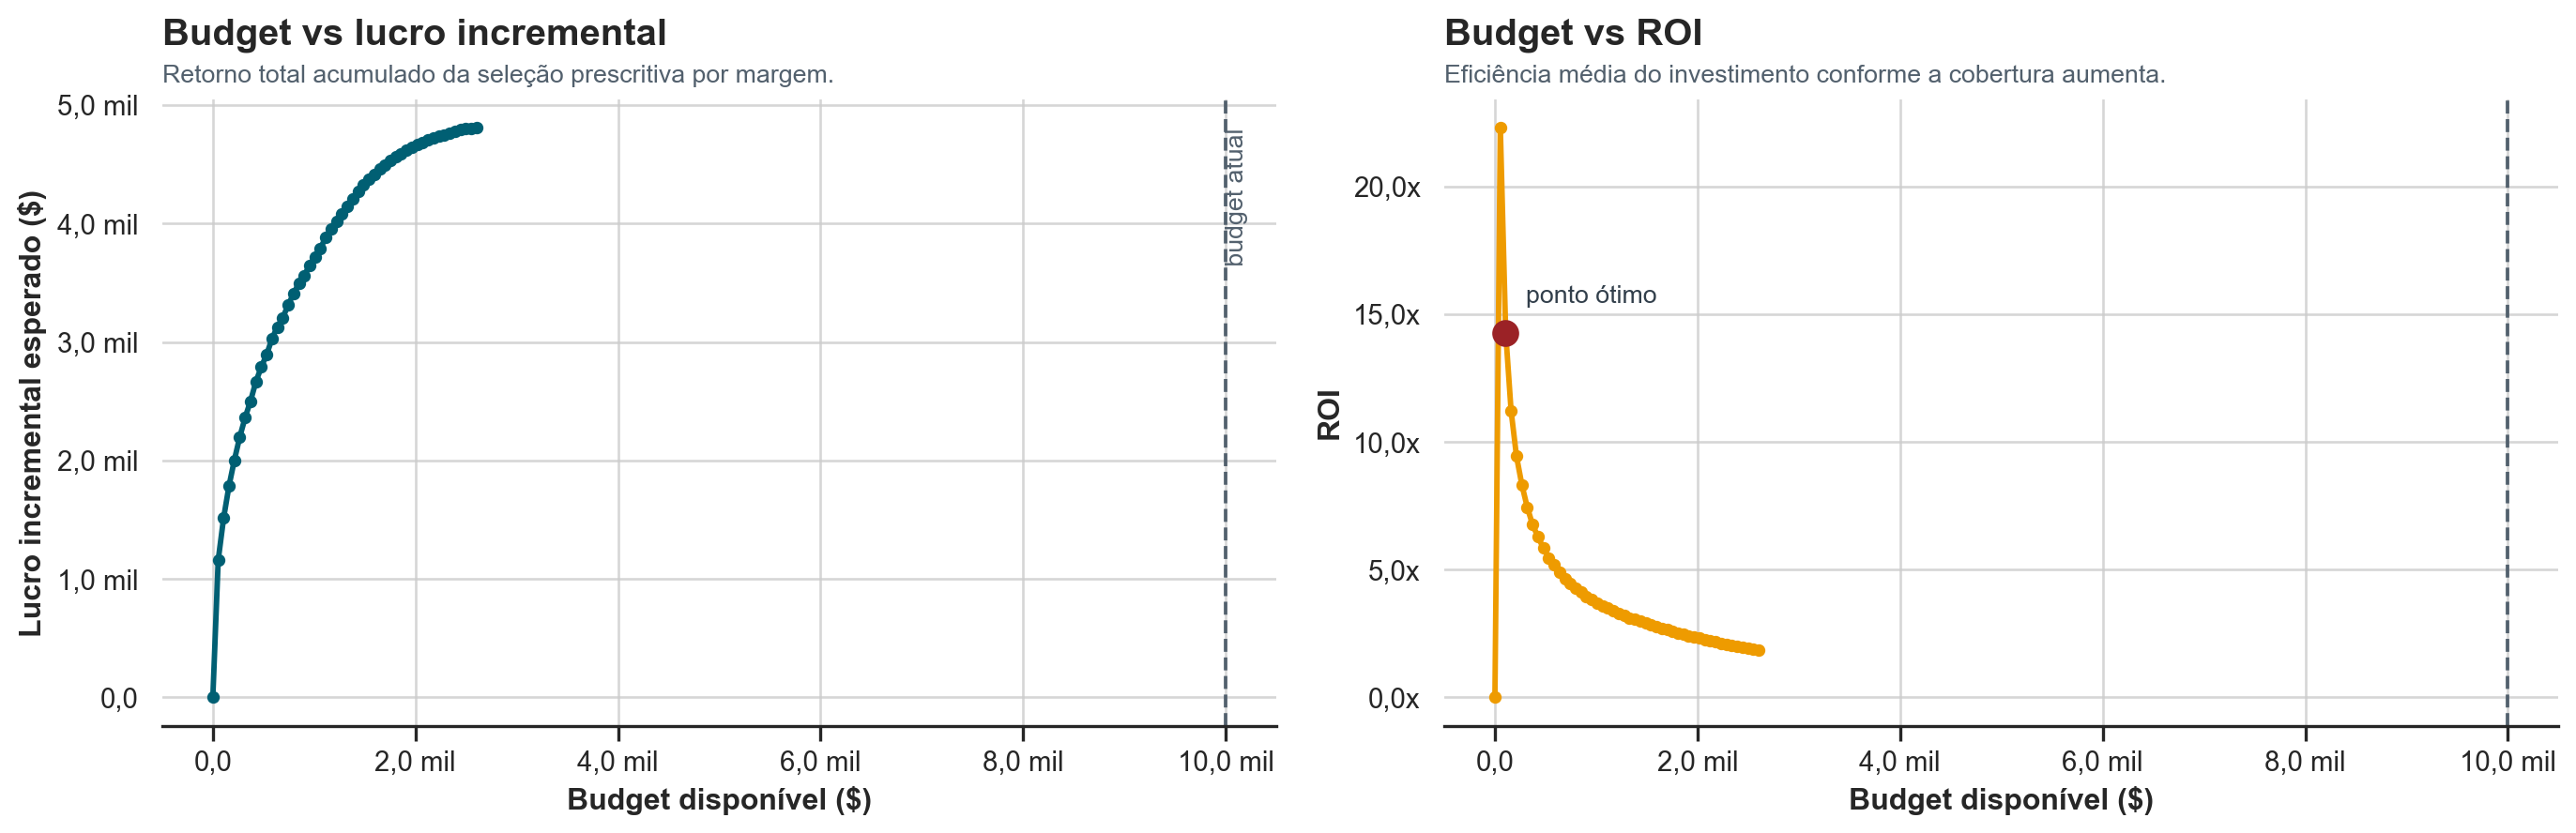

In [105]:
# INCREMENTO 5: curva budget vs lucro incremental — apresentação executiva.
# Mostra o retorno marginal de cada nível de investimento.

budget_candidates_curve = prescriptive_margin_df.loc[
    (prescriptive_margin_df["BestActionMargin"] != "No Action")
    & (prescriptive_margin_df["IncrementalMarginProfit"] > 0)
    & (prescriptive_margin_df["incentive_cost"] > 0)
].sort_values("IncrementalMarginProfit", ascending=False).copy()

# Varredura: de 0 até budget máximo possível, em pontos parametrizados.
max_possible_budget = budget_candidates_curve["incentive_cost"].sum()
budget_points = np.linspace(0, max_possible_budget, BUDGET_CURVE_POINTS)

curve_rows = []
for b in budget_points:
    remaining = b
    selected_profit = 0.0
    selected_clients = 0
    selected_cost = 0.0
    for _, row in budget_candidates_curve.iterrows():
        if row["incentive_cost"] <= remaining:
            remaining -= row["incentive_cost"]
            selected_profit += row["IncrementalMarginProfit"]
            selected_cost += row["incentive_cost"]
            selected_clients += 1
    curve_rows.append({
        "Budget": b,
        "LucroIncremental": selected_profit,
        "ClientesAtendidos": selected_clients,
        "CustoReal": selected_cost,
        "ROI": selected_profit / selected_cost if selected_cost > 0 else 0,
    })

budget_curve_df = pd.DataFrame(curve_rows)

positive_curve = budget_curve_df.loc[budget_curve_df["CustoReal"] > 0].copy()
if positive_curve.empty:
    optimal_budget_point = budget_curve_df.iloc[[0]].copy()
else:
    positive_curve["ROI_Delta"] = positive_curve["ROI"].diff()
    if positive_curve["ROI_Delta"].notna().any():
        optimal_idx = positive_curve["ROI_Delta"].idxmin()
    else:
        optimal_idx = positive_curve["ROI"].idxmax()
    optimal_budget_point = budget_curve_df.loc[[optimal_idx]].copy()

breakpoint_rows = []
for percentile in [0.25, 0.50, 0.75, 1.00]:
    target_budget = max_possible_budget * percentile
    idx = (budget_curve_df["Budget"] - target_budget).abs().idxmin()
    row = budget_curve_df.loc[idx]
    breakpoint_rows.append({
        "PercentilBudget": f"{int(percentile * 100)}%",
        "Budget": row["Budget"],
        "LucroIncremental": row["LucroIncremental"],
        "ClientesAtendidos": row["ClientesAtendidos"],
        "ROI": row["ROI"],
    })

budget_breakpoints = pd.DataFrame(breakpoint_rows)

display(budget_breakpoints.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))

axes[0].plot(
    budget_curve_df["Budget"],
    budget_curve_df["LucroIncremental"],
    marker="o",
    markersize=4,
    linewidth=2.2,
    color=PALETTE[0],
)
axes[0].axvline(BUDGET_TOTAL, color="#52606D", linestyle="--", linewidth=1.4)
axes[0].text(
    BUDGET_TOTAL,
    budget_curve_df["LucroIncremental"].max(),
    " budget atual",
    rotation=90,
    va="top",
    ha="left",
    fontsize=10,
    color="#52606D",
)
add_titles(
    axes[0],
    "Budget vs lucro incremental",
    "Retorno total acumulado da seleção prescritiva por margem.",
)
axes[0].set_xlabel("Budget disponível ($)")
axes[0].set_ylabel("Lucro incremental esperado ($)")
axes[0].grid(alpha=0.8)
set_compact_axis(axes[0], "x")
set_compact_axis(axes[0], "y")

axes[1].plot(
    budget_curve_df["Budget"],
    budget_curve_df["ROI"],
    marker="o",
    markersize=4,
    linewidth=2.2,
    color=PALETTE[3],
)
axes[1].axvline(BUDGET_TOTAL, color="#52606D", linestyle="--", linewidth=1.4)
if not optimal_budget_point.empty:
    opt = optimal_budget_point.iloc[0]
    axes[1].scatter(
        opt["Budget"],
        opt["ROI"],
        s=95,
        color=PALETTE[5],
        zorder=3,
    )
    axes[1].annotate(
        "ponto ótimo",
        xy=(opt["Budget"], opt["ROI"]),
        xytext=(8, 12),
        textcoords="offset points",
        fontsize=10,
        color="#323F4B",
    )
add_titles(
    axes[1],
    "Budget vs ROI",
    "Eficiência média do investimento conforme a cobertura aumenta.",
)
axes[1].set_xlabel("Budget disponível ($)")
axes[1].set_ylabel("ROI")
axes[1].grid(alpha=0.8)
set_compact_axis(axes[1], "x")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{fmt(value, 1)}x")
)

plt.tight_layout()
plt.show()


<span style="color:steelblue; text-align: left">

## Melhorias implementadas
</span>


- **Problema 1:** `PredictiveCluster` passou a ser gerado dentro do `Pipeline`, com `KMeans.fit()` apenas no treino e `predict()` para validação e hold-out.
- **Problema 2:** foi criado um hold-out independente de 15%, e a simulação financeira usa probabilidades geradas em dados não vistos pelo modelo.
- **Problema 3:** o uplift deixou de ser uniforme e passou a variar por segmento e tipo de incentivo.
- **Problema 4:** as probabilidades foram calibradas com `CalibratedClassifierCV` e avaliadas com reliability diagram e Brier Score.
- **Problema 5:** foi adicionada uma alocação de budget com restrição orçamentária e ROI estimado por segmento.
- **Problema 6:** a nomeação automática dos segmentos agora possui validações de sanidade com `warnings.warn`.
- **Problema 7:** funções principais receberam type hints e docstrings, `AverageTicket` foi protegido contra divisão por zero e `best_k` ficou explicitamente documentado.
- **P1:** Índice resetado antes dos splits; `check_is_fitted` no transformer; assertion de alinhamento.
- **P2:** Escopo do hold-out documentado na simulação de budget com contexto de produção.
- **P3:** Export CSV operacional com `priority_rank` para uso direto em CRM.
- **P4:** Parâmetros operacionais centralizados em célula de configuração única.
- **I1:** função de lucro recalculada com `MARGIN_RATE`, comparando ações otimizadas por receita versus margem.
- **I2:** análise executiva de cenários compara sem ação, campanha uniforme e prescrição individual.
- **I3:** sensibilidade financeira simula deslocamentos de probabilidade de -15pp a +15pp.
- **I4:** decisão `No Action` foi quantificada como economia de budget frente a uma campanha uniforme.
- **I5:** curva de budget mostra lucro incremental, ROI e breakpoints executivos de investimento.


<span style="color:steelblue; text-align: left">

## Export operacional para CRM
</span>

O arquivo `crm_next_best_action.csv` consolida, para cada cliente do hold-out,
o segmento, a ação recomendada, o lucro esperado e a descrição executiva da
Next Best Action. A coluna `priority_rank` ordena clientes globalmente por
lucro incremental — rank 1 é o cliente que mais retorno gera se receber um incentivo.

O arquivo está pronto para importação direta em ferramentas de CRM, automação
de e-mail marketing ou priorização de fila de atendimento.


In [38]:
## Export operacional para CRM

# CORREÇÃO P3: transforma o notebook em ferramenta de CRM diretamente acionável.
crm_export_cols = {
    "Customer ID": "customer_id",
    "SegmentName": "segment_name",
    "Recency": "recency_days",
    "Frequency": "frequency",
    "Monetary": "monetary_total",
    "AverageTicket": "average_ticket",
    "prob_repurchase_90d": "prob_repurchase_90d",
    "BestAction": "best_action_code",
    "RecommendedAction": "recommended_campaign",
    "ExpectedProfit": "expected_profit",
    "ExpectedProfit_NoAction": "expected_profit_no_action",
    "IncrementalProfit": "incremental_profit",
    "PrescriptiveNextBestAction": "crm_action_description",
}

crm_prescription_cols = [
    "Customer ID",
    "BestAction",
    "RecommendedAction",
    "ExpectedProfit",
    "ExpectedProfit_NoAction",
    "IncrementalProfit",
    "PrescriptiveNextBestAction",
]

# Base: todos os clientes com prescrição disponível (hold-out).
crm_base = rfm.drop(
    columns=[col for col in crm_prescription_cols if col != "Customer ID"],
    errors="ignore",
).merge(
    prescriptive_df[crm_prescription_cols],
    on="Customer ID",
    how="inner",
)

crm_output = (
    crm_base[list(crm_export_cols.keys())]
    .rename(columns=crm_export_cols)
    .sort_values(
        ["segment_name", "incremental_profit"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

# Adiciona coluna de prioridade de atendimento: rank global por incremental_profit.
crm_output["priority_rank"] = crm_output["incremental_profit"].rank(
    ascending=False,
    method="first",
).astype(int)

output_path = EXPORT_PATH
crm_output.to_csv(output_path, index=False, sep=";", decimal=",", encoding="utf-8-sig")

print(f"Export gerado: {output_path}")
print(f"Clientes exportados: {fmt(len(crm_output))}")
print(f"Segmentos cobertos: {crm_output['segment_name'].nunique()}")
display(crm_output.head(10))
display(
    crm_output.groupby("segment_name", as_index=False).agg(
        Clientes=("customer_id", "count"),
        IncrementalProfitTotal=("incremental_profit", "sum"),
        PrioridadeMinima=("priority_rank", "min"),
        PrioridadeMaxima=("priority_rank", "max"),
    ).sort_values("IncrementalProfitTotal", ascending=False)
)


Export gerado: crm_next_best_action.csv
Clientes exportados: 793
Segmentos cobertos: 6


,customer_id,segment_name,recency_days,frequency,monetary_total,average_ticket,prob_repurchase_90d,best_action_code,recommended_campaign,expected_profit,expected_profit_no_action,incremental_profit,crm_action_description,priority_rank
0,13687,Alto Valor em Risco,438,1,11880.84,11880.84,0.33,High Incentive,Campanha agressiva,5644.12,3872.00,1772.13,Prioridade máxima de retenção com campanha agressiva.,1
1,12590,Alto Valor em Risco,211,2,9864.26,4932.13,0.35,High Incentive,Campanha agressiva,2462.10,1732.29,729.82,Prioridade máxima de retenção com campanha agressiva.,2
2,14063,Alto Valor em Risco,438,9,22710.20,2523.36,0.17,High Incentive,Campanha agressiva,804.66,436.16,368.50,Prioridade máxima de retenção com campanha agressiva.,3
3,12911,Alto Valor em Risco,552,1,1680.47,1680.47,0.16,High Incentive,Campanha agressiva,514.63,272.56,242.07,Prioridade máxima de retenção com campanha agressiva.,4
4,13734,Alto Valor em Risco,509,4,6701.64,1675.41,0.15,High Incentive,Campanha agressiva,490.73,249.42,241.31,Prioridade máxima de retenção com campanha agressiva.,5
5,15310,Alto Valor em Risco,479,1,1634.64,1634.64,0.17,High Incentive,Campanha agressiva,519.63,284.44,235.20,Prioridade máxima de retenção com campanha agressiva.,6
6,12798,Alto Valor em Risco,10,4,8510.93,2127.73,0.34,High Incentive,Campanha agressiva,759.51,533.94,225.57,Prioridade máxima de retenção com campanha agressiva.,7
7,12967,Alto Valor em Risco,358,3,4306.92,1435.64,0.28,High Incentive,Campanha agressiva,602.72,397.38,205.35,Prioridade máxima de retenção com campanha agressiva.,8
8,12653,Alto Valor em Risco,149,3,4160.83,1386.94,0.53,High Incentive,Campanha agressiva,930.76,732.72,198.04,Prioridade máxima de retenção com campanha agressiva.,9
9,14899,Alto Valor em Risco,395,1,1384.88,1384.88,0.28,High Incentive,Campanha agressiva,581.06,383.33,197.73,Prioridade máxima de retenção com campanha agressiva.,10


,segment_name,Clientes,IncrementalProfitTotal,PrioridadeMinima,PrioridadeMaxima
0,Alto Valor em Risco,84,10283.94,1,643
3,Clientes Fiéis,214,4383.02,12,774
2,Campeões,124,2238.11,24,773
5,Compradores Ocasionais,123,2116.97,27,793
4,Clientes Inativos,178,1839.77,32,788
1,Baixo Valor,70,126.56,352,770


<span style="color:steelblue; text-align: left">

## Conclusão
</span>

Este projeto evoluiu de uma análise tradicional de segmentação de clientes para uma estrutura mais avançada de análise prescritiva, capaz de apoiar decisões de marketing orientadas por dados.

Inicialmente, a análise concentrou-se na compreensão do comportamento de compra dos clientes por meio de métricas RFM e clusterização com K-Means, permitindo identificar diferentes perfis de clientes com características comportamentais e valores comerciais distintos. Embora a segmentação, por si só, já forneça insights estratégicos relevantes, o projeto foi expandido além da análise descritiva ao incorporar uma camada supervisionada de previsão baseada na probabilidade futura de recompra.

Utilizando uma abordagem de validação temporal, o modelo estimou a probabilidade de recompra dentro de um horizonte futuro, reduzindo riscos de vazamento de dados (*data leakage*) e criando um cenário mais próximo da realidade de negócio. Essa camada preditiva transformou o projeto de um exercício estático de segmentação em um pipeline analítico orientado ao futuro, capaz de estimar o comportamento futuro dos clientes.

Posteriormente, o projeto foi elevado para uma perspectiva de análise prescritiva inspirada no framework proposto por Bertsimas e Kallus em *From Predictive to Prescriptive Analytics*. Em vez de apenas prever resultados, o notebook passou a simular possíveis ações de marketing e estimar seus impactos econômicos esperados por meio de cálculos de lucro esperado.

Ao combinar:

* variáveis comportamentais dos clientes,
* probabilidade de recompra,
* incentivos simulados de marketing,
* receita esperada,
* custos de campanha,
* e restrições orçamentárias,

o pipeline tornou-se capaz de recomendar a ação economicamente mais vantajosa para cada cliente ou segmento.

Uma das principais contribuições do projeto é a transição de:

* “O que provavelmente irá acontecer?”
  para:
* “Qual decisão deve ser tomada?”

Essa distinção representa a principal diferença entre análise preditiva e análise prescritiva.

Além disso, o notebook incorpora uma camada prática orientada ao negócio por meio de:

* priorização baseada em ROI,
* alocação de orçamento sob restrição,
* e exportação de arquivos preparados para integração com CRM e campanhas operacionais.

Dessa forma, o projeto não termina na clusterização de clientes. Pelo contrário, demonstra como técnicas de Machine Learning podem apoiar processos reais de tomada de decisão ao integrar previsão, simulação, otimização e recomendação de ações em um fluxo analítico unificado.

Embora os valores de *uplift* utilizados nas simulações sejam hipóteses heurísticas e não estimativas causais reais, a estrutura construída estabelece uma base sólida para futuras evoluções envolvendo:

* testes A/B,
* *uplift modeling*,
* inferência causal,
* *reinforcement learning*,
* e otimização sob incerteza.

De forma geral, o projeto demonstra como análises de clientes podem evoluir de relatórios descritivos para inteligência de decisão acionável, capaz de apoiar iniciativas estratégicas e operacionais de marketing orientadas por valor econômico esperado.


<span style="color:steelblue; text-align: left">

## Referências
</span>

- **[Bertsimas e Kallus, 2019]** Bertsimas, D., e Kallus, N. (2019). *From Predictive to Prescriptive Analytics*. Management Science. https://doi.org/10.1287/mnsc.2018.3253
- **[Chen, 2012]** Chen, D. (2012). *Online Retail II* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5CG6D
- **[Chen, Sain e Guo, 2012]** Chen, D., Sain, S. L., e Guo, K. (2012). *Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining*. Journal of Database Marketing & Customer Strategy Management, 19, 197-208. https://doi.org/10.1057/dbm.2012.17
- **[Fader, Hardie e Lee, 2005]** Fader, P. S., Hardie, B. G. S., e Lee, K. L. (2005). *RFM and CLV: Using Iso-Value Curves for Customer Base Analysis*. Journal of Marketing Research, 42(4), 415-430. https://doi.org/10.1509/jmkr.2005.42.4.415
- **[Hastie, Tibshirani e Friedman, 2009]** Hastie, T., Tibshirani, R., e Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7
- **[Imbens e Rubin, 2015]** Imbens, G. W., e Rubin, D. B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences: An Introduction*. Cambridge University Press. https://doi.org/10.1017/CBO9781139025751
- **[Jain, 2010]** Jain, A. K. (2010). *Data clustering: 50 years beyond K-means*. Pattern Recognition Letters, 31(8), 651-666. https://doi.org/10.1016/j.patrec.2009.09.011
- **[Kuhn e Johnson, 2013]** Kuhn, M., e Johnson, K. (2013). *Applied Predictive Modeling*. Springer. https://doi.org/10.1007/978-1-4614-6849-3
- **[Lloyd, 1982]** Lloyd, S. (1982). *Least squares quantization in PCM*. IEEE Transactions on Information Theory, 28(2), 129-137. https://doi.org/10.1109/TIT.1982.1056489
- **[MacQueen, 1967]** MacQueen, J. (1967). *Some methods for classification and analysis of multivariate observations*. Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability, 1, 281-297. https://projecteuclid.org/euclid.bsmsp/1200512992
- **[Rousseeuw, 1987]** Rousseeuw, P. J. (1987). *Silhouettes: A graphical aid to the interpretation and validation of cluster analysis*. Journal of Computational and Applied Mathematics, 20, 53-65. https://doi.org/10.1016/0377-0427(87)90125-7
- **[Rust e Verhoef, 2005]** Rust, R. T., e Verhoef, P. C. (2005). *Optimizing the Marketing Interventions Mix in Intermediate-Term CRM*. Marketing Science, 24(3), 477-489. https://doi.org/10.1287/mksc.1040.0107
- **[Tukey, 1977]** Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley. https://openlibrary.org/works/OL9572429W/Exploratory_data_analysis
- **[Wedel e Kamakura, 2000]** Wedel, M., e Kamakura, W. A. (2000). *Market Segmentation: Conceptual and Methodological Foundations* (2nd ed.). Springer. https://doi.org/10.1007/978-1-4615-4651-1
